# Etap A: eksploracja próby oznaczonej przez LLM

**Cel.** Druga część karty eksploracji danych (M1). Notatnik `01_eda_wypowiedzi` opisał korpus słownikami (regex): ile wypowiedzi
**wspomina** temat naukowy. Tu, na próbie oznaczonej przez LLM, sprawdzamy, ile wypowiedzi zawiera konkretne **twierdzenia
naukowe**, czyli materiał, który da się później porównać z konsensusem. Opisujemy tematy, czas, mówców i źródła błędu
instrumentu oraz to, co z tego wynika dla dalszego pomiaru.

**Porównania w czasie.** Główne porównanie to okna A (17.04.2022–16.07.2023) i B (13.11.2023–17.02.2025) z suplementu karty
eksploracji. Dodatkowo, krócej: przed i po premierze ChatGPT (30.11.2022, wątek wskazany przez prowadzącego) oraz trzy okresy
pierwotnej hipotezy H1 (przed COVID / COVID / po ChatGPT).

**Status wyników.** Mierzymy tylko obecność twierdzeń naukowych (etap A). Tego, czy twierdzenia są zgodne z konsensusem
(etap B), w tym notatniku nie badamy. Nie ma też ręcznie oznaczonych danych odniesienia, więc błąd klasyfikatora jest nieznany,
a wszystkie liczby są **eksploracyjne**.

> Spis treści: 0. Co zostało zrobione · 1. Przegląd próby · 2. Lejek detekcji · 3. Agregacja po wypowiedzi · 4. Tematy ·
> 5. Czas (5.4–5.7 okna A i B, 5.8 ChatGPT, 5.9 COVID, 5.10 kampanie) · 6. Kto mówi · 7. Słowniki a LLM · 8. Atrybucja ·
> 9. Źródła błędu · 10. Dalszy plan · 11. Podsumowanie

## 0. Co zostało zrobione

### 0.1 Pipeline (tylko wykonane kroki)

```
API Sejmu: posiedzenia plenarne (kadencje VIII–X) + komisje ZDR, OSZ, ESK, RRW     src/fetch_sejm.py, src/fetch_komisje.py
   │
   ▼
korpus wypowiedzi: czyszczenie tekstu, rola mówcy, blok, flaga `merytoryczna`      src/build_corpus.py
   │  (bez prowadzącego obrady, ≥ 40 słów)
   ▼
filtr regex: ≥ 1 trafienie słownika tematu, `nauka` lub `sceptycyzm`              src/amc/topics.py, sampling.prefilter
   │
   ▼
próba warstwowa: 60 wypowiedzi / rok 2015–2026, waga = N_rok / n_rok               src/classify.py --source rok --n 60
   │
   ▼
LLM, krok 1 (prompts/etap_a_v2.md): do 16 zdań-kandydatów na wypowiedź; dla każdego
   cytat · twierdzenie (parafraza samodzielna) · rodzaj (naukowe / statystyka / prawo / budżet / polityka / opinia / inne)
   · temat (8 słowników + inny_naukowy + brak) · atrybucja (własne / cytat z aprobatą / cytat w polemice)
   │
   ▼
LLM, krok 2 (prompts/weryfikacja_v1.md): każdy kandydat „naukowe” oceniany osobno, razem z fragmentem wypowiedzi
   (zdanie z cytatem i po jednym zdaniu przed i po) → tak / nie
   │
   ▼
twierdzenia = kandydaci potwierdzeni w kroku 2 (odrzuceni zostają w danych do analizy błędów)
   │
   ▼
ten notatnik: duplikaty cytatów usunięte, metadane z korpusu, estymacja ważona       src/amc/llm_results.py
```

**Model:** Bielik 11B v3.0 Instruct (kwantyzacja Q4_K_M), lokalnie przez Ollamę na RTX 3060 12 GB; temperatura 0, kontekst
16 384 tokeny, do 16 kandydatów na wypowiedź, wyjście wymuszone schematem JSON, wypowiedzi > 2500 słów ucinane.

**Historia przebiegu.** Pierwszy przebieg (kontekst 8192 tokeny, do 8 kandydatów, krok 2 bez kontekstu) ujawnił przepełnienie
kontekstu i pełny limit kandydatów w długich wypowiedziach (sekcja 9). Po naprawie powtórzyliśmy krok 1 i 2 dla 119 wypowiedzi
dotkniętych tymi problemami, a dla pozostałych powtórzyliśmy tylko krok 2, już z kontekstem. Sekcje 1–8 opisują wyniki po naprawie,
sekcja 9 porównuje je z pierwszym przebiegiem.

**Czego jeszcze nie ma:** etapu B (werdykt względem źródeł), ręcznej anotacji, która pozwoliłaby zmierzyć błąd instrumentu
(rozważamy ją), i porównania z innymi modelami. To opisuje sekcja 10.

### 0.2 Czym ten notatnik różni się od `01_eda_wypowiedzi`

| | `01_eda_wypowiedzi` | ten notatnik |
|---|---|---|
| metoda | słowniki regex | LLM; słowniki tylko jako filtr wstępny |
| co mierzy | czy wypowiedź **wspomina** temat (wzmianka ≥ 1, wypowiedź tematyczna ≥ 3 trafienia) | czy wypowiedź **zawiera twierdzenie naukowe**, ile i jakie |
| jednostka | wypowiedź | twierdzenie, agregowane do wypowiedzi |
| kontekst | brak (fałszywe trafienia: ASF, aukcja 5G, broń atomowa) | model czyta całą wypowiedź; widzi też tematy spoza słowników (`inny_naukowy`) |
| zakres | cały korpus: plenarne + komisje ZDR i OSZ | próba 720 wypowiedzi z filtra: plenarne + komisje ZDR, OSZ, ESK, RRW |
| estymacja | liczności w korpusie | estymator ważony z próby, 95% przedziały z bootstrapu |
| słowniki | wyniki sprzed poprawki `\w` w RE2 (do przeliczenia) | po poprawce |

In [1]:
import re, sys, warnings
from pathlib import Path
from statistics import NormalDist

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=UserWarning)
_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(_root / "src"))

from amc import corpus, llm, sampling, topics as T, viz, llm_results as R
from amc.text import quote_match
from amc.sampling import PERIOD_BREAKS, PERIODS
from amc.speakers import BLOKI
from amc.viz import INK, INK2, MUTED, GRID, AXIS, SURF, ACCENT, ACCENT_LIGHT, SECOND, BLOK_KOLOR, ROLE_KOLOR, SEQ, save, subtitle

viz.setup()
pd.set_option("display.max_colwidth", 200)
PERIODS = list(PERIODS)
PERIOD_LABEL = {"przed_covid": "przed COVID", "covid": "COVID", "po_chatgpt": "po ChatGPT"}
PERIOD_TICK = {"przed_covid": "przed COVID\n(do 23.01.2020)", "covid": "COVID\n(24.01.2020–29.11.2022)",
               "po_chatgpt": "po ChatGPT\n(od 30.11.2022)"}
TOPICS = list(T.TOPICS)
TOPICS_LLM = TOPICS + ["inny_naukowy"]
GREMIA = {"plenarne": "plenarne", "ZDR": "ZDR (zdrowie)", "OSZ": "OSZ (środowisko)", "ESK": "ESK (energia)", "RRW": "RRW (rolnictwo)"}
PCT = plt.FuncFormatter(lambda v, _: f"{v * 100:g}%")


def fmt_ci(b, scale=100):
    return [f"{p * scale:.1f} [{lo * scale:.1f}; {hi * scale:.1f}]" for p, lo, hi in zip(b["p"], b["lo"], b["hi"])]


WINDOWS = {"A": (pd.Timestamp("2022-04-17"), pd.Timestamp("2023-07-16")),
           "B": (pd.Timestamp("2023-11-13"), pd.Timestamp("2025-02-17"))}
WINDOW_TICK = {"A": "okno A\n(17.04.2022–16.07.2023)", "B": "okno B\n(13.11.2023–17.02.2025)"}
WIN_KOLOR = {"A": "#86b6ef", "B": ACCENT}
CHATGPT = PERIOD_BREAKS[1]
CHATGPT_LABEL = {"przed": "przed ChatGPT", "po": "po ChatGPT"}


def window(dates):
    out = pd.Series(np.nan, index=dates.index, dtype=object)
    for k, (a, b) in WINDOWS.items():
        out[dates.between(a, b)] = k
    return out


def year_x(d):
    return d.year + (d.dayofyear - 1) / 365 - 0.5


def period_lines(ax, label=True):
    for d, lab in zip(PERIOD_BREAKS, ["COVID w Europie", "ChatGPT"]):
        x = year_x(d)
        ax.axvline(x, color=AXIS, ls=":", lw=1)
        if label:
            ax.text(x, 1.0, " " + lab, transform=ax.get_xaxis_transform(), fontsize=8, color=MUTED, va="top")
    for k, (a, b) in WINDOWS.items():
        ax.axvspan(year_x(a), year_x(b), color=GRID, alpha=0.7, lw=0, zorder=0)
        if label:
            ax.text((year_x(a) + year_x(b)) / 2, 0.88, k, transform=ax.get_xaxis_transform(), ha="center", va="top",
                    fontsize=9, fontweight="bold", color=MUTED)


def hbar_ci(ax, b, colors, labels=None, pct=True):
    k = 1 if pct else 100
    p, lo, hi = b["p"] * k, b["lo"] * k, b["hi"] * k
    y = np.arange(len(b))
    ax.barh(y, p, color=colors, height=0.62)
    ax.errorbar(p, y, xerr=[p - lo, hi - p], fmt="none", ecolor=INK2, elinewidth=1, capsize=0)
    for yi, (v, h, n) in enumerate(zip(p, hi, b["n"])):
        ax.text(h, yi, f"  {v:.0%}" if pct else f"  {v:.0f}", va="center", fontsize=8, color=INK2)
    ax.set_yticks(y, labels if labels is not None else [""] * len(b))
    ax.invert_yaxis(); ax.grid(axis="y", visible=False)
    ax.set_xlim(0, hi.max() * 1.25)
    if pct:
        ax.xaxis.set_major_formatter(PCT)

### 0.3 Dane i zakres próby

* **Populacja:** wypowiedzi merytoryczne (posiedzenia plenarne i komisje ZDR, OSZ, ESK, RRW) z co najmniej jednym trafieniem
  słownika tematu, markera `nauka` lub `sceptycyzm`. Wypowiedzi bez trafień są poza pomiarem (ograniczenie, sekcja 9).
* **Losowanie:** warstwy = rok kalendarzowy 2015–2026, po 60 wypowiedzi na rok (2015: 60 z 75, bo dane zaczynają się 12.11.2015).
  Waga wypowiedzi = N_rok / n_rok, czyli liczba wypowiedzi populacji, które reprezentuje. Próba nie była losowana pod okna A i B,
  więc w oknach jest jej niewiele (sekcja 5.4).
* **Porównania w czasie** (granice ustalone przed analizą, nie na podstawie wyników):
  * **okno A** 17.04.2022–16.07.2023 (IX kadencja) i **okno B** 13.11.2023–17.02.2025 (X kadencja), według suplementu karty
    eksploracji; okres 17.07–12.11.2023 (kampania przed wyborami do Sejmu, wybory i czas do pierwszego posiedzenia) jest poza oknami;
  * **ChatGPT:** przed 30.11.2022 i od tego dnia;
  * **okresy H1:** przed COVID (do 23.01.2020), COVID (24.01.2020–29.11.2022), po ChatGPT (od 30.11.2022).
* Rok 2026 obejmuje dane do dnia pobrania korpusu.
* **Liczby dla populacji.** Liczności wypowiedzi i trafień słowników liczymy na całym korpusie, więc są dokładne. Liczbę
  wypowiedzi z twierdzeniem i liczbę twierdzeń w populacji szacujemy jako dokładne N populacji w danym okresie razy ważony
  udział z próby.

In [2]:
df = R.load("etap_a_v2", "rok", 60)
first = R.load("etap_a_v2", "rok", 60, keep="first")
retest = R.load("etap_a_v2", "rok", 60, suffix="_powtorka")
rerun_ids = set(df.loc[df["num_ctx"] == llm.NUM_CTX, "wypowiedz_id"])

pop = pd.concat([corpus.load(k).assign(zrodlo=k) for k in corpus.RODZAJE], ignore_index=True)
pop["mowca"] = pop["mowca"].fillna(pop["etykieta"])
pop["okres"] = sampling.period(pop["data"])
for d in (pop, df, first):
    d["okno"] = window(d["data"])
    d["chatgpt"] = np.where(d["data"] < CHATGPT, "przed", "po")
mer = pop[pop["merytoryczna"]]
filt = mer[sampling.prefilter(mer)]

when = ["wypowiedz_id", "okno", "chatgpt"]
cand = R.candidates(df).merge(df[when], on="wypowiedz_id", how="left")
cl = R.claims(df).merge(df[when], on="wypowiedz_id", how="left")
flags = R.topic_flags(df, cl, TOPICS_LLM)
df["n_tematow"] = flags.sum(axis=1)
for t in TOPICS_LLM:
    df[f"tw_{t}"] = flags[t]

funnel = pd.DataFrame({
    "wszystkie wypowiedzi": pop.groupby("zrodlo").size(),
    "merytoryczne": mer.groupby("zrodlo").size(),
    "filtr regex (populacja)": filt.groupby("zrodlo").size(),
    "próba LLM": df.groupby("zrodlo").size(),
}).T
funnel["razem"] = funnel.sum(axis=1)
funnel["% poprzedniego kroku"] = (funnel["razem"] / funnel["razem"].shift() * 100).round(1)
print(f"próba: {len(df)} wypowiedzi, {df['mowca'].nunique()} mówców, {df['data'].min():%Y-%m-%d} – {df['data'].max():%Y-%m-%d}")
funnel

próba: 720 wypowiedzi, 496 mówców, 2015-11-12 – 2026-09-17


zrodlo,komisje,plenarne,razem,% poprzedniego kroku
wszystkie wypowiedzi,242164,132118,374282,NaN
merytoryczne,57897,129768,187665,50.1
filtr regex (populacja),7074,12343,19417,10.3
próba LLM,275,445,720,3.7


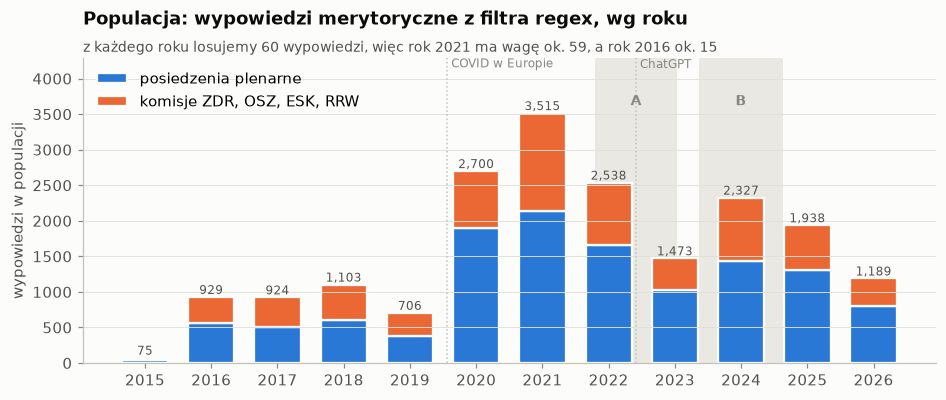

,N (populacja),n (próba),waga,% komisji: populacja,% komisji: próba
rok,,,,,
2015,75,60,1.2,42.7,43.3
2016,929,60,15.5,39.5,41.7
2017,924,60,15.4,45.7,51.7
2018,1103,60,18.4,45.1,43.3
2019,706,60,11.8,45.6,43.3
2020,2700,60,45.0,29.9,25.0
2021,3515,60,58.6,39.3,41.7
2022,2538,60,42.3,34.9,41.7
2023,1473,60,24.6,30.2,33.3


In [3]:
design = pd.DataFrame({"N (populacja)": filt.groupby("rok").size(), "n (próba)": df.groupby("rok").size()})
design["waga"] = design["N (populacja)"] / design["n (próba)"]
assert np.allclose(design["waga"], df.groupby("rok")["waga"].first())
design["% komisji: populacja"] = filt["zrodlo"].eq("komisje").groupby(filt["rok"]).mean() * 100
design["% komisji: próba"] = df["zrodlo"].eq("komisje").groupby(df["rok"]).mean() * 100

fig, ax = plt.subplots(figsize=(10, 3.6))
years = design.index
pl = filt[filt["zrodlo"] == "plenarne"].groupby("rok").size().reindex(years, fill_value=0)
ko = filt[filt["zrodlo"] == "komisje"].groupby("rok").size().reindex(years, fill_value=0)
ax.bar(years, pl, color=ACCENT, width=0.7, edgecolor=SURF, linewidth=1.5, label="posiedzenia plenarne")
ax.bar(years, ko, bottom=pl, color=SECOND, width=0.7, edgecolor=SURF, linewidth=1.5, label="komisje ZDR, OSZ, ESK, RRW")
for x, tot in zip(years, pl + ko):
    ax.text(x, tot, f"{tot:,}", ha="center", va="bottom", fontsize=8, color=INK2)
period_lines(ax)
ax.set_xticks(years); ax.grid(axis="x", visible=False)
ax.set_ylabel("wypowiedzi w populacji"); ax.set_ylim(0, (pl + ko).max() * 1.22)
ax.legend(loc="upper left")
ax.set_title("Populacja: wypowiedzi merytoryczne z filtra regex, wg roku")
subtitle(ax, "z każdego roku losujemy 60 wypowiedzi, więc rok 2021 ma wagę ok. 59, a rok 2016 ok. 15")
save(fig, "llm_a_01_populacja"); plt.show()
design.round(1)

Populacja jest nierówna w czasie: w latach 2020–2022 filtr przepuszcza 2,5–3,5 tys. wypowiedzi rocznie, w 2016–2019 0,7–1,1 tys.
(COVID podnosi liczbę trafień słowników). Przy stałym n = 60 wagi różnią się więc prawie czterokrotnie. Udział komisji w populacji
waha się między 30% a 46%; w próbie między 25% a 52%, bo losowanie nie było warstwowane po źródle.

## 1. Przegląd próby

Kto jest w próbie (miejsce wypowiedzi i rola mówcy) w porównywanych okresach. Rola: **poseł**, **rząd** (ministrowie, wiceministrowie),
**inni** (eksperci, przedstawiciele instytucji i organizacji, goście komisji).

In [4]:
def by_groups(d, row):
    out = pd.concat({
        "okna": pd.crosstab(d[row], d["okno"]).reindex(columns=list(WINDOWS), fill_value=0),
        "okresy H1": pd.crosstab(d[row], d["okres"]).reindex(columns=PERIODS, fill_value=0).rename(columns=PERIOD_LABEL),
    }, axis=1)
    out[("cała próba", "")] = d[row].value_counts()
    return out


pd.concat({"miejsce": by_groups(df.assign(miejsce=df["gremium"].map(GREMIA)), "miejsce"), "rola": by_groups(df, "rola")})

okna       okresy H1                  cała próba
                            A   B przed COVID COVID po ChatGPT           
miejsce ESK (energia)       6   7           9    11         16         36
        OSZ (środowisko)    5   5          57     7         17         81
        RRW (rolnictwo)     8   2          51     7         14         72
        ZDR (zdrowie)      11   8          18    38         30         86
        plenarne           42  65         170   107        168        445
rola    inni                8   8          63    12         26        101
        poseł              53  66         191   138        188        517
        rząd               11  13          51    20         31        102

Skład próby różni się między okresami. W okresach H1 komisje to 44% próby przed COVID (głównie OSZ i RRW), 37% w okresie COVID
(głównie ZDR) i 31% po ChatGPT, a rola „inni” 21%, 7% i 11%. W oknach komisje to 42% próby w A i 25% w B, choć w populacji filtra
ich udział jest w obu oknach podobny (34% i 35%, sekcja 5.4). Ma to znaczenie, bo komisje i eksperci częściej formułują
twierdzenia naukowe (sekcja 6), a próba nie była warstwowana po źródle.

In [5]:
def run_summary(d):
    return pd.Series({
        "kontekst [tokeny]": ", ".join(map(str, sorted(d["num_ctx"].unique()))),
        "limit kandydatów": ", ".join(map(str, sorted(d["max_kandydatow"].unique()))),
        "prompt kroku 2": ", ".join(sorted(d["prompt_weryfikacji"].unique())),
        "błędy zgłoszone przez skrypt": int(d["blad"].notna().sum()),
        "ucięte do 2500 słów": int(d["obciete"].sum()),
        "obcięte wejście (sekcja 9.1)": int(d["przepelnienie"].sum()),
        "przesunięcie kontekstu (sekcja 9.1)": int(d["przesuniecie"].sum()),
        "pełny limit kandydatów": int((d["n_kandydatow"] >= d["max_kandydatow"]).sum()),
        "kandydaci": int(d["n_kandydatow"].sum()),
        "wypowiedzi z twierdzeniem": int(d["y"].sum()),
        "twierdzenia": int(d["n_twierdzen"].sum()),
    })

print(f"model: {df['model'].iloc[0]}, prompt kroku 1: {df['prompt'].iloc[0]}")
print(f"pierwszy przebieg: {first['sekundy'].sum() / 3600:.1f} h, średnio {first['sekundy'].mean():.0f} s / wypowiedź; "
      f"naprawa: ponowny przebieg {len(rerun_ids)} wypowiedzi {df.loc[df['wypowiedz_id'].isin(rerun_ids), 'sekundy'].sum() / 3600:.1f} h, "
      f"krok 2 dla pozostałych {df['sekundy_weryfikacji'].sum() / 3600:.1f} h")
pd.DataFrame({"pierwszy przebieg": run_summary(first), "po naprawie": run_summary(df)})

model: SpeakLeash/bielik-11b-v3.0-instruct:Q4_K_M, prompt kroku 1: etap_a_v2
pierwszy przebieg: 4.6 h, średnio 23 s / wypowiedź; naprawa: ponowny przebieg 119 wypowiedzi 1.6 h, krok 2 dla pozostałych 0.4 h


,pierwszy przebieg,po naprawie
kontekst [tokeny],8192,"8192, 16384"
limit kandydatów,8,"8, 16"
prompt kroku 2,weryfikacja_v0,weryfikacja_v1
błędy zgłoszone przez skrypt,0,0
ucięte do 2500 słów,15,15
obcięte wejście (sekcja 9.1),66,0
przesunięcie kontekstu (sekcja 9.1),26,0
pełny limit kandydatów,67,4
kandydaci,2062,2107
wypowiedzi z twierdzeniem,163,204


Pierwszy przebieg trwał 4,6 h i nie zgłosił żadnego błędu, a mimo to 92 wypowiedzi przepełniły kontekst (sekcja 9.1).
Naprawa zajęła 2 h. Po niej nie ma przepełnień, limit 16 zapełniają tylko 4 wypowiedzi, a liczba wypowiedzi z twierdzeniem
wzrosła ze 163 do 204, liczba twierdzeń z 315 do 441.

### Długość wypowiedzi

Rozkład długości w próbie i odsetek wypowiedzi z twierdzeniem w przedziałach długości (bez wag).

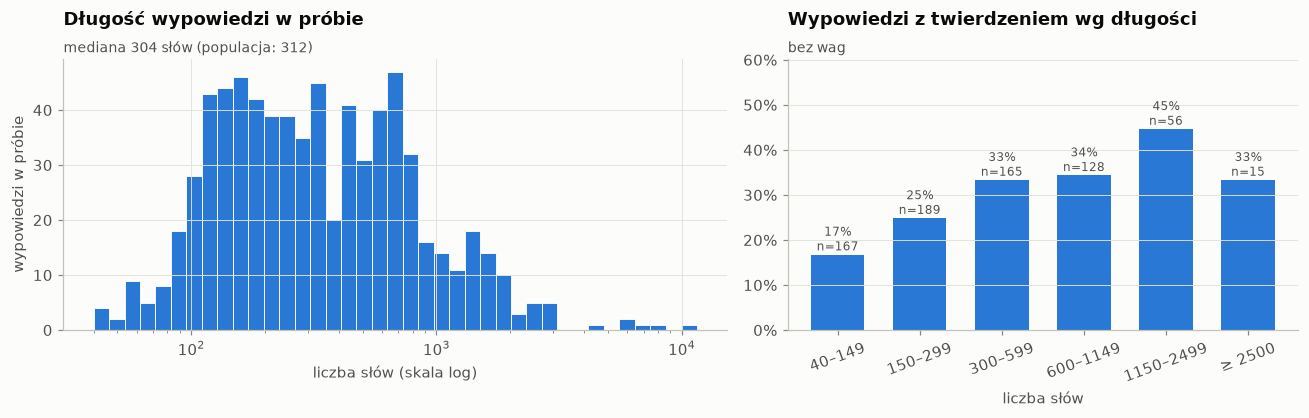

,wypowiedzi,z_twierdzeniem,twierdzenia_na_wyp,kandydaci_na_wyp,pelny_limit
dlugosc,,,,,
40–149,167,0.17,0.23,1.38,0.00
150–299,189,0.25,0.43,2.17,0.00
300–599,165,0.33,0.76,3.35,0.00
600–1149,128,0.34,0.77,3.79,0.00
1150–2499,56,0.45,1.21,6.21,0.05
≥ 2500,15,0.33,1.93,5.40,0.07


In [6]:
LEN_BINS = [40, 150, 300, 600, 1150, 2500, np.inf]
LEN_LABELS = ["40–149", "150–299", "300–599", "600–1149", "1150–2499", "≥ 2500"]
df["dlugosc"] = pd.cut(df["liczba_slow"], LEN_BINS, labels=LEN_LABELS, right=False)
df["pelny_limit"] = df["n_kandydatow"] >= df["max_kandydatow"]
by_len = df.groupby("dlugosc", observed=True).agg(
    wypowiedzi=("y", "size"), z_twierdzeniem=("y", "mean"), twierdzenia_na_wyp=("n_twierdzen", "mean"),
    kandydaci_na_wyp=("n_kandydatow", "mean"),
    pelny_limit=("pelny_limit", "mean"))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.9), gridspec_kw={"width_ratios": [1.3, 1]})
bins = np.logspace(np.log10(40), np.log10(df["liczba_slow"].max() + 1), 40)
a1.hist(df["liczba_slow"], bins=bins, color=ACCENT, edgecolor=SURF, linewidth=0.6)
a1.set_xscale("log")
a1.set_xlabel("liczba słów (skala log)"); a1.set_ylabel("wypowiedzi w próbie")
a1.set_title("Długość wypowiedzi w próbie")
subtitle(a1, f"mediana {df['liczba_slow'].median():.0f} słów (populacja: {filt['liczba_slow'].median():.0f})")
x = np.arange(len(by_len))
a2.bar(x, by_len["z_twierdzeniem"], color=ACCENT, width=0.65)
for xi, (p, n) in enumerate(zip(by_len["z_twierdzeniem"], by_len["wypowiedzi"])):
    a2.text(xi, p, f"{p:.0%}\nn={n}", ha="center", va="bottom", fontsize=8, color=INK2)
a2.set_xticks(x, by_len.index, rotation=20); a2.yaxis.set_major_formatter(PCT); a2.grid(axis="x", visible=False)
a2.set_ylim(0, by_len["z_twierdzeniem"].max() * 1.35); a2.set_xlabel("liczba słów")
a2.set_title("Wypowiedzi z twierdzeniem wg długości")
subtitle(a2, "bez wag")
fig.tight_layout()
save(fig, "llm_a_02_dlugosc"); plt.show()
by_len.round(2)

Mediana długości w próbie (304 słowa) jest bliska populacji (312). Odsetek wypowiedzi z twierdzeniem rośnie z długością,
od 17% przy wypowiedziach poniżej 150 słów do 45% przy 1150–2499 słowach: dłuższa wypowiedź daje więcej okazji do twierdzenia.
W pierwszym przebiegu najdłuższe wypowiedzi miały tylko 5% i 0% z powodu przepełnienia kontekstu (sekcja 9.1).

## 2. Lejek detekcji: od kandydatów do twierdzeń

Krok 1 zwraca do 16 zdań-kandydatów z rodzajem zdania. Tylko kandydaci „naukowe” trafiają do kroku 2, który ocenia parafrazę
razem z fragmentem wypowiedzi (zdanie z cytatem i po jednym zdaniu przed i po).

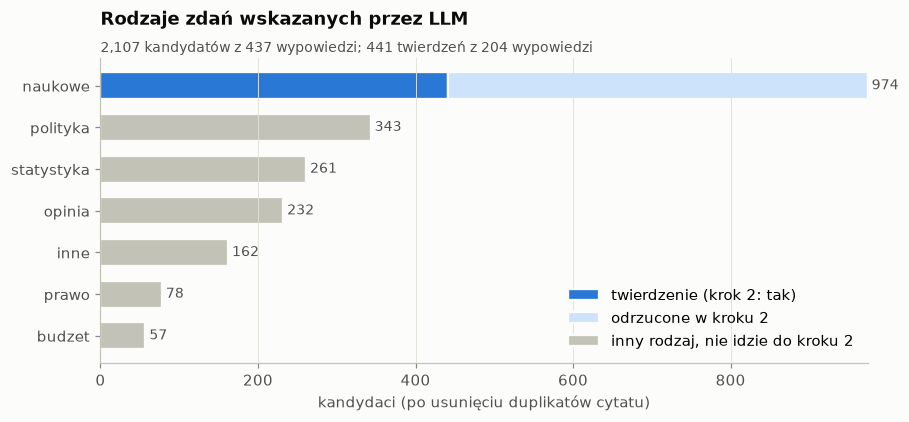

col_0,potwierdzone,odrzucone,niesprawdzane,razem
rodzaj,,,,
naukowe,441,533,0,974
polityka,0,0,343,343
statystyka,0,0,261,261
opinia,0,0,232,232
inne,0,0,162,162
prawo,0,0,78,78
budzet,0,0,57,57


In [7]:
status = np.select([cand["weryfikacja"].eq(True), cand["weryfikacja"].eq(False)], ["potwierdzone", "odrzucone"], "niesprawdzane")
kinds = pd.crosstab(cand["rodzaj"], status).reindex(columns=["potwierdzone", "odrzucone", "niesprawdzane"], fill_value=0)
kinds = kinds.loc[kinds.sum(axis=1).sort_values().index]
STATUS = {"potwierdzone": (ACCENT, "twierdzenie (krok 2: tak)"), "odrzucone": (ACCENT_LIGHT, "odrzucone w kroku 2"),
          "niesprawdzane": (AXIS, "inny rodzaj, nie idzie do kroku 2")}

fig, ax = plt.subplots(figsize=(9, 3.6))
left = np.zeros(len(kinds))
for s in kinds.columns:
    ax.barh(range(len(kinds)), kinds[s], left=left, color=STATUS[s][0], height=0.65, edgecolor=SURF, linewidth=1.5, label=STATUS[s][1])
    left += kinds[s].values
for i, tot in enumerate(left):
    ax.text(tot, i, f" {int(tot)}", va="center", fontsize=9, color=INK2)
ax.set_yticks(range(len(kinds)), kinds.index); ax.grid(axis="y", visible=False)
ax.set_xlabel("kandydaci (po usunięciu duplikatów cytatu)")
ax.legend(loc="lower right")
ax.set_title("Rodzaje zdań wskazanych przez LLM")
subtitle(ax, f"{len(cand):,} kandydatów z {int(df['n_kandydatow'].gt(0).sum())} wypowiedzi; "
             f"{kinds['potwierdzone'].sum()} twierdzeń z {int(df['y'].sum())} wypowiedzi")
save(fig, "llm_a_03_rodzaje"); plt.show()
kinds.loc[::-1].assign(razem=kinds.sum(axis=1))

Z 2107 kandydatów 46% to zdania „naukowe”, a krok 2 potwierdza 45% z nich (441 twierdzeń w 204 wypowiedziach). Najczęstsze inne
rodzaje to polityka i statystyka. Wysoki odsetek odrzuceń w kroku 2 może znaczyć, że krok 1 zbyt łatwo nadaje rodzaj „naukowe”
(i krok 2 słusznie odsiewa), albo że krok 2 gubi prawdziwe twierdzenia. Rozstrzygnęłaby to dopiero ręczna anotacja (sekcja 9.4).

## 3. Agregacja po wypowiedzi

LLM pracuje na twierdzeniach, a hipotezy mówią o wypowiedziach, więc potrzebne są obie jednostki:

* **wypowiedź z twierdzeniem**: wypowiedź z co najmniej jednym potwierdzonym twierdzeniem (0/1);
* **twierdzenia na 100 wypowiedzi**: średnia liczba twierdzeń na wypowiedź × 100;
* **szacunki dla populacji**: suma wag (estymator Horvitza–Thompsona), czyli ile takich wypowiedzi i twierdzeń jest w całej populacji filtra.

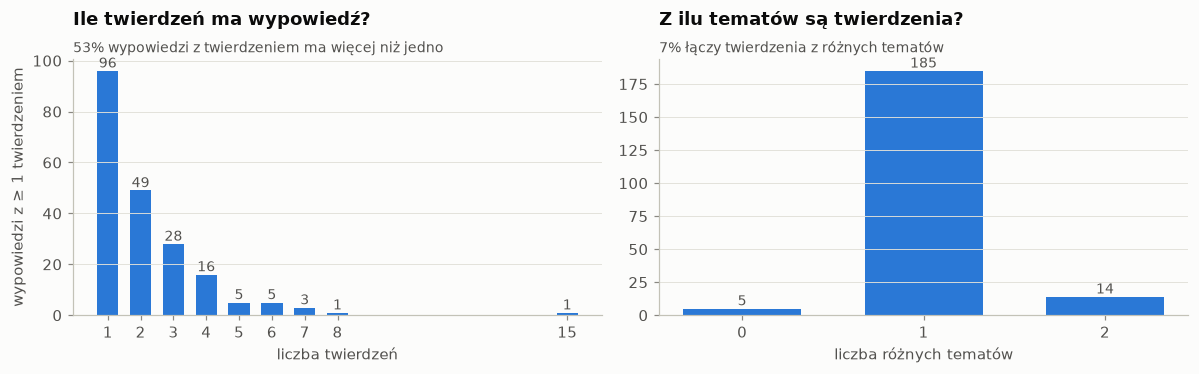

wypowiedzi z twierdzeniem: 204; z > 1 twierdzeniem: 53%; z twierdzeniami z > 1 tematu: 7%


In [8]:
z = df[df["y"] == 1]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, col, title, xl in [(a1, "n_twierdzen", "Ile twierdzeń ma wypowiedź?", "liczba twierdzeń"),
                           (a2, "n_tematow", "Z ilu tematów są twierdzenia?", "liczba różnych tematów")]:
    vc = z[col].value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=ACCENT, width=0.65)
    for k, v in vc.items():
        ax.text(k, v, f"{v}", ha="center", va="bottom", fontsize=9, color=INK2)
    ax.set_xticks(vc.index); ax.grid(axis="x", visible=False); ax.set_xlabel(xl)
    ax.set_title(title)
a1.set_ylabel("wypowiedzi z ≥ 1 twierdzeniem")
subtitle(a1, f"{(z['n_twierdzen'] > 1).mean():.0%} wypowiedzi z twierdzeniem ma więcej niż jedno")
subtitle(a2, f"{(z['n_tematow'] > 1).mean():.0%} łączy twierdzenia z różnych tematów")
fig.tight_layout()
save(fig, "llm_a_04_jednostka"); plt.show()
print(f"wypowiedzi z twierdzeniem: {len(z)}; z > 1 twierdzeniem: {(z['n_twierdzen'] > 1).mean():.0%}; "
      f"z twierdzeniami z > 1 tematu: {(z['n_tematow'] > 1).mean():.0%}")

In [9]:
ones = df.assign(one=1)


def totals(d, by, y="y"):
    """Population total per group: exact size of the filter population x weighted mean from the sample."""
    return (filt.groupby(by).size() * R.weighted_share(d, by, y=y)).dropna()


def unit_table(by, order, labels=None):
    d = df[df[by].notna()]
    b_y = R.bootstrap(d, by).loc[order]
    b_n = R.bootstrap(d, by, y="n_twierdzen").loc[order]
    return pd.DataFrame({
        "n (próba)": b_y["n"],
        "wypowiedzi z twierdzeniem [%]": fmt_ci(b_y),
        "twierdzenia na 100 wypowiedzi": fmt_ci(b_n),
        "twierdzenia na wypowiedź z twierdzeniem": R.weighted_share(d[d["y"] == 1], by, y="n_twierdzen").loc[order].round(2),
        "N populacji (filtr regex)": filt.groupby(by).size().loc[order],
        "szac. wypowiedzi z twierdzeniem": totals(d, by).loc[order].round().astype(int),
        "szac. twierdzenia": totals(d, by, "n_twierdzen").loc[order].round().astype(int),
    }).rename(index=labels or {})


units = pd.concat({
    "okna": unit_table("okno", list(WINDOWS), {k: f"okno {k}" for k in WINDOWS}),
    "ChatGPT": unit_table("chatgpt", ["przed", "po"], CHATGPT_LABEL),
    "okresy H1": unit_table("okres", PERIODS, PERIOD_LABEL),
})
units

n (próba) wypowiedzi z twierdzeniem [%]  \
okna      okno A                72             24.4 [14.0; 35.2]   
          okno B                87              16.8 [9.0; 25.7]   
ChatGPT   przed ChatGPT        475             27.7 [23.0; 32.5]   
          po ChatGPT           245             21.1 [16.1; 26.5]   
okresy H1 przed COVID          305             36.1 [30.0; 41.9]   
          COVID                170             23.6 [17.2; 30.4]   
          po ChatGPT           245             21.1 [16.1; 26.5]   

                        twierdzenia na 100 wypowiedzi  \
okna      okno A                    41.8 [22.7; 62.9]   
          okno B                    24.5 [12.7; 38.6]   
ChatGPT   przed ChatGPT             60.5 [47.7; 74.3]   
          po ChatGPT                38.1 [27.4; 50.3]   
okresy H1 przed COVID              85.1 [68.1; 104.1]   
          COVID                     48.8 [31.8; 67.4]   
          po ChatGPT                38.1 [27.4; 50.3]   

                         twierdzenia na wypowiedź z twierdzeniem  \
okna      okno A                                            1.72   
          okno B                                            1.46   
ChatGPT   przed ChatGPT                                     2.19   
          po ChatGPT                                        1.81   
okresy H1 przed COVID                                       2.36   
          COVID                                             2.07   
          po ChatGPT                                        1.81   

                         N populacji (filtr regex)  \
okna      okno A                              2579   
          okno B                              3037   
ChatGPT   przed ChatGPT                      12285   
          po ChatGPT                          7132   
okresy H1 przed COVID                         3885   
          COVID                               8400   
          po ChatGPT                          7132   

                         szac. wypowiedzi z twierdzeniem  szac. twierdzenia  
okna      okno A                                     628               1078  
          okno B                                     509                743  
ChatGPT   przed ChatGPT                             3398               7437  
          po ChatGPT                                1504               2716  
okresy H1 przed COVID                               1402               3305  
          COVID                                     1986               4103  
          po ChatGPT                                1504               2716

Przykład wypowiedzi z twierdzeniami z kilku tematów (najwięcej tematów w próbie):

In [10]:
ex_id = df.sort_values(["n_tematow", "n_twierdzen"], ascending=False)["wypowiedz_id"].iloc[0]
r = df.set_index("wypowiedz_id").loc[ex_id]
print(f"{ex_id}: {r['data']:%Y-%m-%d}, {GREMIA[r['gremium']]}, {r['rola']}, {r['liczba_slow']} słów")
cl.loc[cl["wypowiedz_id"] == ex_id, ["temat", "atrybucja", "twierdzenie"]]

9_81_2023-08-17_266: 2023-08-17, plenarne, poseł, 330 słów


,temat,atrybucja,twierdzenie
361,klimat,wlasne,Zmiany klimatu przyczyniają się do wzrostu liczby zachorowań na choroby odkleszczowe w Polsce.
362,klimat,wlasne,Ocieplenie klimatu sprzyja aktywności i rozprzestrzenianiu się kleszczy w Polsce.
363,klimat,wlasne,"Kleszczowe zapalenie mózgu to poważna, potencjalnie śmiertelna choroba."
364,klimat,wlasne,Nie istnieje skuteczne lekarstwo na wirusa wywołującego kleszczowe zapalenie mózgu.
365,szczepienia,wlasne,Szczepionka przeciw kleszczowemu zapaleniu mózgu ma skuteczność powyżej 95%.


**Wnioski z agregacji.**

* Ponad połowa (53%) wypowiedzi z twierdzeniem ma ich więcej niż jedno, zwykle z jednego tematu; 7% łączy różne tematy
  (powyżej: ocieplenie klimatu sprzyja kleszczom, a szczepionka chroni przed kleszczowym zapaleniem mózgu). Kilka twierdzeń
  w wypowiedzi może mieć różny status (jedno prawdziwe, drugie fałszywe), więc ocena „cała wypowiedź sprzeczna / niesprzeczna”
  by je mieszała. Dlatego LLM wskazuje pojedyncze twierdzenia, a wynik dla wypowiedzi (w suplemencie karty: „co najmniej jedno
  twierdzenie sprzeczne”) jest ich agregatem.
* **Okna:** twierdzenie ma 24% wypowiedzi z filtra w A i 17% w B (42 i 25 twierdzeń na 100 wypowiedzi). W populacji filtra to
  szacunkowo ok. 630 i 510 wypowiedzi z twierdzeniem oraz ok. 1,1 tys. i 0,7 tys. twierdzeń. Przedziały są szerokie (5.5).
* **ChatGPT i okresy H1:** obie miary spadają. Przed COVID twierdzenie ma 36% wypowiedzi i jest 85 twierdzeń na 100 wypowiedzi,
  w kolejnych okresach 21–24% i 38–49.
* Liczby bezwzględne pokazują coś innego: szacowana liczba twierdzeń w populacji jest najwyższa w okresie COVID (ok. 4,1 tys.
  wobec 3,3 tys. przed COVID), bo populacja filtra jest ponad dwa razy większa. Okresy mają przy tym różną długość
  (ok. 4,2 / 2,8 / 3,8 roku; okna po ok. 15 miesięcy). Wybór miary i mianownika może więc zmienić wniosek (sekcja 10.3).

## 4. Tematy

### 4.1 Ile materiału daje każdy temat: słownik a LLM

Dla każdego tematu w próbie: ile wypowiedzi ma trafienie słownika (jak w `01`), a ile zawiera twierdzenie naukowe z tego tematu wg LLM.
Zbiory nie są zagnieżdżone: LLM może przypisać temat wypowiedzi bez trafienia słownika.

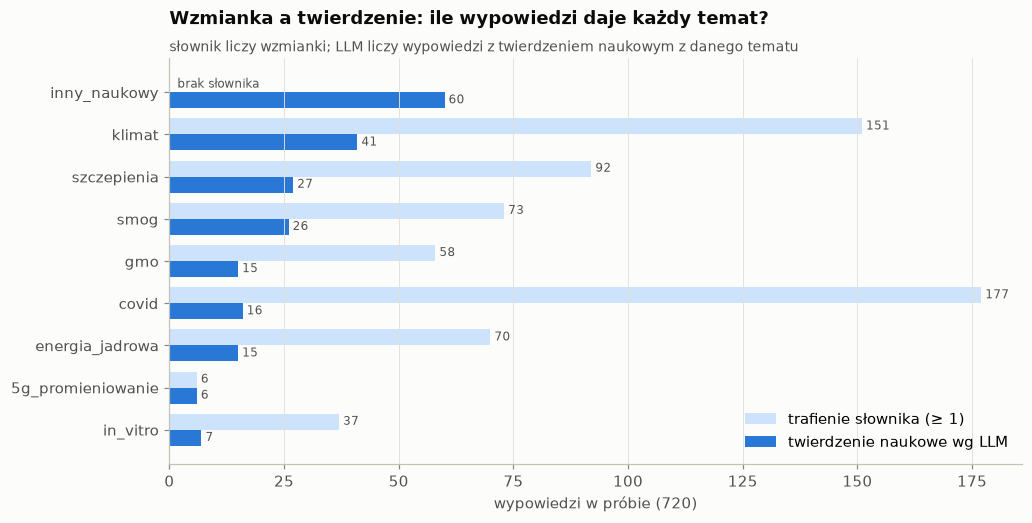

,twierdzenia,wypowiedzi: LLM,wypowiedzi: regex ≥ 1,wypowiedzi: regex ≥ 3,LLM wśród regex ≥ 1 [%],regex ≥ 1 wśród LLM [%]
inny_naukowy,157,60,NaN,NaN,NaN,NaN
klimat,74,41,151.0,33.0,19.9,73.2
szczepienia,53,27,92.0,41.0,26.1,88.9
smog,37,26,73.0,15.0,28.8,80.8
gmo,29,15,58.0,22.0,25.9,100.0
covid,28,16,177.0,45.0,7.9,87.5
energia_jadrowa,26,15,70.0,14.0,14.3,66.7
5g_promieniowanie,15,6,6.0,4.0,100.0,100.0
in_vitro,13,7,37.0,10.0,18.9,100.0


In [11]:
rows = []
for t in TOPICS_LLM:
    llm_t = df[f"tw_{t}"].eq(1)
    row = {"twierdzenia": int(cl["temat"].eq(t).sum()), "wypowiedzi: LLM": int(llm_t.sum())}
    if t in TOPICS:
        rx = df[t].gt(0)
        row |= {"wypowiedzi: regex ≥ 1": int(rx.sum()), "wypowiedzi: regex ≥ 3": int(df[t].ge(T.PROG).sum()),
                "LLM wśród regex ≥ 1 [%]": 100 * llm_t[rx].mean(),
                "regex ≥ 1 wśród LLM [%]": 100 * rx[llm_t].mean() if llm_t.any() else np.nan}
    rows.append(row)
topics_tab = pd.DataFrame(rows, index=TOPICS_LLM).sort_values("twierdzenia", ascending=False)

order = topics_tab.index[::-1]
yy = np.arange(len(order)); h = 0.38
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.barh(yy + h / 2, topics_tab.loc[order, "wypowiedzi: regex ≥ 1"].fillna(0), height=h, color=ACCENT_LIGHT, label="trafienie słownika (≥ 1)")
ax.barh(yy - h / 2, topics_tab.loc[order, "wypowiedzi: LLM"], height=h, color=ACCENT, label="twierdzenie naukowe wg LLM")
for yi, t in enumerate(order):
    a, b = topics_tab.at[t, "wypowiedzi: regex ≥ 1"], topics_tab.at[t, "wypowiedzi: LLM"]
    ax.text(0 if np.isnan(a) else a, yi + h / 2, "  brak słownika" if np.isnan(a) else f" {a:.0f}", va="center", fontsize=8, color=INK2)
    ax.text(b, yi - h / 2, f" {b}", va="center", fontsize=8, color=INK2)
ax.set_yticks(yy, order); ax.grid(axis="y", visible=False)
ax.set_xlabel("wypowiedzi w próbie (720)")
ax.legend(loc="lower right")
ax.set_title("Wzmianka a twierdzenie: ile wypowiedzi daje każdy temat?")
subtitle(ax, "słownik liczy wzmianki; LLM liczy wypowiedzi z twierdzeniem naukowym z danego tematu")
save(fig, "llm_a_05_tematy_skala"); plt.show()
topics_tab.round(1)

* **Ponad jedna trzecia twierdzeń jest spoza słowników.** Najwięcej twierdzeń (157 z 441) LLM przypisał do `inny_naukowy`:
  zdrowie publiczne, onkologia, weterynaria, ochrona roślin, energetyka. Słowniki nie były ustawione na ten materiał.
* **Wzmianka rzadko oznacza twierdzenie.** Wśród wypowiedzi ze słowem ze słownika COVID tylko 8% (14 ze 177) zawiera twierdzenie
  naukowe o COVID; dla klimatu 20%, szczepień 26%, smogu 29%. COVID w Sejmie to głównie organizacja ochrony zdrowia, obostrzenia
  i finansowanie, a nie twierdzenia o wirusie. Skala tematów z `01`, gdzie COVID jest największym tematem, przecenia więc materiał
  dla etapu B.
* W drugą stronę słowniki działają dobrze: 73–100% wypowiedzi z twierdzeniem z danego tematu ma trafienie słownika tego tematu.
  Wyjątek to `energia_jadrowa` (67%), bo LLM używa tej etykiety szerzej (4.4).

### 4.2 Tematy w czasie: okna A i B, przed i po ChatGPT

Wypowiedzi z twierdzeniem z danego tematu **na 1000 wypowiedzi populacji** (estymator ważony), analogicznie do heatmapy kadencji
w `01`. Pod wykresem liczby twierdzeń w próbie: w oknach to pojedyncze twierdzenia, więc wartości dla okien są bardzo niepewne.

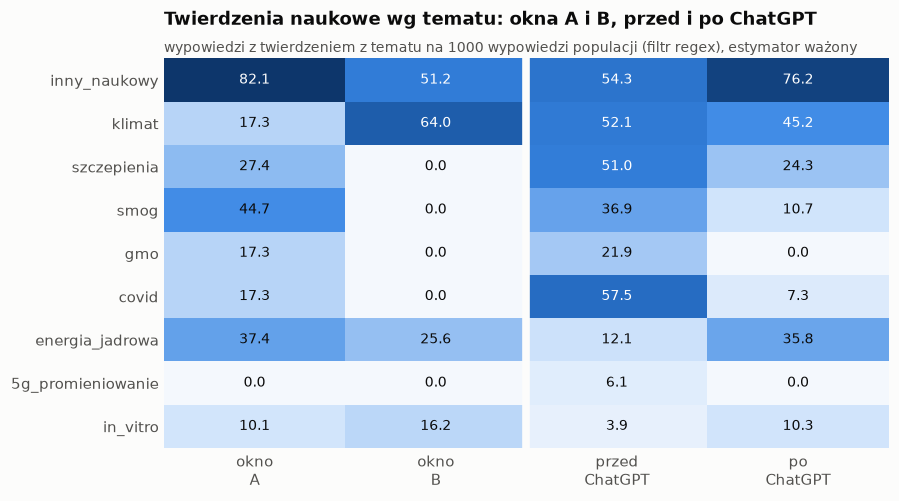

,okno A,okno B,przed ChatGPT,po ChatGPT
inny_naukowy,10,7,118,39
klimat,2,7,58,16
szczepienia,2,0,44,9
smog,6,0,31,6
gmo,3,0,29,0
covid,2,0,26,2
energia_jadrowa,3,3,8,18
5g_promieniowanie,0,0,15,0
in_vitro,2,2,9,4
wypowiedzi w próbie,72,87,475,245


In [12]:
COLS = [("okno", "A", "okno A"), ("okno", "B", "okno B"), ("chatgpt", "przed", "przed ChatGPT"), ("chatgpt", "po", "po ChatGPT")]


def wshare(d, y):
    return (d[y] * d["waga"]).sum() / d["waga"].sum()


heat = pd.DataFrame({lab: [1000 * wshare(df[df[by] == v], f"tw_{t}") for t in topics_tab.index] for by, v, lab in COLS},
                    index=topics_tab.index)
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.imshow(heat.values, cmap=SEQ, aspect="auto", vmin=0)
ax.set_xticks(range(len(COLS)), [lab.replace(" ", "\n", 1) for _, _, lab in COLS]); ax.set_yticks(range(len(heat)), heat.index)
ax.axvline(1.5, color=SURF, lw=5)
ax.grid(False); ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
thr = heat.values.max() * 0.55
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=9, color="white" if v > thr else INK)
ax.set_title("Twierdzenia naukowe wg tematu: okna A i B, przed i po ChatGPT")
subtitle(ax, "wypowiedzi z twierdzeniem z tematu na 1000 wypowiedzi populacji (filtr regex), estymator ważony")
save(fig, "llm_a_06_tematy_okresy"); plt.show()
counts = pd.DataFrame({lab: cl.loc[cl[by] == v, "temat"].value_counts() for by, v, lab in COLS}).reindex(heat.index).fillna(0).astype(int)
counts.loc["wypowiedzi w próbie"] = [int((df[by] == v).sum()) for by, v, _ in COLS]
counts

W oknach liczby są bardzo małe (0–10 twierdzeń na temat): np. klimat 17 → 64 na 1000 to 2 i 7 twierdzeń. Stabilniejsze jest
porównanie przed i po ChatGPT. Po premierze ChatGPT prawie znikają COVID, GMO i 5G, maleją szczepienia i smog, a rośnie
„energia jądrowa” (to głównie CCS i OZE, zob. 4.4). Klimat jest na podobnym poziomie przed i po ChatGPT (52 i 45 na 1000).

### 4.3 Przykładowe twierdzenia (kontrola jakości)

Losowo po dwa twierdzenia z każdego tematu: cytat z wypowiedzi i parafraza LLM. Odpowiednik przeglądu trafień słowników w `01`.

In [13]:
def who(r):
    return r["blok"] if r["rola"] == "poseł" and isinstance(r["blok"], str) else r["rola"]

lines = []
for t in topics_tab.index:
    s = cl[cl["temat"] == t]
    lines.append(f"**{t}**")
    for _, r in s.sample(min(2, len(s)), random_state=3).iterrows():
        lines.append(f"- *{r['data']:%Y-%m-%d}, {GREMIA[r['gremium']]}, {who(r)}:* „{r['cytat']}” → {r['twierdzenie']}")
display(Markdown("\n".join(lines)))

**inny_naukowy**
- *2017-10-26, RRW (rolnictwo), inni:* „Efektem podstawowym takiego wapnowania jest zwiększona przyswajalność nawozów przez glebę, a przez to mniejsze odprowadzenie nawozów do wód gruntowych, a w związku z tym mniejsza strata azotu i fosforu do wód gruntowych, a następnie do Bałtyku.” → Wapnowanie zmniejsza straty azotu i fosforu, ograniczając ich przedostawanie się do wód gruntowych i Bałtyku.
- *2015-12-10, RRW (rolnictwo), rząd:* „Gospodarstwo musi mieć opracowany program monitorowania i zwalczania gryzoni, dokonywać okresowo zabiegów dezynsekcji, rejestrować środki transportu i osoby mające kontakt ze świniami.” → Wymagania bioasekuracji obejmują m.in. monitorowanie gryzoni, dezynsekcję, rejestrację transportu i osób mających kontakt ze świniami.
**klimat**
- *2015-12-29, OSZ (środowisko), PiS:* „Czy ten temat był poruszany? Oczywiście mówię o tym „buraku cukrowym” w takiej przenośni, ale on występował dokładnie jako burak cukrowy.” → Plantacje rolne, takie jak burak cukrowy, mogą mieć znaczący wpływ na redukcję dwutlenku węgla, podobnie jak lasy.
- *2016-01-14, plenarne, rząd:* „To była sprawa związana z rolą lasów i pochłaniania dwutlenku węgla przez żywe zasoby przyrodnicze jako sposobu na walkę ze zmianami klimatu i z ograniczeniem emisji dwutlenku węgla.” → Lasy i żywe zasoby przyrodnicze pochłaniają dwutlenek węgla, co pomaga w walce ze zmianami klimatu.
**szczepienia**
- *2018-10-03, plenarne, inni:* „Trudno jest obecnie przewidzieć, jakie dla stanu uodpornienia populacji będą skutki zniesienia obowiązku szczepień ochronnych przewidzianego w projekcie ustawy. Należy mieć na uwadze, że po zniesieniu obowiązku szczepień ochronnych kolejne roczniki dzieci i młodzieży będą zaszczepione jedynie w odse” → Zniesienie obowiązku szczepień może prowadzić do spadku odsetka zaszczepionych dzieci i młodzieży do około 70%, co stworzy warunki do epidemicznego szerzenia się chorób zakaźnych.
- *2023-06-14, plenarne, KO:* „Przerażające jest bowiem, że na całym świecie średnio co 6 sekund przedwcześnie umiera jedna osoba z powodu palenia papierosów i narażania na oddziaływanie toksycznych substancji dymu nikotynowego, zaś w Polsce palenie tytoniu jest jednym z głównych czynników ryzyka przewlekłych chorób niezakaźnych.” → Palenie tytoniu jest jednym z głównych czynników ryzyka przewlekłych chorób niezakaźnych i powoduje przedwczesne zgony.
**smog**
- *2017-01-26, plenarne, rząd:* „w zakresie jakości powietrza, jeżeli chodzi o te wielkie instalacje, przemysłowe, ustanowiono pewnego rodzaju rekord świata, dlatego że dokonaliśmy redukcji do roku, o ile mnie pamięć nie myli, 2004 na poziomie pięćdziesięciu paru procent, a w tej chwili na poziomie 80%” → Dokonano znaczącej redukcji zanieczyszczeń powietrza z wielkich instalacji przemysłowych w Polsce, osiągając poziom 80% redukcji w porównaniu do 2004 roku.
- *2020-02-12, plenarne, KO:* „Już dziś każdego roku umiera 45 tys. Polaków z powodu smogu.” → Smog powoduje rocznie 45 tys. zgonów w Polsce.
**gmo**
- *2018-02-06, OSZ (środowisko), inni:* „wydaje się że cała procedura wydawania pozwolenia dopuszczania GMO do uprawy i decyzja warunków prowadzenia uprawy ze strony organu gwarantują, że podmiot, który będzie ją prowadził zgodnie z nimi, nie będzie powodował tych szkód, które tu zostały wymienione.” → Procedura wydawania pozwolenia na uprawę GMO i warunki prowadzenia uprawy gwarantują, że podmiot przestrzegający tych warunków nie spowoduje szkód.
- *2018-01-10, OSZ (środowisko), rząd:* „Będzie to weryfikowane przez potężne grono naukowców, przyrodników, genetyków itd.” → Weryfikacja wniosków dotyczących GMO odbywa się przez zespół ekspertów naukowych.
**covid**
- *2021-04-15, plenarne, KO:* „Szczepienia, testy i tlen są głównymi narzędziami w walce z COVID-19.” → Szczepienia, testy i tlen ograniczają liczbę zgonów z powodu COVID-19.
- *2021-04-15, plenarne, KO:* „COVID zabija na całym świecie.” → COVID-19 powoduje zgony na całym świecie.
**energia_jadrowa**
- *2024-01-24, OSZ (środowisko), inni:* „Jesteśmy przekonani, że w całym cyklu życia reaktora, czyli 60 latach, ta emisyjność pozwali na oszczędzenie 175 mln ton CO2.” → Reaktor jądrowy BWRX-300 pozwoli zaoszczędzić 175 mln ton CO2 w ciągu 60 lat eksploatacji.
- *2024-01-24, OSZ (środowisko), inni:* „Emisyjność reaktorów jądrowych w pełnej skali, czyli od kołyski do końca eksploatacji, jest dzisiaj najniższa i porównywana z wiatrem, i umożliwi głęboką dekarbonizację polskiej gospodarki.” → Emisyjność reaktorów jądrowych jest najniższa w porównaniu z innymi źródłami energii i umożliwia dekarbonizację polskiej gospodarki.
**5g_promieniowanie**
- *2019-07-16, OSZ (środowisko), inni:* „To nie jest do końca prawda, że wszyscy naukowcy się zgadzają, że to nie ma skutków negatywnych” → Nie wszyscy naukowcy zgadzają się co do braku negatywnych skutków 5G, co potwierdzają międzynarodowe apele naukowców.
- *2019-07-03, plenarne, KO:* „Nie da się uruchomić sieci internetowej 5G bez dostępu do pasma 700 MHz.” → Dostęp do pasma 700 MHz jest niezbędny do uruchomienia sieci 5G.
**in_vitro**
- *2016-09-22, plenarne, KO:* „metoda in vitro jest najskuteczniejszą obecnie dostępną procedurą medyczną w leczeniu niepłodności.” → In vitro to najskuteczniejsza dostępna metoda leczenia niepłodności.
- *2016-09-22, plenarne, KO:* „dzięki metodzie in vitro na świecie w tej chwili urodziło się 6,5 mln dzieci.” → Metoda in vitro umożliwiła urodzenie 6,5 mln dzieci na świecie.

### 4.4 Temat `energia_jadrowa`

Czy twierdzenia oznaczone jako energia jądrowa dotyczą atomu (słowa kluczowe w cytacie lub parafrazie)?

In [14]:
NUC = r"jądr|atom|reaktor|uran|SMR"
ej = cl[cl["temat"] == "energia_jadrowa"]
about = ej["twierdzenie"].str.contains(NUC, case=False) | ej["cytat"].str.contains(NUC, case=False)
print(f"energia_jadrowa: {len(ej)} twierdzeń, o atomie: {about.mean():.0%}")
ej.loc[~about, ["rok", "twierdzenie"]]

energia_jadrowa: 26 twierdzeń, o atomie: 31%


,rok,twierdzenie
73,2016,"Magazyny energii dla wiatraków nie są jeszcze opłacalne, z wyjątkiem specjalistycznych rozwiązań, takich jak koszt Benninga."
207,2018,"Efektywność jednoczesnej produkcji ciepła i prądu jest o ok. 50% wyższa niż w przypadku ich oddzielnego wytwarzania, co prowadzi do ograniczenia emisji zanieczyszczeń."
212,2019,Wyniki badań zostaną wykorzystane do analiz i symulacji na potrzeby raportów środowiskowych i lokalizacyjnych.
264,2020,Efektywność OZE zależy od warunków pogodowych - sama moc zainstalowana nie gwarantuje produkcji energii.
326,2022,OZE nie są stabilnym źródłem energii.
347,2023,System CCS (carbon capture and storage) jest potrzebny dla przemysłu cementowego w celu redukcji emisji CO2.
354,2023,"Technologia podziemnego składowania dwutlenku węgla jest sprawdzona i stosowana na szeroką skalę w wielu krajach, w tym w Stanach Zjednoczonych, Kanadzie i Europie."
355,2023,"Nie wszystkie obszary w Polsce nadają się do podziemnego składowania dwutlenku węgla, co wynika z wymagań geologicznych."
356,2023,"Zatłaczanie CO2 do górotworów złoż węglowodorów zwiększa energię złożową, co pozwala na efektywniejsze pozyskiwanie ropy naftowej i gazu ziemnego."
357,2023,"Zbiorniki na dwutlenek węgla muszą spełniać określone kryteria szczelności, aby zapewnić bezpieczeństwo."


Tylko 8 z 26 twierdzeń `energia_jadrowa` dotyczy atomu. Reszta to składowanie CO2 (7 twierdzeń z jednej wypowiedzi eksperckiej
z 2023 r.), OZE, energetyka wiatrowa i kogeneracja: model traktuje etykietę jako „energetyka”. Analiza per temat musi to uwzględniać
(np. osobny temat `energetyka` albo doprecyzowanie etykiety w prompcie).

## 5. Czas

### 5.1 Udział wypowiedzi z twierdzeniem i liczba twierdzeń, wg roku

Obie miary z estymatora ważonego; 95% przedział z bootstrapu (losowanie ze zwracaniem w obrębie roku, 2000 powtórzeń).
Na wykresach rocznych szare pasy to okna A i B, linie kropkowane to początek COVID w Europie i premiera ChatGPT.

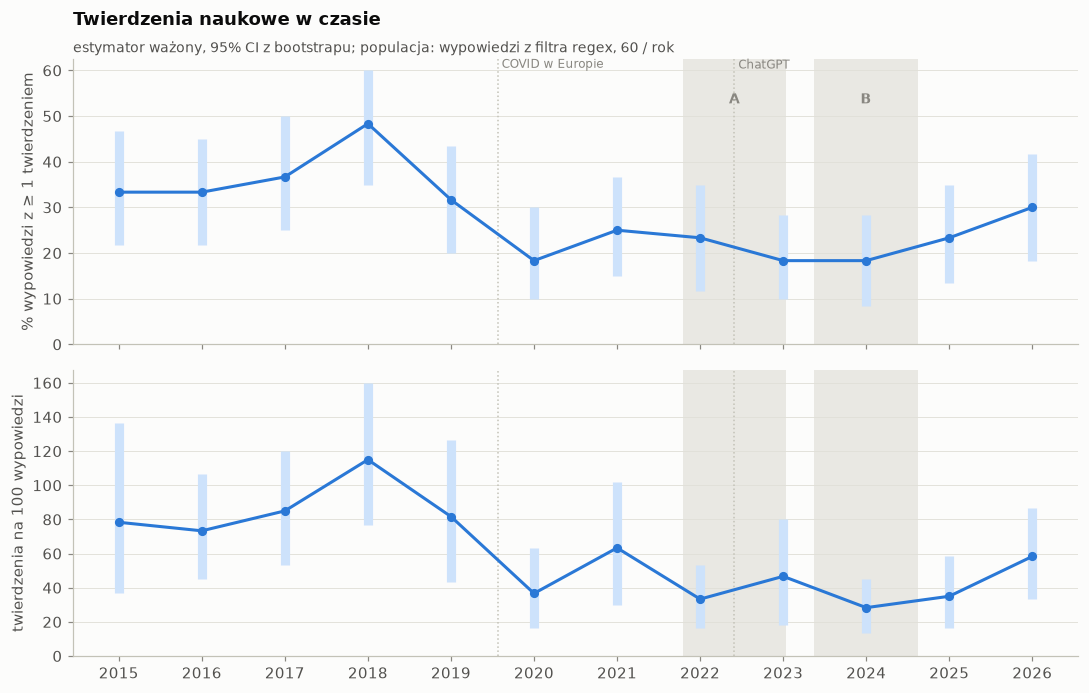

,n,z twierdzeniem [%],twierdzenia / 100 wyp.
rok,,,
2015,60,33.3 [21.7; 46.7],78.3 [36.7; 136.7]
2016,60,33.3 [21.7; 45.0],73.3 [45.0; 106.7]
2017,60,36.7 [25.0; 50.0],85.0 [53.3; 120.0]
2018,60,48.3 [35.0; 60.0],115.0 [76.7; 160.0]
2019,60,31.7 [20.0; 43.3],81.7 [43.3; 126.7]
2020,60,18.3 [10.0; 30.0],36.7 [16.7; 63.4]
2021,60,25.0 [15.0; 36.7],63.3 [30.0; 101.7]
2022,60,23.3 [11.7; 35.0],33.3 [16.7; 53.3]
2023,60,18.3 [10.0; 28.3],46.7 [18.3; 80.0]


In [15]:
yr_y = R.bootstrap(df, "rok")
yr_n = R.bootstrap(df, "rok", y="n_twierdzen")
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6.4), sharex=True)
for ax, b, lab in [(a1, yr_y, "% wypowiedzi z ≥ 1 twierdzeniem"), (a2, yr_n, "twierdzenia na 100 wypowiedzi")]:
    ax.errorbar(b.index, b["p"] * 100, yerr=[(b["p"] - b["lo"]) * 100, (b["hi"] - b["p"]) * 100],
                fmt="o-", color=ACCENT, ecolor=ACCENT_LIGHT, elinewidth=6, capsize=0, ms=5)
    ax.set_ylim(0, None); ax.set_ylabel(lab); ax.grid(axis="x", visible=False)
    period_lines(ax, label=ax is a1)
a2.set_xticks(yr_y.index)
a1.set_title("Twierdzenia naukowe w czasie")
subtitle(a1, "estymator ważony, 95% CI z bootstrapu; populacja: wypowiedzi z filtra regex, 60 / rok")
fig.tight_layout()
save(fig, "llm_a_udzial_rok"); plt.show()
pd.DataFrame({"n": yr_y["n"], "z twierdzeniem [%]": fmt_ci(yr_y), "twierdzenia / 100 wyp.": fmt_ci(yr_n)}, index=yr_y.index)

Udział wypowiedzi z twierdzeniem jest najwyższy w latach 2015–2019 (32–48%, szczyt w 2018), najniższy w 2020, 2023 i 2024 (18%),
a w 2026 wraca do 30%. Przedział dla pojedynczego roku ma szerokość ok. 25 pp, więc różnice z roku na rok mieszczą się w szumie.
Stabilniejsze są porównania dłuższych okresów (5.5, 5.8, 5.9).

### 5.2 Wolumen: ile twierdzeń jest w populacji

Udział to nie wszystko: w 2020–2022 populacja filtra jest 2–4 razy większa niż w 2016–2019 (COVID podnosi liczbę trafień słowników).
Szacowane liczby bezwzględne:

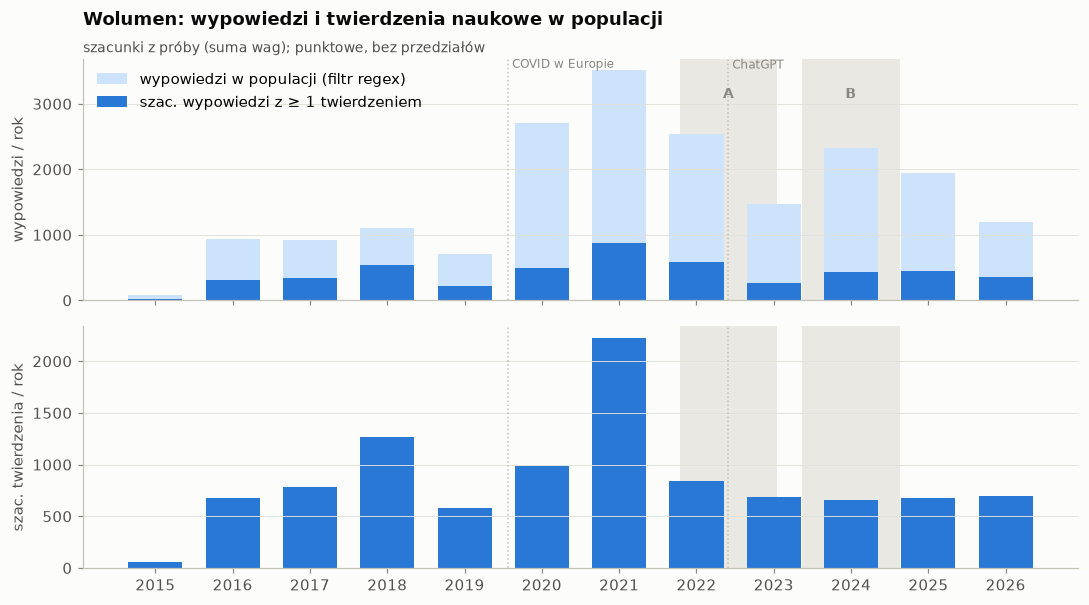

rok,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
N populacji,75,929,924,1103,706,2700,3515,2538,1473,2327,1938,1189
szac. wyp. z twierdzeniem,25,310,339,533,224,495,879,592,270,427,452,357
szac. twierdzenia,59,681,785,1268,577,990,2226,846,687,659,678,694


In [16]:
N_year = R.weighted_total(ones, "rok", y="one")
est_y = R.weighted_total(df, "rok")
est_n = R.weighted_total(df, "rok", y="n_twierdzen")
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 5.6), sharex=True)
a1.bar(N_year.index, N_year, color=ACCENT_LIGHT, width=0.7, label="wypowiedzi w populacji (filtr regex)")
a1.bar(est_y.index, est_y, color=ACCENT, width=0.7, label="szac. wypowiedzi z ≥ 1 twierdzeniem")
a1.legend(loc="upper left"); a1.set_ylabel("wypowiedzi / rok"); a1.grid(axis="x", visible=False)
period_lines(a1)
a2.bar(est_n.index, est_n, color=ACCENT, width=0.7)
a2.set_ylabel("szac. twierdzenia / rok"); a2.grid(axis="x", visible=False)
period_lines(a2, label=False)
a2.set_xticks(N_year.index)
a1.set_title("Wolumen: wypowiedzi i twierdzenia naukowe w populacji")
subtitle(a1, "szacunki z próby (suma wag); punktowe, bez przedziałów")
fig.tight_layout()
save(fig, "llm_a_07_wolumen"); plt.show()
pd.DataFrame({"N populacji": N_year.round().astype(int), "szac. wyp. z twierdzeniem": est_y.round().astype(int),
              "szac. twierdzenia": est_n.round().astype(int)}).T

W liczbach bezwzględnych obraz się odwraca: w 2021 r. szacujemy ok. 2,2 tys. twierdzeń, najwięcej w całym okresie, bo populacja
liczy 3,5 tys. wypowiedzi. Spadek udziału w latach COVID wynika więc przynajmniej częściowo z mianownika. Filtr regex przepuszcza
wtedy wiele wypowiedzi o pandemii, w których nie ma twierdzeń naukowych (4.1: tylko 8% wypowiedzi wspominających COVID
ma twierdzenie o COVID).

### 5.3 Tematy w czasie

Szacowana liczba wypowiedzi z twierdzeniem z danego tematu, wg roku (odpowiednik wykresu tematów w czasie z `01`).
W nawiasie liczba wypowiedzi w próbie, na której opiera się szacunek.

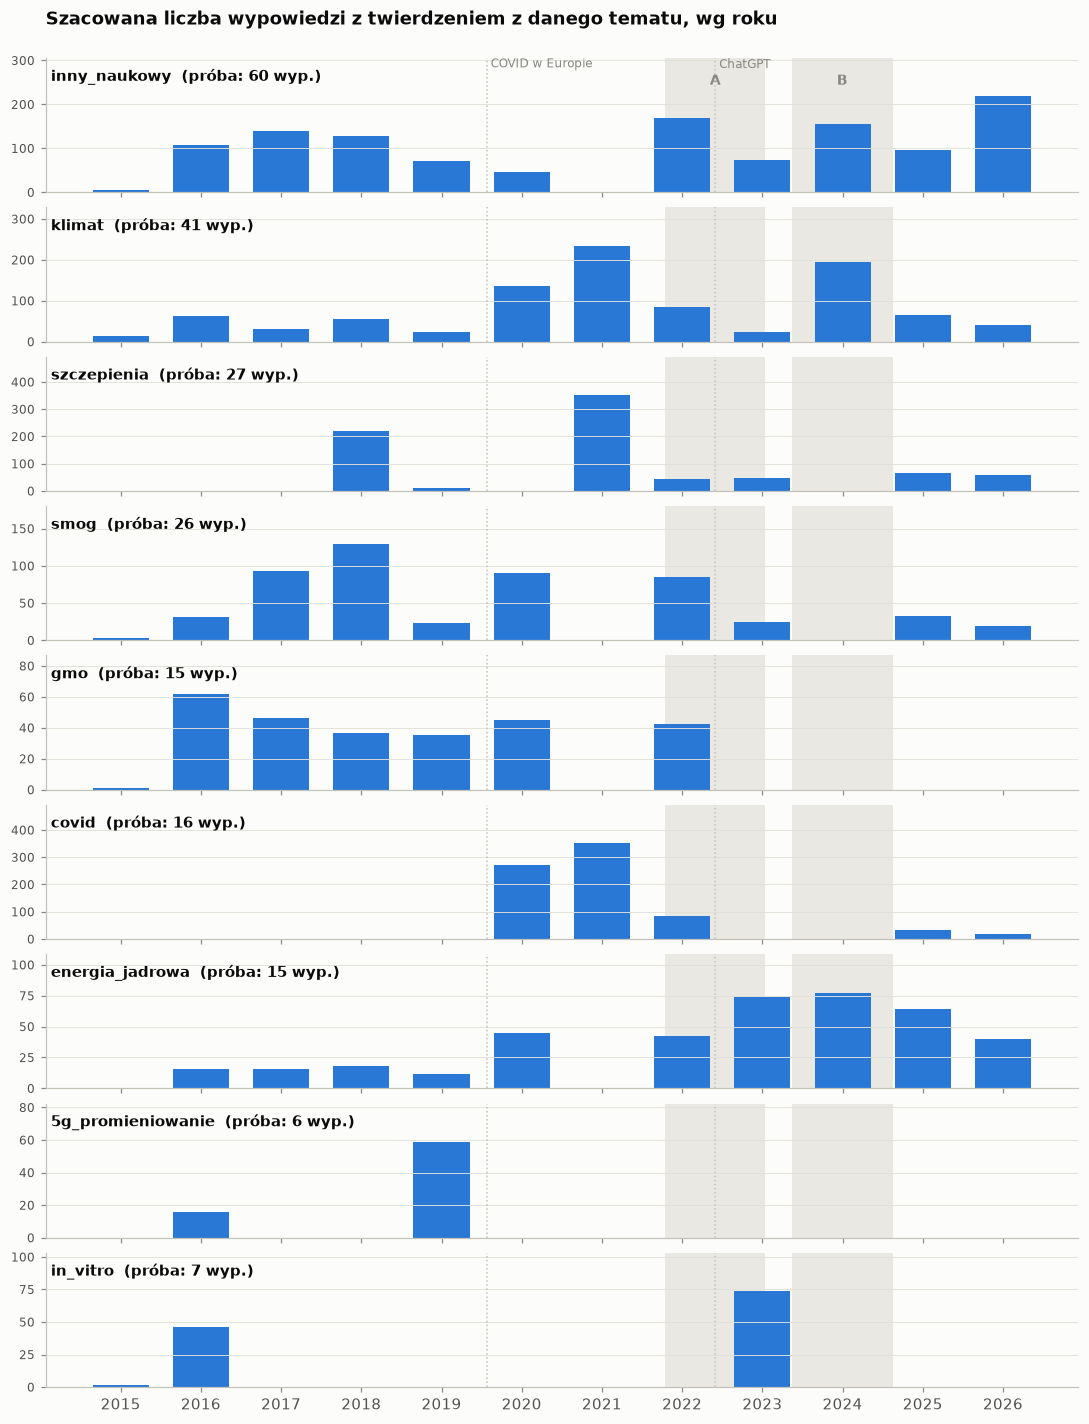

In [17]:
est_topic = pd.DataFrame({t: R.weighted_total(df, "rok", y=f"tw_{t}") for t in TOPICS_LLM})
fig, axes = plt.subplots(len(topics_tab), 1, figsize=(10, 1.45 * len(topics_tab)), sharex=True)
for ax, t in zip(axes, topics_tab.index):
    s = est_topic[t]
    ax.bar(s.index, s.values, color=ACCENT, width=0.7)
    period_lines(ax, label=ax is axes[0])
    ax.set_ylim(0, max(s.max() * 1.4, 1))
    ax.text(0.005, 0.92, f"{t}  (próba: {int(df[f'tw_{t}'].sum())} wyp.)", transform=ax.transAxes,
            fontsize=10, fontweight="bold", color=INK, va="top")
    ax.tick_params(axis="y", labelsize=8); ax.grid(axis="x", visible=False)
axes[-1].set_xticks(est_topic.index)
axes[0].set_title("Szacowana liczba wypowiedzi z twierdzeniem z danego tematu, wg roku")
fig.tight_layout(h_pad=0.4)
save(fig, "llm_a_08_tematy_w_czasie"); plt.show()

COVID widać głównie w latach 2020–2022, smog przede wszystkim w latach 2017–2018, GMO znika po 2022 r., a „energię jądrową”
najczęściej w latach 2022–2025. Szacunki dla
pojedynczego tematu i roku opierają się na 0–5 wypowiedziach z próby, więc wykres pokazuje raczej, kiedy temat w ogóle występuje,
niż jak często.

### 5.4 Okna A i B: populacja (cały korpus)

Liczby z całego korpusu, nie z próby: ile wypowiedzi jest w każdym oknie, ile z nich przechodzi filtr regex, ilu jest mówców,
jak długie są wypowiedzi i jaką część mówią przedstawiciele rządu i goście (`inni`). Kolumna „próba LLM” pokazuje, ile wypowiedzi
z próby wypada w oknie.

In [18]:
wm = mer[mer["okno"].notna()]
wf = filt[filt["okno"].notna()]
g_m, g_f = wm.groupby(["zrodlo", "okno"]), wf.groupby(["zrodlo", "okno"])
win_pop = pd.DataFrame({
    "dni posiedzeń": g_m["data"].nunique(),
    "wypowiedzi merytoryczne": g_m.size(),
    "filtr regex": g_f.size(),
    "% w filtrze": 100 * g_f.size() / g_m.size(),
    "próba LLM": df[df["okno"].notna()].groupby(["zrodlo", "okno"]).size(),
    "mówcy (filtr)": g_f["mowca"].nunique(),
    "mediana słów (filtr)": g_f["liczba_slow"].median(),
    "% rząd (filtr)": 100 * g_f["rola"].apply(lambda s: s.eq("rząd").mean()),
    "% inni (filtr)": 100 * g_f["rola"].apply(lambda s: s.eq("inni").mean()),
})
gap = mer["data"].between(WINDOWS["A"][1] + pd.Timedelta(days=1), WINDOWS["B"][0] - pd.Timedelta(days=1))
print(f"poza oknami: luka 17.07–12.11.2023 (kampania, wybory, czas do 1. posiedzenia X kadencji): {gap.sum():,} wypowiedzi merytorycznych")
win_pop.round(1)

poza oknami: luka 17.07–12.11.2023 (kampania, wybory, czas do 1. posiedzenia X kadencji): 1,057 wypowiedzi merytorycznych


dni posiedzeń  wypowiedzi merytoryczne  filtr regex  \
zrodlo   okno                                                        
komisje  A                91                     8342          869   
         B                94                     6397         1071   
plenarne A                64                    16392         1710   
         B                86                    16404         1966   

               % w filtrze  próba LLM  mówcy (filtr)  mediana słów (filtr)  \
zrodlo   okno                                                                
komisje  A            10.4         30            390                 399.0   
         B            16.7         22            451                 398.0   
plenarne A            10.4         42            388                 317.0   
         B            12.0         65            414                 250.0   

               % rząd (filtr)  % inni (filtr)  
zrodlo   okno                                  
komisje  A               22.1            31.5  
         B               21.9            29.9  
plenarne A               13.9             1.9  
         B                9.5             1.3

* Okna mają prawie tyle samo wypowiedzi plenarnych (16 392 i 16 404), choć w B jest więcej dni posiedzeń (86 wobec 64).
  W komisjach w B jest mniej wypowiedzi (6 397 wobec 8 342), ale więcej z nich przechodzi filtr (17% wobec 10%).
* Filtr regex przepuszcza 1 710 (A) i 1 966 (B) wypowiedzi plenarnych oraz 869 i 1 071 z komisji; razem 2 579 i 3 037.
* Wypowiedzi plenarne z filtra są w B krótsze: mediana 250 słów wobec 317. Odsetek wypowiedzi z twierdzeniem rośnie z długością
  (sekcja 1), więc krótsze wypowiedzi już przez to mogą zawierać mniej twierdzeń.
* Przedstawiciele rządu mówią 14% wypowiedzi plenarnych z filtra w A i 10% w B. Zmienia się też to, kto jest rządem: w A rządzi
  PiS, w B koalicja KO, PSL, Polska 2050 i Lewica.
* Próba LLM ma w oknach tylko 72 (A) i 87 (B) wypowiedzi, w tym 42 i 65 plenarnych, czyli ok. 3% populacji filtra. Dlatego niżej
  liczności tematów liczymy na całym korpusie, a wyniki LLM w oknach traktujemy jako rząd wielkości.
* Okres między oknami (17.07–12.11.2023) to 1 057 wypowiedzi merytorycznych poza analizą.

#### Tematy w oknach

Ile wypowiedzi wspomina każdy temat (≥ 1 trafienie słownika) i ile jest wypowiedzi tematycznych (≥ 3 trafienia, definicja z `01`),
osobno dla posiedzeń plenarnych i komisji. To odpowiedź na pytanie, jak rzadkie są wypowiedzi tematyczne w oknach. Wykres pokazuje
wzmianki na 1000 wypowiedzi merytorycznych, żeby dało się porównać okna i źródła. Druga tabela pokazuje, czy wzmianki są
rozłożone w czasie, czy skupione w kilku debatach.

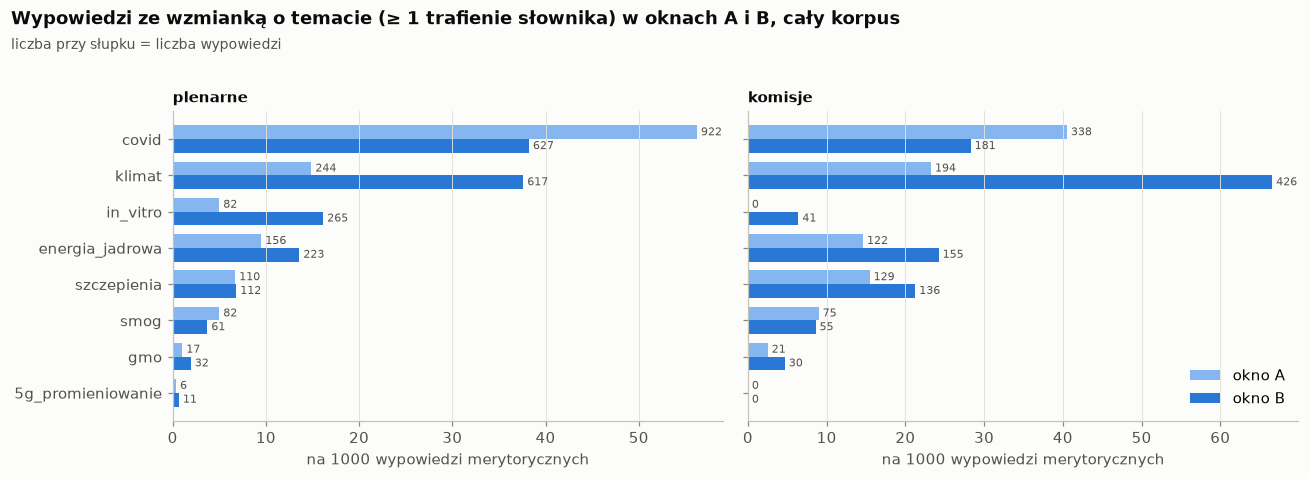

plenarne                 komisje               
                       ≥ 1        ≥ 3          ≥ 1       ≥ 3     
                         A     B    A    B       A    B    A    B
szczepienia            110   112   33   43     129  136   61   71
covid                  922   627  150  114     338  181   80   29
klimat                 244   617   32  145     194  426   28  106
energia_jadrowa        156   223   39   44     122  155   43   64
gmo                     17    32    4    9      21   30    5    5
5g_promieniowanie        6    11    0    4       0    0    0    0
smog                    82    61   17   12      75   55   24   19
in_vitro                82   265   16   90       0   41    0    9
dowolny temat         1503  1756  282  447     775  912  221  285

**Koncentracja w czasie: % wzmianek o temacie (plenarne + komisje) z dwóch dni z największą liczbą wzmianek**

,okno A,okno B
szczepienia,15.0,21.0
covid,7.0,8.0
klimat,11.0,9.0
energia_jadrowa,29.0,13.0
gmo,66.0,44.0
5g_promieniowanie,50.0,64.0
smog,31.0,22.0
in_vitro,39.0,51.0


In [19]:
SRC = ["plenarne", "komisje"]
tab = {}
for src in SRC:
    for thr in (1, T.PROG):
        for k in WINDOWS:
            hit = wm[(wm["zrodlo"] == src) & (wm["okno"] == k)][TOPICS].ge(thr)
            tab[(src, f"≥ {thr}", k)] = pd.concat([hit.sum(), pd.Series({"dowolny temat": hit.any(axis=1).sum()})])
win_topics = pd.DataFrame(tab)
rate = {(src, k): wm[(wm["zrodlo"] == src) & (wm["okno"] == k)][TOPICS].ge(1).mean() * 1000 for src in SRC for k in WINDOWS}

order = win_topics[("plenarne", "≥ 1", "B")].drop("dowolny temat").sort_values().index
yy, h = np.arange(len(order)), 0.38
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
for ax, src in zip(axes, SRC):
    for j, k in enumerate(WINDOWS):
        v = rate[(src, k)].loc[order]
        ax.barh(yy + (0.5 - j) * h, v, height=h, color=WIN_KOLOR[k], label=f"okno {k}")
        for yi, (val, n) in enumerate(zip(v, win_topics.loc[order, (src, "≥ 1", k)])):
            ax.text(val, yi + (0.5 - j) * h, f" {n}", va="center", fontsize=7.5, color=INK2)
    ax.set_yticks(yy, order); ax.grid(axis="y", visible=False)
    ax.set_xlabel("na 1000 wypowiedzi merytorycznych")
    ax.set_title(src, fontsize=10, pad=6)
axes[1].legend(loc="lower right")
fig.suptitle("Wypowiedzi ze wzmianką o temacie (≥ 1 trafienie słownika) w oknach A i B, cały korpus", x=0.01, ha="left",
             fontsize=12, fontweight="bold", color=INK)
fig.text(0.01, 0.9, "liczba przy słupku = liczba wypowiedzi", fontsize=9, color=INK2)
fig.tight_layout(rect=(0, 0, 1, 0.92))
save(fig, "llm_a_17_okna_tematy"); plt.show()
display(win_topics)


def top_days(k, t, n=2):
    hit = wm[(wm["okno"] == k) & (wm[t] >= 1)]
    return 100 * hit.groupby("data").size().nlargest(n).sum() / max(len(hit), 1)


display(Markdown("**Koncentracja w czasie: % wzmianek o temacie (plenarne + komisje) z dwóch dni z największą liczbą wzmianek**"))
pd.DataFrame({f"okno {k}": [top_days(k, t) for t in TOPICS] for k in WINDOWS}, index=TOPICS).round(0)

* Wypowiedzi z jakąkolwiek wzmianką to w obu oknach ok. 9–11% wypowiedzi plenarnych (1 503 i 1 756) i 9–14% komisyjnych
  (775 i 912). Wypowiedzi tematycznych (≥ 3 trafienia) jest kilka razy mniej: 282 i 447 na posiedzeniach plenarnych,
  221 i 285 w komisjach.
* Klimat to temat, który rośnie najbardziej: na posiedzeniach plenarnych 244 → 617 wzmianek (15 → 38 na 1000 wypowiedzi)
  i 32 → 145 wypowiedzi tematycznych, w komisjach 194 → 426. COVID słabnie (922 → 627 wzmianek plenarnych), bo okno A obejmuje
  jeszcze końcówkę pandemii.
* In vitro rośnie w B (82 → 265 wzmianek plenarnych), ale wzrost jest skupiony w jednej debacie: 51% wzmianek z okna B
  (plenarne i komisje) pochodzi z dwóch dni posiedzeń. Podobnie skupione są GMO i 5G (44–66% wzmianek z dwóch dni). Klimat jest
  rozłożony w czasie (11% i 9%), więc jego wzrost nie wynika z jednej debaty.
* Tematy pojawiają się falami, przy okazji konkretnych ustaw, więc wypowiedzi są skupione nie tylko w mówcach, ale też w dniach
  posiedzeń.
* GMO, 5G i smog to w każdym oknie od kilku do kilkudziesięciu wypowiedzi tematycznych, za mało na osobną analizę w jednym oknie.
* Słowniki liczą wzmianki, nie twierdzenia: twierdzenie naukowe z tematu ma tylko część wypowiedzi ze wzmianką (4.1), więc
  materiału do weryfikacji jest kilka razy mniej (5.5).

### 5.5 Okna A i B: twierdzenia naukowe (próba LLM)

Udział wypowiedzi z twierdzeniem naukowym i liczba twierdzeń na 100 wypowiedzi w oknach, dla całej próby i osobno dla źródeł.
Próba w oknach jest mała (72 i 87 wypowiedzi), więc przedziały są szerokie.

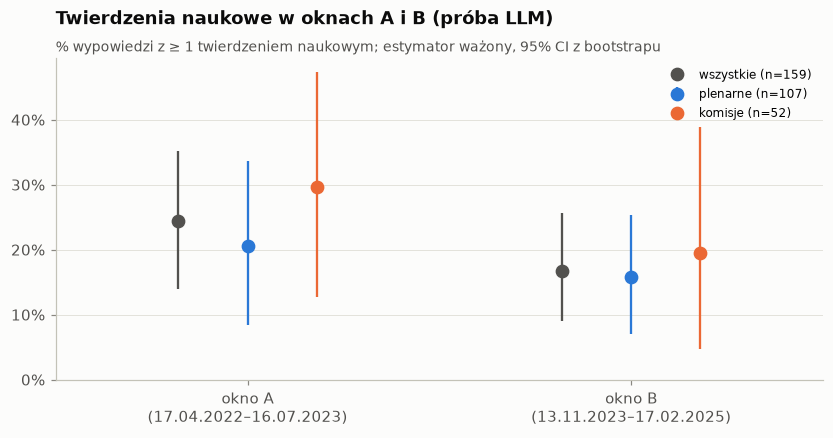

udział komisji: w populacji filtra A 34%, B 35%; w próbie A 42%, B 25%
udział wypowiedzi z twierdzeniem po przeważeniu źródeł do składu populacji okna: A 23.6%, B 17.1%


źródło,wszystkie,plenarne,komisje
n: A,72,42,30
n: B,87,65,22
z twierdzeniem [%]: A,24.4 [14.0; 35.2],20.5 [8.4; 33.6],29.7 [12.8; 47.4]
z twierdzeniem [%]: B,16.8 [9.0; 25.7],15.8 [7.1; 25.4],19.5 [4.7; 38.9]
różnica [pp],-7.6 [-20.9; +6.0],-4.7 [-20.3; +11.1],-10.2 [-34.6; +15.4]
twierdzenia / 100: A,41.8 [22.7; 62.9],30.4 [12.2; 51.4],57.6 [22.7; 98.4]
twierdzenia / 100: B,24.5 [12.7; 38.6],19.3 [8.1; 32.1],39.0 [9.4; 77.8]
różnica (twierdzenia / 100),-17.3 [-41.5; +7.3],-11.1 [-33.3; +11.7],-18.7 [-70.7; +33.0]


In [20]:
dw = df[df["okno"].notna()]
SUB_KOLOR = {"wszystkie": INK2, "plenarne": ACCENT, "komisje": SECOND}


def subsets(d):
    return {"wszystkie": d, "plenarne": d[d["zrodlo"] == "plenarne"], "komisje": d[d["zrodlo"] == "komisje"]}


def fmt_diff(r):
    est, lo, hi = r
    return f"{100 * est:+.1f} [{100 * lo:+.1f}; {100 * hi:+.1f}]"


def compare(d, by, a, b, labels):
    rows, pts = [], {}
    for name, s in subsets(d).items():
        p = R.bootstrap(s, by).loc[[a, b]]
        q = R.bootstrap(s, by, y="n_twierdzen").loc[[a, b]]
        pts[name] = p
        rows.append({"źródło": name, f"n: {labels[a]}": p.at[a, "n"], f"n: {labels[b]}": p.at[b, "n"],
                     f"z twierdzeniem [%]: {labels[a]}": fmt_ci(p.loc[[a]])[0],
                     f"z twierdzeniem [%]: {labels[b]}": fmt_ci(p.loc[[b]])[0],
                     "różnica [pp]": fmt_diff(R.bootstrap_diff(s, by, a, b)),
                     f"twierdzenia / 100: {labels[a]}": fmt_ci(q.loc[[a]])[0],
                     f"twierdzenia / 100: {labels[b]}": fmt_ci(q.loc[[b]])[0],
                     "różnica (twierdzenia / 100)": fmt_diff(R.bootstrap_diff(s, by, a, b, y="n_twierdzen"))})
    return pd.DataFrame(rows).set_index("źródło").T, pts


def compare_plot(pts, order, ticks, title, name):
    fig, ax = plt.subplots(figsize=(9, 3.8))
    for k, (nm, b) in enumerate(pts.items()):
        b = b.loc[order]
        x = np.arange(len(order)) + (k - 1) * 0.18
        ax.errorbar(x, b["p"], yerr=[b["p"] - b["lo"], b["hi"] - b["p"]], fmt="o", color=SUB_KOLOR[nm], ecolor=SUB_KOLOR[nm],
                    elinewidth=1.5, capsize=0, ms=8, label=f"{nm} (n={int(b['n'].sum())})")
    ax.set_xticks(range(len(order)), ticks); ax.set_xlim(-0.5, len(order) - 0.5)
    ax.yaxis.set_major_formatter(PCT); ax.set_ylim(0, None); ax.grid(axis="x", visible=False)
    ax.legend(loc="upper right", fontsize=8)
    ax.set_title(title)
    subtitle(ax, "% wypowiedzi z ≥ 1 twierdzeniem naukowym; estymator ważony, 95% CI z bootstrapu")
    save(fig, name); plt.show()


tab_w, pts_w = compare(dw, "okno", "A", "B", {"A": "A", "B": "B"})
compare_plot(pts_w, ["A", "B"], [WINDOW_TICK[k] for k in WINDOWS], "Twierdzenia naukowe w oknach A i B (próba LLM)", "llm_a_18_okna_udzial")
share_src = wf.groupby("okno")["zrodlo"].value_counts(normalize=True)
ps = {k: sum(share_src[(k, s)] * pts_w[s].at[k, "p"] for s in SRC) for k in WINDOWS}
print("udział komisji: w populacji filtra " + ", ".join(f"{k} {100 * share_src[(k, 'komisje')]:.0f}%" for k in WINDOWS)
      + "; w próbie " + ", ".join(f"{k} {100 * (dw.loc[dw['okno'] == k, 'zrodlo'] == 'komisje').mean():.0f}%" for k in WINDOWS))
print("udział wypowiedzi z twierdzeniem po przeważeniu źródeł do składu populacji okna: "
      + ", ".join(f"{k} {100 * v:.1f}%" for k, v in ps.items()))
tab_w

* W oknie A twierdzenie naukowe ma 24,4% wypowiedzi z filtra [14,0; 35,2], w B 16,8% [9,0; 25,7]; różnica −7,6 pp
  [−20,9; +6,0]. Na posiedzeniach plenarnych 20,5% i 15,8% (−4,7 pp [−20,3; +11,1]), w komisjach 29,7% i 19,5%.
* Skład próby różni się od populacji: w próbie z okna B komisje to 25% wypowiedzi, a w populacji 35%. Po przeważeniu
  źródeł do składu populacji udział wynosi 23,6% (A) i 17,1% (B), więc różnica prawie się nie zmienia.
* Żaden przedział różnicy nie wyklucza zera. Przy 42 i 65 wypowiedziach plenarnych próba odróżniłaby okna dopiero przy różnicy
  rzędu 20 pp.
* W populacji filtra to szacunkowo ok. 630 (A) i 510 (B) wypowiedzi z twierdzeniem, ok. 1,1 tys. i 0,7 tys. twierdzeń (sekcja 3).
* Kierunek (B niżej niż A) pasuje do trendu rocznego (5.1): lata 2023–2024 należą do najniższych w całym okresie.

#### Twierdzenia wg tematu w oknach

Pierwsza tabela: ile wypowiedzi z próby w oknie ma twierdzenie z danego tematu. Liczby są małe, więc druga tabela daje
orientacyjne przeliczenie: liczba wzmianek o temacie w oknie (cały korpus, 5.4) razy odsetek wzmianek, które w całej próbie
2015–2026 zawierają twierdzenie z tego tematu. Przeliczenie zakłada, że ten odsetek jest stały w czasie, i pomija twierdzenia
w wypowiedziach bez wzmianki o temacie (por. 4.1), więc daje tylko rząd wielkości.

In [21]:
spk = pd.DataFrame({(src, k): dw[(dw["zrodlo"] == src) & (dw["okno"] == k)][[f"tw_{t}" for t in TOPICS_LLM]].sum().set_axis(TOPICS_LLM)
                    for src in SRC for k in WINDOWS})
conv = {src: pd.Series({t: wshare(df[(df["zrodlo"] == src) & (df[t] >= 1)], f"tw_{t}") for t in TOPICS}) for src in SRC}
spk = spk.reindex(topics_tab.index)
spk.loc["wypowiedzi w próbie (okno)"] = [int(((dw["zrodlo"] == s) & (dw["okno"] == k)).sum()) for s in SRC for k in WINDOWS]
display(Markdown("**Próba LLM w oknach: wypowiedzi z twierdzeniem z danego tematu**"), spk.astype(int))

base = {src: pd.Series({t: int(((df["zrodlo"] == src) & (df[t] >= 1)).sum()) for t in TOPICS}) for src in SRC}
conv_tab = pd.concat({src: pd.DataFrame({
    "wzmianki w próbie (n)": base[src],
    "% z twierdzeniem z tematu": 100 * conv[src],
    "przeliczenie: okno A": win_topics.loc[TOPICS, (src, "≥ 1", "A")] * conv[src],
    "przeliczenie: okno B": win_topics.loc[TOPICS, (src, "≥ 1", "B")] * conv[src],
}) for src in SRC}, axis=1)
display(Markdown("**Przeliczenie: wzmianki w oknie (cały korpus) × odsetek wzmianek z twierdzeniem (cała próba 2015–2026)**"))
conv_tab.round(1)

**Próba LLM w oknach: wypowiedzi z twierdzeniem z danego tematu**

plenarne     komisje    
                                  A   B       A   B
inny_naukowy                      3   2       3   2
klimat                            1   4       0   1
szczepienia                       1   0       1   0
smog                              1   0       2   0
gmo                               0   0       1   0
covid                             0   0       1   0
energia_jadrowa                   3   1       0   1
5g_promieniowanie                 0   0       0   0
in_vitro                          1   2       0   0
wypowiedzi w próbie (okno)       42  65      30  22

**Przeliczenie: wzmianki w oknie (cały korpus) × odsetek wzmianek z twierdzeniem (cała próba 2015–2026)**

plenarne                            \
                  wzmianki w próbie (n) % z twierdzeniem z tematu   
szczepienia                          35                      23.1   
covid                               122                       7.9   
klimat                              101                      18.2   
energia_jadrowa                      44                      11.3   
gmo                                  14                       5.1   
5g_promieniowanie                     2                     100.0   
smog                                 48                      26.5   
in_vitro                             33                      16.6   

                                                             \
                  przeliczenie: okno A przeliczenie: okno B   
szczepienia                       25.4                 25.8   
covid                             73.0                 49.7   
klimat                            44.4                112.4   
energia_jadrowa                   17.6                 25.2   
gmo                                0.9                  1.6   
5g_promieniowanie                  6.0                 11.0   
smog                              21.7                 16.1   
in_vitro                          13.6                 44.0   

                                komisje                            \
                  wzmianki w próbie (n) % z twierdzeniem z tematu   
szczepienia                          57                      22.2   
covid                                55                      12.4   
klimat                               50                      16.2   
energia_jadrowa                      26                      19.5   
gmo                                  44                      34.6   
5g_promieniowanie                     4                     100.0   
smog                                 25                      22.3   
in_vitro                              4                       0.0   

                                                             
                  przeliczenie: okno A przeliczenie: okno B  
szczepienia                       28.7                 30.3  
covid                             42.0                 22.5  
klimat                            31.3                 68.8  
energia_jadrowa                   23.8                 30.2  
gmo                                7.3                 10.4  
5g_promieniowanie                  0.0                  0.0  
smog                              16.7                 12.2  
in_vitro                           0.0                  0.0

* W próbie z okien każdy temat to 0–4 wypowiedzi z twierdzeniem; najwięcej `inny_naukowy` i klimat (4 wypowiedzi plenarne w B).
* Według przeliczenia w oknie B na posiedzeniach plenarnych jest rzędu 110 wypowiedzi z twierdzeniem o klimacie, w A ok. 45;
  w komisjach ok. 70 i 30. COVID w A daje ok. 70 wypowiedzi plenarnych, szczepienia ok. 25 w każdym oknie, in vitro 14 i 44.
  Pozostałe tematy to w jednym oknie i jednym źródle od kilku do ok. 30 wypowiedzi.
* Odsetki dla 5G (100%) i in vitro w komisjach (0%) opierają się na kilku wypowiedziach w próbie (kolumna n), więc ich
  przeliczenia są najmniej pewne.
* Wniosek dla wielkości gold standardu: pojedynczy temat w jednym oknie daje od kilku do ok. stu wypowiedzi z twierdzeniem,
  nawet przy pełnym przebiegu na populacji. Wszystkie dziewięć tematów razem to w każdym oknie kilkaset wypowiedzi
  (ok. 630 i 510, sekcja 3).

#### Wszystkie twierdzenia z próby w oknach A i B

Pełna lista (30 twierdzeń w A, 20 w B), żeby było widać, jaki materiał trafi do etapu B. `kto` to blok posła, `rząd` albo `inni`.

In [22]:
clw = cl[cl["okno"].notna()].copy()
clw["kto"] = [who(r) for _, r in clw.iterrows()]
print(f"twierdzenia w oknach (próba): A {int((clw['okno'] == 'A').sum())}, B {int((clw['okno'] == 'B').sum())}")
with pd.option_context("display.max_rows", 200):
    display(clw.sort_values(["okno", "temat", "data"])[["okno", "zrodlo", "data", "kto", "temat", "atrybucja", "twierdzenie"]]
            .assign(data=lambda x: x["data"].dt.strftime("%Y-%m-%d")).reset_index(drop=True))

twierdzenia w oknach (próba): A 30, B 20


,okno,zrodlo,data,kto,temat,atrybucja,twierdzenie
0,A,komisje,2022-09-28,rząd,covid,cytat_zgoda,Europejska Agencja Leków rekomenduje podawanie pierwszej dawki przypominającej szczepionki przeciw COVID-19 dzieciom w wieku 5-11 lat.
1,A,komisje,2022-09-28,rząd,covid,wlasne,97% zgonów z powodu COVID-19 dotyczy osób powyżej 60. roku życia.
2,A,plenarne,2022-06-22,PiS,energia_jadrowa,wlasne,OZE nie są stabilnym źródłem energii.
3,A,plenarne,2023-06-15,Lewica,energia_jadrowa,wlasne,System CCS (carbon capture and storage) jest potrzebny dla przemysłu cementowego w celu redukcji emisji CO2.
4,A,plenarne,2023-06-16,Konfederacja,energia_jadrowa,wlasne,Energetyka jądrowa jest stosunkowo tania i bezpieczna dla środowiska.
5,A,komisje,2022-11-29,PSL,gmo,wlasne,Większość produktów zwierzęcych na rynku jest wytwarzana przy użyciu pasz GMO.
6,A,komisje,2022-11-29,PSL,gmo,wlasne,Oznakowanie produktów GMO nie wpłynęło znacząco na ich spożycie.
7,A,komisje,2022-11-29,PSL,gmo,wlasne,"Spożywanie produktów GMO nie powoduje negatywnych skutków zdrowotnych, takich jak mutacje fizyczne."
8,A,plenarne,2023-06-15,Inne / niez.,in_vitro,wlasne,Niepłodność stanowi poważny problem zdrowotny w Polsce.
9,A,plenarne,2023-06-15,Inne / niez.,in_vitro,wlasne,In vitro jest naukowo potwierdzoną i skuteczną metodą leczenia niepłodności.


* Twierdzenia są skupione w mówcach: jedna wypowiedź eksperta o smogu daje 4 twierdzenia, posła PSL o GMO 3, posła PiS
  w komisji 3.
* Etykieta tematu z kroku 1 też się myli: część twierdzeń oznaczonych jako `klimat` dotyczy ochrony przyrody (Lasy Spalskie),
  zanieczyszczenia wód (zasolenie, złota alga) albo chorób układu krążenia.
* Większość twierdzeń jest ogólna („emisje gazów cieplarnianych przyczyniają się do globalnych zmian klimatycznych”), część
  łączy ocenę z elementem naukowym („OZE nie są stabilnym źródłem energii”, „energetyka jądrowa jest stosunkowo tania
  i bezpieczna dla środowiska”). Ich zgodności z konsensusem tu nie oceniamy.

### 5.6 Okna A i B: kto mówi o tematach naukowych

Na całym korpusie: jaka część wypowiedzi danej grupy wspomina dowolny temat ze słowników (na 1000 wypowiedzi merytorycznych grupy)
i ile wypowiedzi wspomina klimat. Posłowie wg bloku, osobno przedstawiciele rządu i goście (`inni`). Próba LLM jest za mała,
żeby dzielić ją na bloki w oknach.

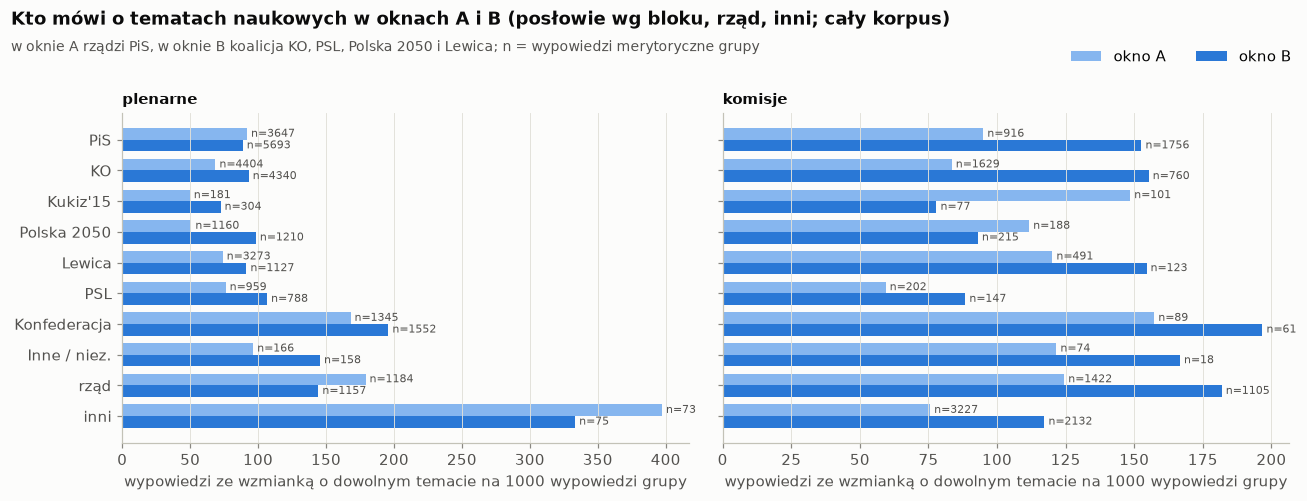

plenarne                                              \
                        A                                               
             merytoryczne wzmianka (dowolny temat) na 1000 klimat ≥ 1   
PiS                  3647                      335    91.9         53   
KO                   4404                      302    68.6         40   
Kukiz'15              181                        9    49.7          2   
Polska 2050          1160                       59    50.9         12   
Lewica               3273                      242    73.9         39   
PSL                   959                       73    76.1         12   
Konfederacja         1345                      226   168.0         49   
Inne / niez.          166                       16    96.4          0   
rząd                 1184                      212   179.1         35   
inni                   73                       29   397.3          2   

                                                                       \
                        B                                               
             merytoryczne wzmianka (dowolny temat) na 1000 klimat ≥ 1   
PiS                  5693                      505    88.7        193   
KO                   4340                      404    93.1         84   
Kukiz'15              304                       22    72.4         12   
Polska 2050          1210                      119    98.3         35   
Lewica               1127                      103    91.4         27   
PSL                   788                       84   106.6         35   
Konfederacja         1552                      304   195.9        164   
Inne / niez.          158                       23   145.6         13   
rząd                 1157                      167   144.3         51   
inni                   75                       25   333.3          3   

                  komisje                                              \
                        A                                               
             merytoryczne wzmianka (dowolny temat) na 1000 klimat ≥ 1   
PiS                   916                       87    95.0         20   
KO                   1629                      136    83.5         30   
Kukiz'15              101                       15   148.5          3   
Polska 2050           188                       21   111.7          6   
Lewica                491                       59   120.2         19   
PSL                   202                       12    59.4          7   
Konfederacja           89                       14   157.3          7   
Inne / niez.           74                        9   121.6          0   
rząd                 1422                      177   124.5         45   
inni                 3227                      244    75.6         57   

                                                                       
                        B                                              
             merytoryczne wzmianka (dowolny temat) na 1000 klimat ≥ 1  
PiS                  1756                      268   152.6        137  
KO                    760                      118   155.3         30  
Kukiz'15               77                        6    77.9          4  
Polska 2050           215                       20    93.0          6  
Lewica                123                       19   154.5          3  
PSL                   147                       13    88.4          9  
Konfederacja           61                       12   196.7          8  
Inne / niez.           18                        3   166.7          3  
rząd                 1105                      201   181.9        109  
inni                 2132                      250   117.3        117

In [23]:
grp = pd.Series(np.where(wm["rola"] == "poseł", wm["blok"], wm["rola"]), index=wm.index)
GROUPS_W = [b for b in BLOKI if b in set(grp)] + ["rząd", "inni"]
any_topic = wm[TOPICS].ge(1).any(axis=1)
bloc_tab = {}
for src in SRC:
    for k in WINDOWS:
        m = (wm["zrodlo"] == src) & (wm["okno"] == k)
        g = wm[m].groupby(grp[m])
        bloc_tab[(src, k)] = pd.DataFrame({"merytoryczne": g.size(), "wzmianka (dowolny temat)": any_topic[m].groupby(grp[m]).sum(),
                                           "na 1000": 1000 * any_topic[m].groupby(grp[m]).mean(),
                                           "klimat ≥ 1": wm.loc[m, "klimat"].ge(1).groupby(grp[m]).sum()})
bloc_tab = pd.concat(bloc_tab, axis=1).reindex(GROUPS_W).fillna(0)

yy, h = np.arange(len(GROUPS_W)), 0.38
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, src in zip(axes, SRC):
    for j, k in enumerate(WINDOWS):
        v = bloc_tab[(src, k, "na 1000")]
        ax.barh(yy + (j - 0.5) * h, v, height=h, color=WIN_KOLOR[k], label=f"okno {k}")
        for yi, (val, n) in enumerate(zip(v, bloc_tab[(src, k, "merytoryczne")])):
            ax.text(val, yi + (j - 0.5) * h, f" n={int(n)}", va="center", fontsize=7, color=INK2)
    ax.set_yticks(yy, GROUPS_W); ax.grid(axis="y", visible=False)
    ax.set_xlabel("wypowiedzi ze wzmianką o dowolnym temacie na 1000 wypowiedzi grupy")
    ax.set_title(src, fontsize=10, pad=6)
axes[0].invert_yaxis()
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper right", ncol=2, bbox_to_anchor=(0.99, 0.93))
fig.suptitle("Kto mówi o tematach naukowych w oknach A i B (posłowie wg bloku, rząd, inni; cały korpus)", x=0.01, ha="left",
             fontsize=12, fontweight="bold", color=INK)
fig.text(0.01, 0.9, "w oknie A rządzi PiS, w oknie B koalicja KO, PSL, Polska 2050 i Lewica; n = wypowiedzi merytoryczne grupy",
         fontsize=9, color=INK2)
fig.tight_layout(rect=(0, 0, 1, 0.92))
save(fig, "llm_a_19_okna_bloki"); plt.show()
bloc_tab.astype({c: int for c in bloc_tab.columns if c[2] != "na 1000"}).round(1)

* Konfederacja w obu oknach najczęściej porusza tematy ze słowników: 168 i 196 na 1000 wypowiedzi plenarnych, wobec 51–107
  u pozostałych klubów.
* PiS w opozycji (B) mówi na posiedzeniach plenarnych dużo więcej niż w rządzie (5 693 wypowiedzi wobec 3 647), ale odsetek
  wypowiedzi z tematem naukowym prawie się nie zmienia (92 i 89 na 1000). Zmienia się temat: wzmianek o klimacie jest 53 w A
  i 193 w B. W komisjach odsetek PiS rośnie (95 → 153 na 1000), a wzmianki o klimacie 20 → 137.
* Klimat w B to przede wszystkim PiS i Konfederacja: razem 357 z 617 plenarnych wzmianek (58%), w A 102 z 244 (42%).
* U przedstawicieli rządu odsetek na posiedzeniach plenarnych spada (179 → 144 na 1000), w komisjach rośnie (124 → 182).
* To dane do wątku z rozmowy zespołu (PiS w rządzie i w opozycji). Wzmianka nie mówi jednak, czy wypowiedź jest zgodna z nauką;
  do tego potrzebny jest etap B.

### 5.7 Okna A i B: język podważający naukę (marker `sceptycyzm`)

Słownik `sceptycyzm` z `01` łapie zwroty, którymi mówca dystansuje się od nauki i ekspertów („klimatyzm”, „ekoterroryzm”,
„segregacja sanitarna”, „plandemia”, „tak zwani eksperci”). Nie jest to miara sprzeczności z konsensusem, tylko podgląd języka
sporu. Liczymy go na całym korpusie i pokazujemy przykładowe zdania (wszystkie z A, 12 losowych z B).

plenarne          komisje        
                                            A        B       A       B
wypowiedzi merytoryczne               16392.0  16404.0  8342.0  6397.0
z markerem sceptycyzm                    30.0     61.0     8.0     9.0
na 1000 wypowiedzi                        1.8      3.7     1.0     1.4
w tym ze wzmianką: szczepienia            7.0      4.0     1.0     1.0
w tym ze wzmianką: covid                 15.0     11.0     1.0     1.0
w tym ze wzmianką: klimat                 2.0     37.0     0.0     4.0
w tym ze wzmianką: energia_jadrowa        0.0      2.0     0.0     0.0
w tym ze wzmianką: gmo                    0.0      0.0     0.0     0.0
w tym ze wzmianką: 5g_promieniowanie      0.0      0.0     0.0     0.0
w tym ze wzmianką: smog                   0.0      0.0     0.0     0.0
w tym ze wzmianką: in_vitro               1.0      0.0     0.0     0.0

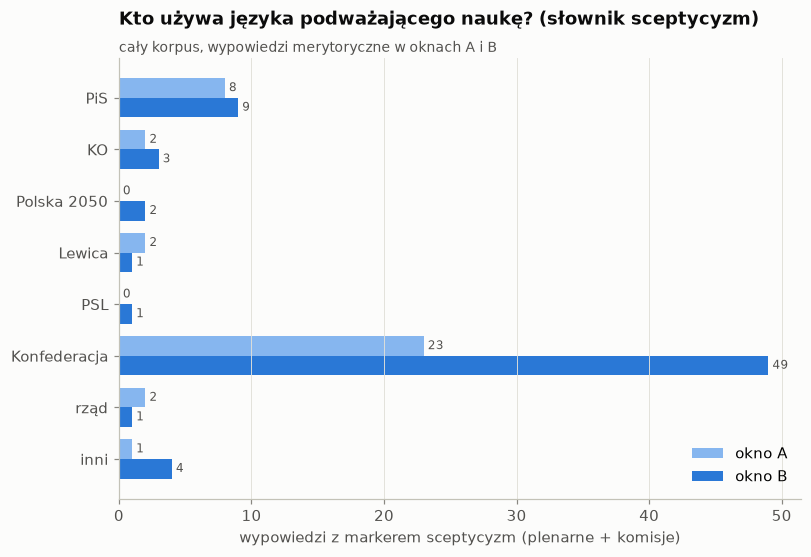

,okno,zrodlo,data,kto,zdanie
0,A,plenarne,2022-04-27,Konfederacja,"Tam przybywajcie, tam upominajcie się o dobrą pamięć dobrego lekarza, który był przeciwnikiem eksperymentowania na ludziach."
1,A,plenarne,2022-07-07,Konfederacja,"Tymczasem zaangażował się pan poza wiedzą parlamentu, poza wiedzą opinii publicznej w ustanawianie ponadnarodowego systemu segregacji sanitarnej na poziomie WHO."
2,A,plenarne,2022-07-07,Konfederacja,"…e, nielegalnie, bo poza wiedzą Wysokiej Izby i poza horyzontem, polem widzenia opinii publicznej, w podnoszenie systemu segregacji sanitarnej na wyższy poziom, poziom międzynarodowy, dokonywane p..."
3,A,plenarne,2022-07-07,Konfederacja,"Powinniśmy sprzeciwiać się ekoterrorystycznym zapędom, bo to w przyszłości może wywołać wielki głód."
4,A,komisje,2022-07-19,Lewica,"Tak jak mówię, ten temat w różnych wymiarach wracał, również eksperymentu medycznego."
5,A,komisje,2022-08-24,PiS,"Działacie jak ekoterroryści, a nie jak ekolodzy prawdziwi."
6,A,komisje,2022-08-24,KO,"Nie WWF, nie jacyś ekoterroryści, jak pan z PiS-u powiedział, tylko Wody Polskie opracowały bardzo dobry i niedrogi program."
7,A,plenarne,2022-09-28,PiS,"Jednym wpisem Radosław Sikorski, tzw. ekspert od stosunków dyplomatycznych, doprowadził do niebezpieczeństwa Polski, Europy i całego NATO."
8,A,plenarne,2022-10-06,KO,", już większość z nich dostała tego rodzaju broń długą, żeby, jak mówią, ścigać ekoterrorystów i ewentualnie uchodźców."
9,A,plenarne,2022-10-20,Konfederacja,"…go odnotować, że oto mija właśnie 2,5 roku od czasu, kiedy Wysoka Izba przyczyniła się do ustanowienia w Polsce systemu segregacji sanitarnej, systemu dyskryminacji, zastraszania, mobbingu - takż..."


In [24]:
rows = {}
for src in SRC:
    for k in WINDOWS:
        g = wm[(wm["zrodlo"] == src) & (wm["okno"] == k)]
        s = g[g["sceptycyzm"] >= 1]
        rows[(src, k)] = pd.concat([pd.Series({"wypowiedzi merytoryczne": len(g), "z markerem sceptycyzm": len(s),
                                               "na 1000 wypowiedzi": 1000 * len(s) / len(g)}),
                                    s[TOPICS].ge(1).sum().rename(lambda t: f"w tym ze wzmianką: {t}")])
display(pd.DataFrame(rows).round(1))

sc = wm[wm["sceptycyzm"] >= 1]
sc_grp = pd.crosstab(grp[sc.index], sc["okno"]).reindex(index=GROUPS_W, columns=list(WINDOWS), fill_value=0)
sc_grp = sc_grp[sc_grp.sum(axis=1) > 0]
fig, ax = plt.subplots(figsize=(8, 0.45 * len(sc_grp) + 1.6))
yy, h = np.arange(len(sc_grp)), 0.38
for j, k in enumerate(WINDOWS):
    ax.barh(yy + (j - 0.5) * h, sc_grp[k], height=h, color=WIN_KOLOR[k], label=f"okno {k}")
    for yi, v in enumerate(sc_grp[k]):
        ax.text(v, yi + (j - 0.5) * h, f" {v}", va="center", fontsize=8, color=INK2)
ax.set_yticks(yy, sc_grp.index); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.set_xlabel("wypowiedzi z markerem sceptycyzm (plenarne + komisje)")
ax.legend(loc="lower right")
ax.set_title("Kto używa języka podważającego naukę? (słownik sceptycyzm)")
subtitle(ax, "cały korpus, wypowiedzi merytoryczne w oknach A i B")
save(fig, "llm_a_20_okna_sceptycyzm"); plt.show()


def skeptic_sentence(text, width=240):
    t = " ".join(text.split())
    m = T.SKEPTIC_RE.search(t)
    if not m:
        return ""
    start = max(t.rfind(e, 0, m.start()) for e in (". ", "? ", "! "))
    start = 0 if start < 0 else start + 2
    ends = [i for i in (t.find(e, m.end()) for e in (". ", "? ", "! ")) if i >= 0]
    s = t[start:min(ends) + 1 if ends else len(t)]
    if len(s) <= width:
        return s
    a = max(m.start() - start - width // 2, 0)
    return "…" + s[a:a + width] + "…"


ex = pd.concat([sc[sc["okno"] == "A"], sc[sc["okno"] == "B"].sample(12, random_state=1)]).sort_values("data")
ex.assign(kto=grp[ex.index], data=ex["data"].dt.strftime("%Y-%m-%d"), zdanie=ex["tekst"].map(skeptic_sentence))[
    ["okno", "zrodlo", "data", "kto", "zdanie"]].reset_index(drop=True)

* Marker jest rzadki: 30 i 61 wypowiedzi plenarnych (1,8 i 3,7 na 1000), w komisjach 8 i 9.
* Zmienia się jego temat: w A to głównie COVID i szczepienia („segregacja sanitarna”, „eksperyment medyczny”), w B klimat
  (37 z 61 wypowiedzi plenarnych).
* Większość to wypowiedzi Konfederacji (23 z 38 w A, 49 z 70 w B), dalej PiS (8 i 9). Konfederacja ma w X kadencji więcej
  posłów niż w IX (18 wobec 11), co też podnosi liczby w B.
* W A, przy COVID, marker łapie też twierdzenia o faktach, które etap B mógłby sprawdzić (np. że „eksperyment medyczny”,
  czyli szczepienia, spowodował zgony). W B przykłady to głównie inwektywy wobec polityki klimatycznej („ideologia klimatyzmu”,
  „agenda ekoterrorystów”, „szamani klimatyzmu”), a twierdzenie o nauce pojawia się rzadko (pytanie o „naukowe podstawy
  do szerzenia bredni o katastrofie klimatycznej”).
* Marker łapie też cytowanie cudzych słów (poseł relacjonuje, że ktoś nazywał ludzi „ekoterrorystami”) i zwroty bez związku
  z nauką („tzw. ekspert od stosunków dyplomatycznych”).
* Wzrost markera w B nie oznacza więc automatycznie więcej twierdzeń sprzecznych z konsensusem. Etap A musi odróżniać ocenę
  polityki od twierdzenia naukowego (rodzaj `polityka` i `naukowe` w kroku 1).

### 5.8 ChatGPT: przed i po 30.11.2022

Krótko, pod sugestię prowadzącego (wpływ LLM-ów na wypowiedzi): porównanie całej próby przed i po premierze ChatGPT.
Poniżej to samo wewnątrz okna A, które premiera ChatGPT dzieli prawie dokładnie na pół.

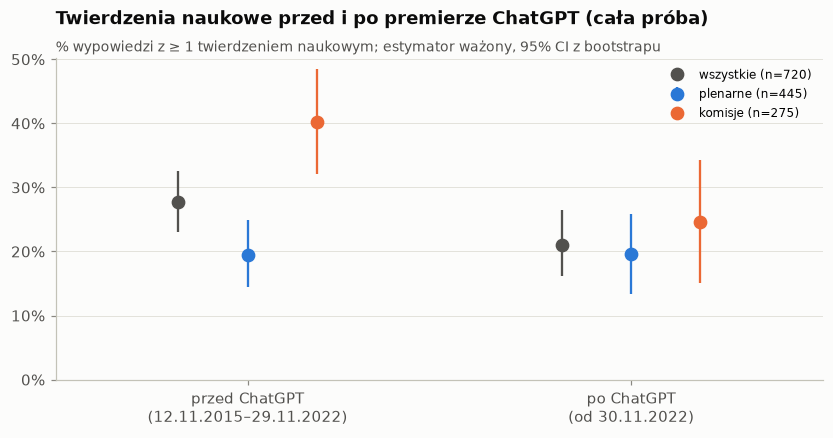

źródło,wszystkie,plenarne,komisje
n: przed ChatGPT,475,277,198
n: po ChatGPT,245,168,77
z twierdzeniem [%]: przed ChatGPT,27.7 [23.0; 32.5],19.5 [14.4; 25.0],40.2 [32.1; 48.5]
z twierdzeniem [%]: po ChatGPT,21.1 [16.1; 26.5],19.6 [13.4; 25.9],24.6 [15.1; 34.4]
różnica [pp],-6.6 [-13.8; +0.9],+0.0 [-8.2; +7.9],-15.6 [-27.7; -3.1]
twierdzenia / 100: przed ChatGPT,60.5 [47.7; 74.3],35.9 [25.0; 48.4],98.5 [73.0; 127.6]
twierdzenia / 100: po ChatGPT,38.1 [27.4; 50.3],30.6 [19.8; 42.9],55.0 [31.6; 81.0]
różnica (twierdzenia / 100),-22.4 [-39.7; -5.1],-5.3 [-21.8; +10.8],-43.5 [-80.4; -6.6]


środek okna A: 30.11.2022; premiera ChatGPT: 30.11.2022


,dni posiedzeń,wypowiedzi merytoryczne,"wzmianka, dowolny temat (na 1000)","wzmianka, klimat (na 1000)",próba LLM: n,próba LLM: z twierdzeniem [%]
1. połowa A (przed ChatGPT),48,12052,107.8,19.6,33,30.3
2. połowa A (po ChatGPT),47,12682,77.2,15.9,39,16.4


In [25]:
tab_c, pts_c = compare(df, "chatgpt", "przed", "po", CHATGPT_LABEL)
compare_plot(pts_c, ["przed", "po"], ["przed ChatGPT\n(12.11.2015–29.11.2022)", "po ChatGPT\n(od 30.11.2022)"],
             "Twierdzenia naukowe przed i po premierze ChatGPT (cała próba)", "llm_a_21_chatgpt")
display(tab_c)

mid = WINDOWS["A"][0] + (WINDOWS["A"][1] - WINDOWS["A"][0]) / 2
print(f"środek okna A: {mid:%d.%m.%Y}; premiera ChatGPT: {CHATGPT:%d.%m.%Y}")
wa = mer[mer["okno"] == "A"]
half = np.where(wa["data"] < CHATGPT, "1. połowa A (przed ChatGPT)", "2. połowa A (po ChatGPT)")
da = df[df["okno"] == "A"]
half_s = np.where(da["data"] < CHATGPT, "1. połowa A (przed ChatGPT)", "2. połowa A (po ChatGPT)")
pd.DataFrame({
    "dni posiedzeń": wa.groupby(half)["data"].nunique(),
    "wypowiedzi merytoryczne": wa.groupby(half).size(),
    "wzmianka, dowolny temat (na 1000)": 1000 * wa[TOPICS].ge(1).any(axis=1).groupby(half).mean(),
    "wzmianka, klimat (na 1000)": 1000 * wa["klimat"].ge(1).groupby(half).mean(),
    "próba LLM: n": da.groupby(half_s).size(),
    "próba LLM: z twierdzeniem [%]": 100 * R.weighted_share(da.assign(h=half_s), "h"),
}).round(1)

* W całej próbie udział wypowiedzi z twierdzeniem spada z 27,7% do 21,1% (−6,6 pp [−13,8; +0,9]), ale spadek pochodzi
  z komisji (40,2% → 24,6%). Na posiedzeniach plenarnych odsetek jest taki sam (19,5% i 19,6%).
* „Przed ChatGPT” obejmuje okres przed COVID, w którym komisje i eksperci mieli większy udział w próbie (sekcje 1 i 9.8),
  więc to porównanie miesza zmianę w czasie ze zmianą składu.
* Środek okna A to dokładnie 30.11.2022. Placebo z suplementu karty (pierwsza i druga połowa A) jest więc jednocześnie
  porównaniem przed i po ChatGPT. Jeśli przyjmiemy wątek LLM-ów, placebo przestaje być okresem „bez zdarzenia”.
* W samym oknie A wzmianek o tematach jest mniej w drugiej połowie (108 → 77 na 1000 wypowiedzi). W próbie LLM udział
  z twierdzeniem spada z 30% do 16%, ale przy n = 33 i 39 to nic nie rozstrzyga.

### 5.9 Okresy H1 (COVID): dwie jednostki, dwa źródła

Porównanie trzech okresów pierwotnej hipotezy H1 (późniejszy minus wcześniejszy) dla obu miar, osobno dla całej próby,
posiedzeń plenarnych i komisji. Zostawiamy je dla porównania z oknami A i B. To nie jest test H1: mierzymy twierdzenia
naukowe, a nie twierdzenia sprzeczne z konsensusem.

In [26]:
PAIRS = [("przed_covid", "covid"), ("przed_covid", "po_chatgpt"), ("covid", "po_chatgpt")]
subsets = {"wszystkie": df, "plenarne": df[df["zrodlo"] == "plenarne"], "komisje": df[df["zrodlo"] == "komisje"]}
rows = []
for unit, col in [("wypowiedzi z twierdzeniem [pp]", "y"), ("twierdzenia na 100 wypowiedzi", "n_twierdzen")]:
    for a, b in PAIRS:
        row = {"miara": unit, "porównanie": f"{PERIOD_LABEL[b]} − {PERIOD_LABEL[a]}"}
        for name, d in subsets.items():
            est, lo, hi = R.bootstrap_diff(d, "okres", a, b, y=col)
            row[f"{name} (n={len(d)})"] = f"{100 * est:+.1f} [{100 * lo:+.1f}; {100 * hi:+.1f}]"
        rows.append(row)
pd.DataFrame(rows).set_index(["miara", "porównanie"])

wszystkie (n=720)  \
miara                          porównanie                                       
wypowiedzi z twierdzeniem [pp] COVID − przed COVID        -12.5 [-21.2; -3.5]   
                               po ChatGPT − przed COVID   -15.0 [-22.6; -7.2]   
                               po ChatGPT − COVID          -2.5 [-11.0; +5.8]   
twierdzenia na 100 wypowiedzi  COVID − przed COVID       -36.2 [-61.6; -11.8]   
                               po ChatGPT − przed COVID  -47.0 [-68.9; -26.5]   
                               po ChatGPT − COVID         -10.8 [-32.2; +9.6]   

                                                            plenarne (n=445)  \
miara                          porównanie                                      
wypowiedzi z twierdzeniem [pp] COVID − przed COVID       -10.9 [-21.0; -0.7]   
                               po ChatGPT − przed COVID   -7.6 [-17.7; +2.1]   
                               po ChatGPT − COVID         +3.3 [-6.2; +12.5]   
twierdzenia na 100 wypowiedzi  COVID − przed COVID       -19.0 [-42.3; +3.6]   
                               po ChatGPT − przed COVID  -18.6 [-41.5; +1.2]   
                               po ChatGPT − COVID        +0.5 [-18.8; +19.1]   

                                                               komisje (n=275)  
miara                          porównanie                                       
wypowiedzi z twierdzeniem [pp] COVID − przed COVID         -11.7 [-26.7; +3.8]  
                               po ChatGPT − przed COVID    -23.2 [-36.1; -9.8]  
                               po ChatGPT − COVID          -11.4 [-26.6; +4.1]  
twierdzenia na 100 wypowiedzi  COVID − przed COVID         -51.4 [-99.4; +2.7]  
                               po ChatGPT − przed COVID  -76.5 [-118.1; -35.9]  
                               po ChatGPT − COVID         -25.1 [-72.0; +19.3]

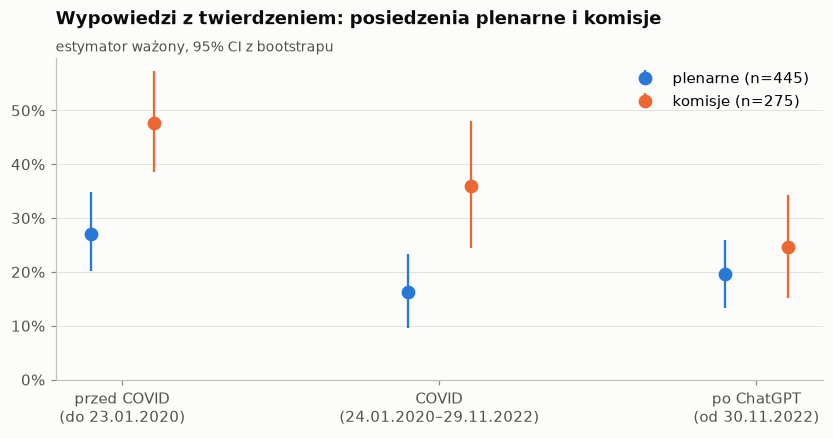

,plenarne,komisje
przed COVID,27.1 [20.2; 34.8],47.7 [38.5; 57.4]
COVID,16.3 [9.6; 23.4],36.0 [24.4; 48.0]
po ChatGPT,19.6 [13.4; 25.9],24.6 [15.1; 34.4]


In [27]:
fig, ax = plt.subplots(figsize=(9, 3.8))
src_tab = {}
for k, (name, color) in enumerate([("plenarne", ACCENT), ("komisje", SECOND)]):
    b = R.bootstrap(subsets[name], "okres").loc[PERIODS]
    src_tab[name] = fmt_ci(b)
    x = np.arange(len(PERIODS)) + (k - 0.5) * 0.2
    ax.errorbar(x, b["p"], yerr=[b["p"] - b["lo"], b["hi"] - b["p"]], fmt="o", color=color, ecolor=color,
                elinewidth=1.5, capsize=0, ms=8, label=f"{name} (n={len(subsets[name])})")
ax.set_xticks(range(len(PERIODS)), [PERIOD_TICK[p] for p in PERIODS])
ax.yaxis.set_major_formatter(PCT); ax.set_ylim(0, None); ax.grid(axis="x", visible=False)
ax.legend(loc="upper right")
ax.set_title("Wypowiedzi z twierdzeniem: posiedzenia plenarne i komisje")
subtitle(ax, "estymator ważony, 95% CI z bootstrapu")
save(fig, "llm_a_plenarne_komisje"); plt.show()
pd.DataFrame(src_tab, index=[PERIOD_LABEL[p] for p in PERIODS])

* Dla całej próby spadek po 2020 r. jest wyraźny w obu miarach: odsetek wypowiedzi z twierdzeniem −12,5 pp (COVID) i −15,0 pp
  (po ChatGPT) względem okresu przed COVID, liczba twierdzeń na 100 wypowiedzi −36 i −47; żaden z tych przedziałów nie obejmuje zera.
* Po rozbiciu na źródła różnice słabną: na posiedzeniach plenarnych istotny jest tylko spadek w okresie COVID
  (−10,9 pp [−21,0; −0,7]), a po ChatGPT odsetek wraca bliżej poziomu sprzed COVID (−7,6 pp [−17,7; +2,1]). W komisjach spadek
  narasta i jest istotny po ChatGPT (−23,2 pp).
* Komisje mają wyższy odsetek w każdym okresie (48% / 36% / 25% wobec 27% / 16% / 20% na posiedzeniach plenarnych), a ich udział
  w próbie spada z 44% do 31%. Część różnicy między okresami to więc efekt składu (więcej komisji i ekspertów przed COVID),
  a nie zmiana sposobu wypowiadania się.
* Wniosek dla planu: estymacja musi uwzględniać źródło wypowiedzi (warstwa w losowaniu albo zmienna w modelu).

### 5.10 Okresy przedwyborcze

Wstępny podgląd dla H2: wypowiedzi z 90 dni przed wyborami do Sejmu, Parlamentu Europejskiego i na prezydenta (pierwsza tura)
w zakresie danych. Wybory do Sejmu 25.10.2015 są przed początkiem danych. Służy ocenie, ile materiału przypada na okna kampanii,
nie testowaniu H2. Na końcu: jaka część okna B przypada na kampanie przed wyborami samorządowymi i do PE w 2024 r.
(zdarzenia wymienione w suplemencie karty).

In [28]:
ELECTIONS = [("PE", "2019-05-26"), ("Sejm", "2019-10-13"), ("prezydent", "2020-06-28"),
             ("Sejm", "2023-10-15"), ("PE", "2024-06-09"), ("prezydent", "2025-05-18")]
camp = pd.Series(False, index=df.index)
for _, d in ELECTIONS:
    d = pd.Timestamp(d)
    camp |= df["data"].between(d - pd.Timedelta(days=90), d - pd.Timedelta(days=1))
df["kampania"] = np.where(camp, "90 dni przed wyborami", "pozostały czas")
b1, b2 = R.bootstrap(df, "kampania"), R.bootstrap(df, "kampania", y="n_twierdzen")
fb = filt[filt["okno"] == "B"]
for name, d in [("samorządowymi 7.04.2024", "2024-04-07"), ("do PE 9.06.2024", "2024-06-09")]:
    d = pd.Timestamp(d)
    print(f"okno B: {fb['data'].between(d - pd.Timedelta(days=90), d - pd.Timedelta(days=1)).mean():.0%} wypowiedzi z filtra "
          f"przypada na 90 dni przed wyborami {name}")
pd.DataFrame({"n (próba)": b1["n"], "z twierdzeniem [%]": fmt_ci(b1), "twierdzenia / 100 wyp.": fmt_ci(b2),
              "szac. twierdzenia w populacji": R.weighted_total(df, "kampania", y="n_twierdzen").round().astype(int)})

okno B: 20% wypowiedzi z filtra przypada na 90 dni przed wyborami samorządowymi 7.04.2024
okno B: 18% wypowiedzi z filtra przypada na 90 dni przed wyborami do PE 9.06.2024


,n (próba),z twierdzeniem [%],twierdzenia / 100 wyp.,szac. twierdzenia w populacji
kampania,,,,
90 dni przed wyborami,90,27.7 [18.3; 38.5],61.9 [36.2; 92.8],1562
pozostały czas,630,24.9 [20.9; 28.7],50.8 [41.3; 61.6],8589


* Na okna 90 dni przed wyborami przypada 90 wypowiedzi z próby (12,5%) i ok. 1,6 tys. szacowanych twierdzeń w populacji. Odsetek
  wypowiedzi z twierdzeniem nie różni się wyraźnie od reszty czasu (27,7% wobec 24,9%, przedziały się nakładają). Jeśli twierdzenia
  sprzeczne z konsensusem stanowią kilka procent, w oknach kampanii będzie ich kilkadziesiąt, więc test H2 wymaga pomiaru na całej
  populacji, a nie na próbie (10.5).
* W oknie B 20% wypowiedzi z filtra przypada na 90 dni przed wyborami samorządowymi (7.04.2024), a 18% na 90 dni przed
  wyborami do PE (9.06.2024); okresy te częściowo się pokrywają. Kampanie to więc duża część okna B, a w oknie A ich nie ma.

## 6. Kto mówi

### 6.1 Rola mówcy i miejsce wypowiedzi

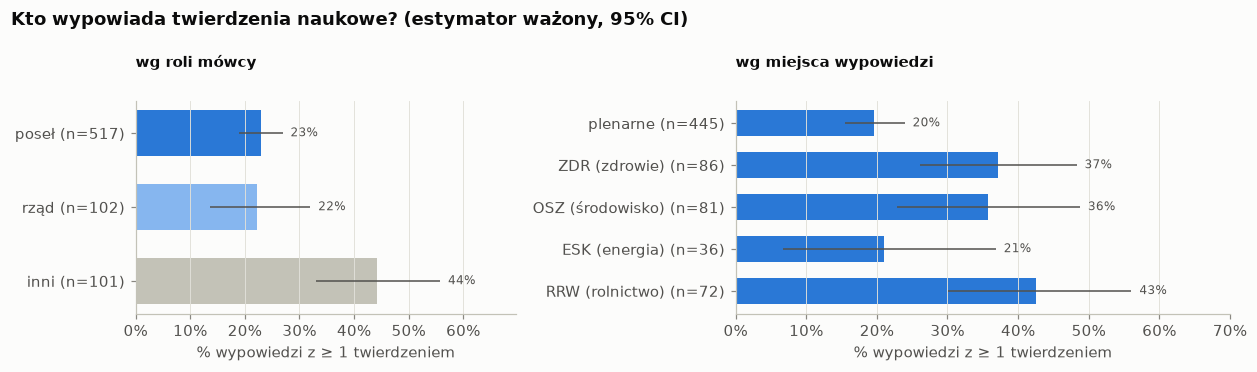

,% wypowiedzi w próbie,% twierdzeń
rola,,
poseł,71.8,49.0
rząd,14.2,13.2
inni,14.0,37.9


In [29]:
b_rola = R.bootstrap(df, "rola").reindex(["poseł", "rząd", "inni"])
b_grem = R.bootstrap(df, "gremium").reindex(list(GREMIA))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 3.4), gridspec_kw={"width_ratios": [1, 1.3]})
hbar_ci(a1, b_rola, [ROLE_KOLOR[r] for r in b_rola.index], [f"{r} (n={n})" for r, n in zip(b_rola.index, b_rola["n"])])
hbar_ci(a2, b_grem, ACCENT, [f"{GREMIA[g]} (n={n})" for g, n in zip(b_grem.index, b_grem["n"])])
a1.set_title("wg roli mówcy", fontsize=10); a2.set_title("wg miejsca wypowiedzi", fontsize=10)
for ax in (a1, a2):
    ax.set_xlabel("% wypowiedzi z ≥ 1 twierdzeniem")
fig.suptitle("Kto wypowiada twierdzenia naukowe? (estymator ważony, 95% CI)", x=0.01, ha="left", fontsize=12, fontweight="bold", color=INK)
fig.tight_layout()
save(fig, "llm_a_09_rola_miejsce"); plt.show()
role_share = pd.DataFrame({"% wypowiedzi w próbie": df["rola"].value_counts(normalize=True) * 100,
                           "% twierdzeń": cl["rola"].value_counts(normalize=True) * 100}).reindex(["poseł", "rząd", "inni"])
role_share.round(1)

Eksperci i goście (rola „inni”) to 14% wypowiedzi w próbie, ale 38% twierdzeń; twierdzenie ma 44% ich wypowiedzi, wobec 23%
u posłów i 22% u przedstawicieli rządu. Na posiedzeniach plenarnych odsetek wynosi 20%, w komisjach 21–43%. Hipotezy dotyczą polityków, więc decyzja
o tym, kogo liczymy w mianowniku (sami posłowie / posłowie i rząd / wszyscy), wpłynie na wynik (sekcja 10.3).

### 6.2 Bloki polityczne (tylko posłowie)

Kolor oznacza zawsze ten sam blok (paleta z `01`). Liczności bloków w próbie są małe, przedziały szerokie.

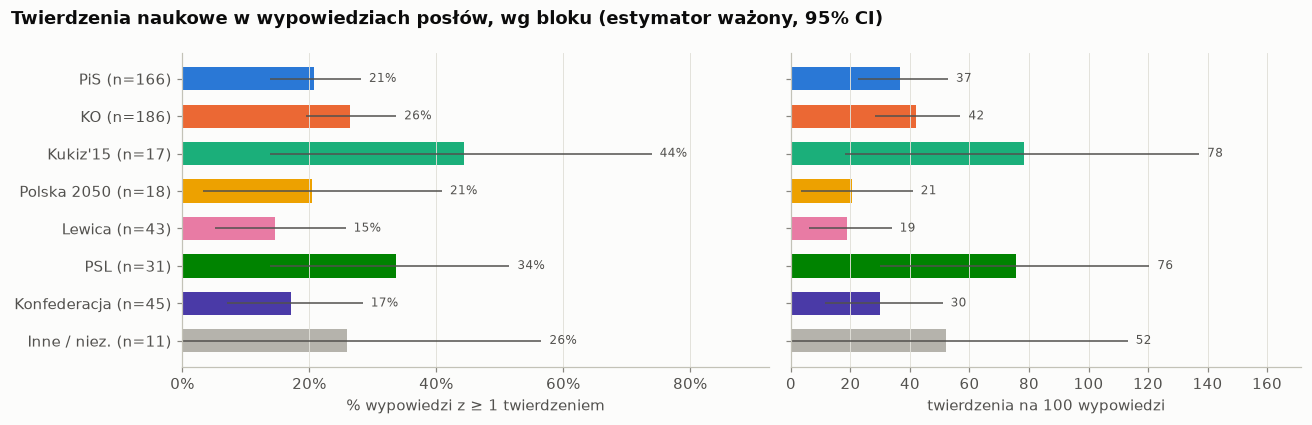

,n,z twierdzeniem [%],twierdzenia / 100 wyp.
blok,,,
PiS,166,20.8 [13.9; 28.2],36.8 [22.7; 52.8]
KO,186,26.4 [19.4; 33.7],42.0 [28.4; 57.0]
Kukiz'15,17,44.4 [13.9; 74.0],78.4 [18.2; 137.2]
Polska 2050,18,20.5 [3.3; 40.9],20.5 [3.3; 40.9]
Lewica,43,14.6 [5.1; 25.7],18.7 [6.1; 33.9]
PSL,31,33.6 [13.9; 51.5],75.5 [29.8; 120.5]
Konfederacja,45,17.1 [7.1; 28.5],29.8 [11.4; 51.0]
Inne / niez.,11,26.0 [0.0; 56.6],51.9 [0.0; 113.2]


In [30]:
pos = df[df["rola"] == "poseł"]
blocs = [b for b in BLOKI if b in set(pos["blok"])]
b1 = R.bootstrap(pos, "blok").reindex(blocs)
b2 = R.bootstrap(pos, "blok", y="n_twierdzen").reindex(blocs)
colors = [BLOK_KOLOR[b] for b in blocs]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.9), gridspec_kw={"width_ratios": [1.15, 1]})
hbar_ci(a1, b1, colors, [f"{b} (n={n})" for b, n in zip(blocs, b1["n"])])
hbar_ci(a2, b2, colors, pct=False)
a1.set_xlabel("% wypowiedzi z ≥ 1 twierdzeniem"); a2.set_xlabel("twierdzenia na 100 wypowiedzi")
fig.suptitle("Twierdzenia naukowe w wypowiedziach posłów, wg bloku (estymator ważony, 95% CI)", x=0.01, ha="left",
             fontsize=12, fontweight="bold", color=INK)
fig.tight_layout()
save(fig, "llm_a_10_bloki"); plt.show()
pd.DataFrame({"n": b1["n"], "z twierdzeniem [%]": fmt_ci(b1), "twierdzenia / 100 wyp.": fmt_ci(b2)})

Wśród posłów najwyższe odsetki mają Kukiz'15 i PSL, ale przy n = 17 i 31. Wśród dużych bloków KO ma 26%, PiS 21%,
Konfederacja 17%, Lewica 15%; przedziały w większości się nakładają. Częstość twierdzeń naukowych nie mówi nic o ich trafności:
blok, który rzadko formułuje twierdzenia naukowe, może mieć zarówno niski, jak i wysoki odsetek twierdzeń fałszywych.
Liczności są za małe, żeby dzielić bloki dalej na okresy, dlatego bloki w oknach A i B opisujemy na całym korpusie
(sekcja 5.6).

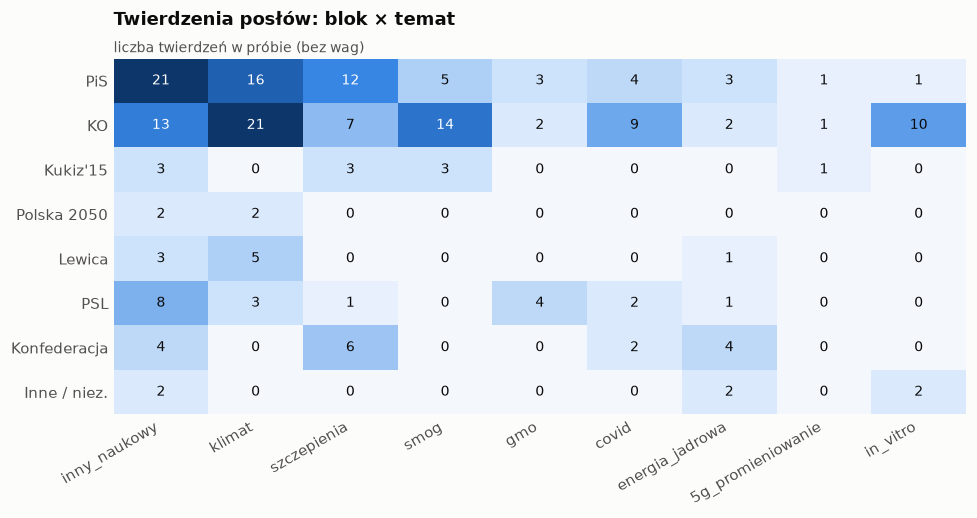

In [31]:
cp = cl[cl["rola"] == "poseł"]
bt = pd.crosstab(cp["blok"], cp["temat"]).reindex(index=blocs, columns=[t for t in topics_tab.index], fill_value=0)
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.imshow(bt.values, cmap=SEQ, aspect="auto", vmin=0)
ax.set_xticks(range(bt.shape[1]), bt.columns, rotation=30, ha="right"); ax.set_yticks(range(bt.shape[0]), bt.index)
ax.grid(False); ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
for i in range(bt.shape[0]):
    for j in range(bt.shape[1]):
        v = bt.values[i, j]
        ax.text(j, i, f"{v}", ha="center", va="center", fontsize=9, color="white" if v > bt.values.max() * 0.55 else INK)
ax.set_title("Twierdzenia posłów: blok × temat")
subtitle(ax, "liczba twierdzeń w próbie (bez wag)")
save(fig, "llm_a_11_bloki_tematy"); plt.show()

### 6.3 Mówcy z największą liczbą twierdzeń w próbie

In [32]:
spk = (df.groupby("mowca").agg(rola=("rola", "first"), miejsce=("gremium", lambda s: "/".join(sorted(set(s)))),
                               wypowiedzi=("y", "size"), twierdzenia=("n_twierdzen", "sum"))
       .sort_values("twierdzenia", ascending=False).head(10))
spk.index = spk.index.str.slice(0, 90)
spk

,rola,miejsce,wypowiedzi,twierdzenia
mowca,,,,
Kierownik Zakładu Chorób Świń Państwowego Instytutu Weterynaryjnego – Państwowego Instytut,inni,RRW,1,15
Zastępca dyrektora Departamentu Monitoringu Środowiska Głównego Inspektoratu Ochrony Środo,inni,OSZ,1,8
Zastępca prezesa PGW Wody Polskie Joanna Kopczyńska,inni,OSZ,1,7
Pracownik naukowy Uniwersytetu Przyrodniczego w Poznaniu i Instytutu Genetyki Roślin Polsk,inni,RRW,1,7
Jarosław Pinkas,rząd,plenarne,2,7
Ewa Lieder,poseł,plenarne,6,7
Podsekretarz stanu w MKiŚ Piotr Dziadzio,rząd,OSZ,1,7
Kierownik Zakładu Biologicznych Metod IOR-PIB prof. dr hab. Marek Tomalak,inni,RRW,1,6
Kierownik Zakładu Fizjologii Pracy i Ergonomii Instytutu Medycyny Pracy prof. Alicja Bortk,inni,OSZ,1,6


Na liście dominują goście komisji (Państwowy Instytut Weterynaryjny, GIOŚ, Wody Polskie, Instytut Ochrony Roślin, Instytut
Medycyny Pracy), a nie posłowie. Jedna rozbudowana wypowiedź eksperta daje kilka do kilkunastu twierdzeń.

## 7. Słowniki a LLM

Czy trafienia słowników (podstawa analizy w `01`) przewidują obecność twierdzeń naukowych? Odsetki bez wag.

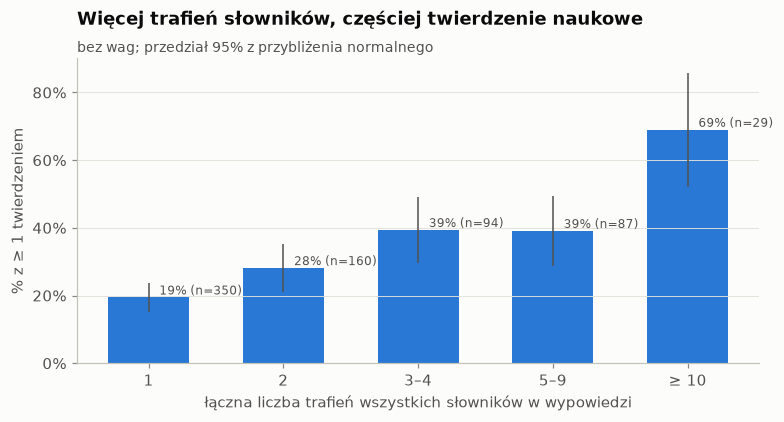

,n,z twierdzeniem [%],twierdzenia / 100 wyp.
trafienie słownika tematu (≥ 1),594.0,26.8,55.9
wypowiedź tematyczna z 01 (≥ 3 trafienia tematu),179.0,43.0,104.5
"tylko marker nauka / sceptycyzm, bez tematu",126.0,35.7,86.5
marker nauka > 0,161.0,43.5,116.1
marker nauka = 0,559.0,24.0,45.4
marker sceptycyzm > 0,8.0,37.5,62.5


In [33]:
df["trafienia"] = pd.cut(df[sampling.HIT_COLS].sum(axis=1), [1, 2, 3, 5, 10, np.inf],
                         labels=["1", "2", "3–4", "5–9", "≥ 10"], right=False)
hits = df.groupby("trafienia", observed=True).agg(n=("y", "size"), p=("y", "mean"))
se = np.sqrt(hits["p"] * (1 - hits["p"]) / hits["n"])
fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(hits))
ax.bar(x, hits["p"], color=ACCENT, width=0.6)
ax.errorbar(x, hits["p"], yerr=1.96 * se, fmt="none", ecolor=INK2, elinewidth=1, capsize=0)
for xi, (p, n) in enumerate(zip(hits["p"], hits["n"])):
    ax.text(xi + 0.08, p, f"{p:.0%} (n={n})", fontsize=8, color=INK2, va="bottom")
ax.set_xticks(x, hits.index); ax.yaxis.set_major_formatter(PCT); ax.grid(axis="x", visible=False)
ax.set_xlabel("łączna liczba trafień wszystkich słowników w wypowiedzi"); ax.set_ylabel("% z ≥ 1 twierdzeniem")
ax.set_title("Więcej trafień słowników, częściej twierdzenie naukowe")
subtitle(ax, "bez wag; przedział 95% z przybliżenia normalnego")
save(fig, "llm_a_12_regex_vs_llm"); plt.show()

topic_hit = df[TOPICS].gt(0).any(axis=1)
groups = {
    "trafienie słownika tematu (≥ 1)": topic_hit,
    "wypowiedź tematyczna z 01 (≥ 3 trafienia tematu)": df[TOPICS].ge(T.PROG).any(axis=1),
    "tylko marker nauka / sceptycyzm, bez tematu": ~topic_hit,
    "marker nauka > 0": df["nauka"].gt(0),
    "marker nauka = 0": df["nauka"].eq(0),
    "marker sceptycyzm > 0": df["sceptycyzm"].gt(0),
}
pd.DataFrame({k: {"n": int(m.sum()), "z twierdzeniem [%]": 100 * df.loc[m, "y"].mean(),
                  "twierdzenia / 100 wyp.": 100 * df.loc[m, "n_twierdzen"].mean()} for k, m in groups.items()}).T.round(1)

* Liczba trafień przewiduje twierdzenie tylko umiarkowanie: przy jednym trafieniu twierdzenie ma 19% wypowiedzi, przy co najmniej
  dziesięciu 69%. Nawet „wypowiedź tematyczna” z `01` (≥ 3 trafienia tematu) zawiera twierdzenie naukowe tylko w 43% przypadków.
* Marker `nauka` podnosi odsetek z 24% do 44%. Wypowiedzi, które przeszły filtr wyłącznie dzięki markerom `nauka` / `sceptycyzm`,
  mają twierdzenie częściej niż te ze słownikiem tematu (36% wobec 27%), więc markery są użyteczną częścią filtra.
* Marker `sceptycyzm` wystąpił w próbie tylko w 8 wypowiedziach. Losowanie bez warstwy po markerze nie da materiału do analizy
  języka podważającego naukę.
* Słowniki mierzą temat rozmowy, a nie obecność twierdzenia. Jako filtr wstępny przepuszczają dużo wypowiedzi bez twierdzeń,
  a ich czułości (ile twierdzeń jest poza filtrem) jeszcze nie znamy (wymagałoby to anotacji wypowiedzi spoza filtra).

## 8. Atrybucja (cytaty)

Czy mówca twierdzi sam, czy przytacza cudze twierdzenie (z aprobatą lub w polemice). W polemice etap B oceni stanowisko mówcy.

In [34]:
display(cl["atrybucja"].value_counts().to_frame("twierdzenia"))
cl.loc[cl["atrybucja"] != "wlasne", ["rok", "atrybucja", "cytat", "twierdzenie"]]

,twierdzenia
atrybucja,
wlasne,424
cytat_zgoda,14
cytat_polemika,3


,rok,atrybucja,cytat,twierdzenie
37,2015,cytat_zgoda,Poinformowano mnie o zmianach refundacyjnych utrudniających dostęp dzieci po transplantacjach do leku - i tu jego nazwa. To niepokojące i z medycznego punktu widzenia w najlepiej pojętym interesie...,"Zmiany refundacyjne utrudniają dostęp dzieci po transplantacjach do niezbędnych leków, co jest niebezpieczne z medycznego punktu widzenia."
38,2015,cytat_zgoda,"Podanie, co wymusi sytuacja finansowa, niebadanego nigdy w tej grupie wiekowej kolejnego leku odtwórczego dzieciom po transplantacji, utrzymywanym długotrwale bez steroidów - uwaga, cytat - jest o...",Stosowanie nieprzebadanych leków u dzieci po transplantacjach wiąże się z ryzykiem odrzucenia przeszczepu.
56,2016,cytat_zgoda,"Dwustu specjalistów z 39 krajów świata alarmuje, że winne są temu urządzenia bezprzewodowe będące źródłem promieniowania elektromagnetycznego.","Dwustu specjalistów z 39 krajów twierdzi, że urządzenia bezprzewodowe emitujące promieniowanie elektromagnetyczne są przyczyną wzrostu nowotworów mózgu."
69,2016,cytat_zgoda,"Proszę zapoznać się z opinią Światowej Organizacji Zdrowia. Jest taka organizacja. Nie wiem, czy pani o tym wie, ale jest Światowa Organizacja Zdrowia, która uznaje in vitro za metodę leczenia.",Światowa Organizacja Zdrowia uznaje in vitro za metodę leczenia.
74,2016,cytat_zgoda,"Gdyby przyszło mi zrobić tylko jedną rzecz jako ministrowi zdrowia, to ta jedna rzecz to istotne ograniczenie palenia tytoniu. Z tego będzie największy profit zdrowotny.",Ograniczenie palenia tytoniu przyniesie największe korzyści zdrowotne.
83,2016,cytat_zgoda,"naukowcy projektowali rozwój tego sektora, to twierdzili, że powinniśmy osiągnąć mniej więcej 500 tys. ha zasiewu, żeby mniej więcej w połowie zabezpieczyć nasze potrzeby białkowe.","Naukowcy twierdzili, że dla zabezpieczenia połowy potrzeb białkowych Polski potrzeba około 500 tys. ha zasiewów roślin wysokobiałkowych."
183,2018,cytat_polemika,"Proponuję, żeby jeszcze przygotować inicjatywę przeciwko teorii Kopernika, bo jak widać, przecież Słońce krąży wokół Ziemi","Teoria geocentryczna (Słońce krąży wokół Ziemi) jest fałszywa, a teoria heliocentryczna Kopernika jest prawdziwa."
184,2018,cytat_polemika,"przeciwko transfuzji krwi, teorii ewolucji, przeciwko kolei żelaznej, która była określona jako dzieło szatana i musi być potępiona, przeciwko oświetleniu ulic w nocy, dlatego że jest to wbrew nat...","Teoria ewolucji, transfuzja krwi, kolej żelazna i oświetlenie ulic są zgodne z nauką i nie są sprzeczne z naturą."
257,2019,cytat_zgoda,"Eksperci Europejskiego Urzędu ds. Bezpieczeństwa Żywności mówią, że nieprawidłowo wykonywany, nieracjonalny odstrzał dzików będzie przyczyniał się do rozprzestrzeniania epidemii.","Nieracjonalny odstrzał dzików zwiększa ryzyko rozprzestrzeniania się ASF, co potwierdzają eksperci EFSA."
258,2019,cytat_zgoda,"EFSA, główny lekarz weterynarii nakazali niewykonywanie tam polowań zbiorowych.",EFSA i główny lekarz weterynarii zalecają unikanie polowań zbiorowych w strefach zagrożonych ASF.


424 z 441 twierdzeń to twierdzenia własne mówcy. Cytatów z aprobatą jest 14, w polemice 3. Polemika to tu m.in. ironia
(„przecież Słońce krąży wokół Ziemi”), czyli przypadek, w którym etap B musi ocenić stanowisko mówcy, a nie dosłowne zdanie.
Wśród cytatów z aprobatą są odwołania do instytucji (EMA, WHO, EFSA, sekretarz generalny ONZ), ale też, w 2026 r., przytoczone
z aprobatą twierdzenia o szczepionkach mRNA i „udowodnionej” szkodliwości szczepień: kandydaci na twierdzenia sprzeczne
z konsensusem, które atrybucja `cytat_zgoda` pozwala przypisać mówcy.

## 9. Źródła błędu i problemy

Bez ręcznej anotacji nie zmierzymy precyzji ani czułości, ale część błędów widać w samych danych. Najważniejsze pytanie dla porównań w czasie
(okna A i B, okresy H1): czy błąd jest **taki sam w porównywanych okresach**. Błąd różnicowy może sam wytworzyć albo ukryć różnicę między okresami.
Sekcje 9.1–9.3 opisują problemy znalezione w pierwszym przebiegu i efekt ich naprawy, 9.4–9.8 problemy, które zostają.

### 9.1 Przepełnienie kontekstu w pierwszym przebiegu

Prompt kroku 1 (instrukcje i przykłady), wypowiedź i odpowiedź modelu muszą się zmieścić w kontekście. W pierwszym przebiegu
kontekst miał 8192 tokeny i przy dłuższych wypowiedziach się nie mieścił, a Ollama nie zgłaszała błędu. Były dwa warianty:

1. **Obcięte wejście** (flaga `przepelnienie`): sam prompt był dłuższy niż 8192 tokeny. Ollama skracała go do 4098 tokenów,
   zostawiając 4 pierwsze tokeny i **koniec** tekstu. Wypadał cały prompt systemowy i początek wypowiedzi; model dostawał fragment
   wypowiedzi bez żadnych instrukcji, a schemat JSON wymuszał tylko format odpowiedzi. W danych: `tokeny_we = 4098`.
2. **Przesunięcie kontekstu pod koniec odpowiedzi** (flaga `przesuniecie`): prompt się mieścił, ale prompt + odpowiedź już nie.
   llama-server (silnik Ollamy) usuwał wtedy najstarsze tokeny, czyli instrukcje, i generował dalej. Dotyczyło to tylko końcówki
   odpowiedzi (ostatnich kandydatów). W danych: `tokeny_we + tokeny_wy > 8192`.

Log Ollamy z pierwszego przebiegu:

```
level=WARN source=llama_server.go:320 msg="truncating input prompt" limit=4098 prompt=9764 keep=4 new=4098
slot operator(): id 0 | task 18 | slot context shift, n_keep = 4, n_left = 8187, n_discard = 4093
```

prompt bazowy ≈ 4698 tokenów + 2.92 tokenu na słowo wypowiedzi; przy 8192 tokenach mieściło się ok. 1195 słów
obcięte wejście: 66 wypowiedzi (9.2%), od 1155 słów; przesunięcie kontekstu: 26 (709–1282 słów)


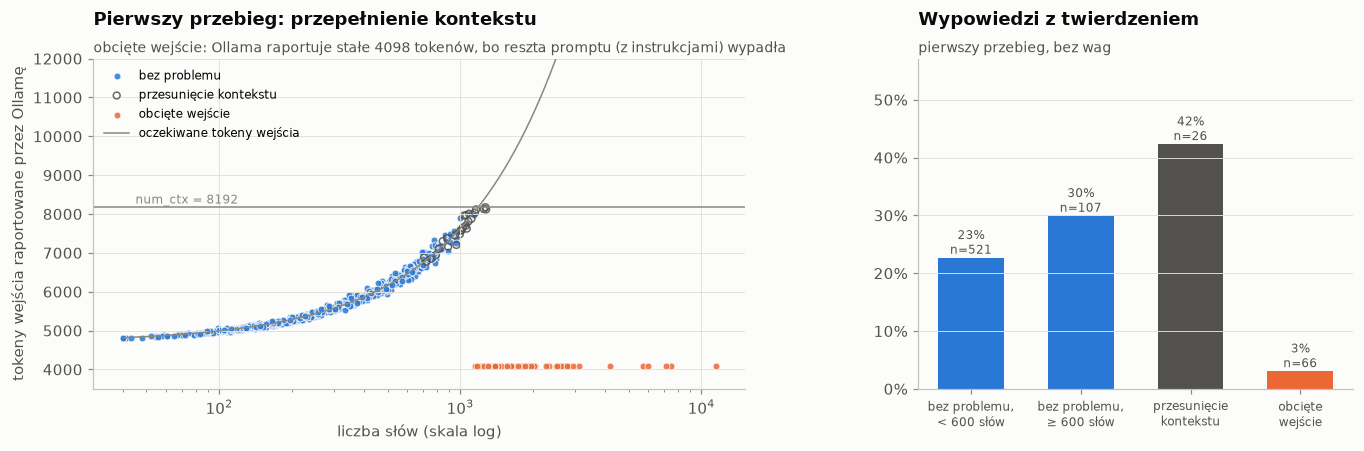

obcięte wejście [%]  przesunięcie kontekstu [%]
okno   A                            6.9                         2.8
       B                           11.5                         4.6
okres  przed COVID                 11.1                         4.3
       COVID                        8.2                         3.5
       po ChatGPT                   7.3                         2.9
źródło komisje                     11.3                         5.1
       plenarne                     7.9                         2.7

**Rodzaje kandydatów w pierwszym przebiegu (% wiersza)**

rodzaj,budzet,inne,naukowe,opinia,polityka,prawo,statystyka
row_0,,,,,,,
bez problemu,2.4,7.4,43.9,12.6,19.2,4.5,9.9
obcięte wejście,1.3,38.6,2.9,7.0,32.9,15.1,2.1
przesunięcie kontekstu,2.4,12.6,49.1,2.4,11.4,4.8,17.4


,wypowiedz_id,rodzaj,cytat
1014,9_ZDR_19_21,inne,Platforma Obywatelska za swój największy sukces w walce ze świńską grypą uznała nieprzystąpienie do unijnych zakupów szczepionek.
744,8_74_2018-12-12_4,polityka,"Bardzo dziękuję panu ministrowi Błaszczakowi, ale też jego poprzednikowi, za umacnianie polskiej armii. Dziękuję panu ministrowi Macierewiczowi za to, co zrobił wcześniej. To naprawdę wielkie zasł..."
55,8_3_2015-12-02_68,prawo,"ustawa, którą mam zaszczyt prezentować, wykonuje wyrok Trybunału Konstytucyjnego."
17,8_1_2015-11-18_3,polityka,"W ostatnich tygodniach Platforma była pytana, jaką będziemy opozycją. To było pytanie, które zadawali eksperci, dziennikarze i ludzie na ulicach. Czy będziemy taką totalną opozycją, jaką wy byliśc..."
929,8_86_2019-09-11_209,inne,Rzecznik Praw Obywatelskich Adam Bodnar
987,9_9_2020-04-06_5,polityka,"Relatywnie niska liczba zachorowań nie powoduje, że nasza uwaga jest dzisiaj uśpiona, bo zdajemy sobie sprawę z tego, że pandemia może przyspieszyć, może się wypłaszczyć."


In [35]:
f_fine = ~first["przepelnienie"] & ~first["przesuniecie"]
slope, intercept = np.polyfit(first.loc[~first["przepelnienie"], "liczba_slow"], first.loc[~first["przepelnienie"], "tokeny_we"], 1)
print(f"prompt bazowy ≈ {intercept:.0f} tokenów + {slope:.2f} tokenu na słowo wypowiedzi; "
      f"przy 8192 tokenach mieściło się ok. {(8192 - intercept) / slope:.0f} słów")
print(f"obcięte wejście: {first['przepelnienie'].sum()} wypowiedzi ({first['przepelnienie'].mean():.1%}), "
      f"od {first.loc[first['przepelnienie'], 'liczba_slow'].min()} słów; przesunięcie kontekstu: {first['przesuniecie'].sum()} "
      f"({first.loc[first['przesuniecie'], 'liczba_slow'].min()}–{first.loc[first['przesuniecie'], 'liczba_slow'].max()} słów)")

GROUPS = ["bez problemu, < 600 słów", "bez problemu, ≥ 600 słów", "przesunięcie kontekstu", "obcięte wejście"]
grp = pd.Series(np.select([first["przepelnienie"], first["przesuniecie"], first["liczba_slow"] >= 600], GROUPS[:0:-1], GROUPS[0]),
                index=first.index)
g = first.assign(g=grp).groupby("g").agg(n=("y", "size"), p=("y", "mean")).loc[GROUPS]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4.2), gridspec_kw={"width_ratios": [1.5, 1]})
for mask, color, face, lab in [(f_fine, ACCENT, ACCENT, "bez problemu"), (first["przesuniecie"], INK2, "none", "przesunięcie kontekstu"),
                               (first["przepelnienie"], SECOND, SECOND, "obcięte wejście")]:
    a1.scatter(first.loc[mask, "liczba_slow"], first.loc[mask, "tokeny_we"], s=20, facecolor=face,
               edgecolor=color if face == "none" else SURF, linewidth=1 if face == "none" else 0.6, alpha=0.85, label=lab)
xs = np.linspace(40, 2500, 200)
a1.plot(xs, intercept + slope * xs, color=MUTED, lw=1, label="oczekiwane tokeny wejścia")
a1.axhline(8192, color=MUTED, lw=1)
a1.text(45, 8192, "num_ctx = 8192", fontsize=8, color=MUTED, va="bottom")
a1.set_xscale("log"); a1.set_ylim(3500, 12000)
a1.set_xlabel("liczba słów (skala log)"); a1.set_ylabel("tokeny wejścia raportowane przez Ollamę")
a1.legend(loc="upper left", fontsize=8)
a1.set_title("Pierwszy przebieg: przepełnienie kontekstu")
subtitle(a1, "obcięte wejście: Ollama raportuje stałe 4098 tokenów, bo reszta promptu (z instrukcjami) wypadła")
x = np.arange(len(g))
a2.bar(x, g["p"], color=[ACCENT, ACCENT, INK2, SECOND], width=0.6)
for xi, (p, n) in enumerate(zip(g["p"], g["n"])):
    a2.text(xi, p, f"{p:.0%}\nn={n}", ha="center", va="bottom", fontsize=8, color=INK2)
a2.set_xticks(x, [s.replace(", ", ",\n").replace(" kontekstu", "\nkontekstu").replace(" wejście", "\nwejście") for s in g.index], fontsize=8)
a2.yaxis.set_major_formatter(PCT); a2.set_ylim(0, g["p"].max() * 1.35); a2.grid(axis="x", visible=False)
a2.set_title("Wypowiedzi z twierdzeniem")
subtitle(a2, "pierwszy przebieg, bez wag")
fig.tight_layout()
save(fig, "llm_a_13_przepelnienie"); plt.show()

display(pd.concat({
    "okno": first.groupby("okno")[["przepelnienie", "przesuniecie"]].mean().loc[list(WINDOWS)],
    "okres": first.groupby("okres")[["przepelnienie", "przesuniecie"]].mean().loc[PERIODS].rename(index=PERIOD_LABEL),
    "źródło": first.groupby("zrodlo")[["przepelnienie", "przesuniecie"]].mean(),
}).mul(100).round(1).rename(columns={"przepelnienie": "obcięte wejście [%]", "przesuniecie": "przesunięcie kontekstu [%]"}))
f_cand = R.candidates(first)
status3 = np.select([f_cand["przepelnienie"], f_cand["przesuniecie"]], ["obcięte wejście", "przesunięcie kontekstu"], "bez problemu")
display(Markdown("**Rodzaje kandydatów w pierwszym przebiegu (% wiersza)**"),
        pd.crosstab(status3, f_cand["rodzaj"], normalize="index").mul(100).round(1))
f_cand.loc[f_cand["przepelnienie"], ["wypowiedz_id", "rodzaj", "cytat"]].sample(6, random_state=2)

* **Obcięte wejście było krytyczne.** Dotyczyło 66 wypowiedzi (9%), wszystkich od ok. 1150 słów, w tym 15 ucinanych do 2500 słów.
  Tylko 3% ich kandydatów to zdania „naukowe” (wobec 44%), za to 39% to „inne” i 33% „polityka”, np. „Rzecznik Praw Obywatelskich
  Adam Bodnar” jako kandydat. Twierdzenie miało 3% tych wypowiedzi, wobec 30% dla długich wypowiedzi bez problemu.
* **Przesunięcie kontekstu było mniej groźne.** 26 wypowiedzi (709–1282 słów); instrukcje wypadały dopiero przy ostatnich
  kandydatach, a rozkład rodzajów był podobny do reszty.
* **Błąd był różnicowy.** Obcięte wejście dotyczyło 11% wypowiedzi przed COVID, 8% w okresie COVID i 7% po ChatGPT, w oknach 7% (A) i 11% (B), oraz częściej
  komisji niż posiedzeń plenarnych, więc zaniżało przede wszystkim okres przed COVID.
* Oba błędy były ciche: odpowiedź miała poprawny JSON i skrypt nie zgłaszał błędu. Wykryliśmy je dopiero przez analizę długości
  wypowiedzi i liczby tokenów.

### 9.2 Naprawa i jej efekt

* Kontekst zwiększony do 16 384 tokenów dla obu kroków (model z takim kontekstem mieści się w 12 GB VRAM). Zmieści się prompt
  z wypowiedzią do 2500 słów i odpowiedzią do 4096 tokenów.
* Skrypt porównuje liczbę tokenów raportowaną przez Ollamę z rozmiarem kontekstu i oznacza każde przepełnienie jako błąd,
  żeby problem nie wrócił po cichu.
* Ponownie sklasyfikowaliśmy 119 wypowiedzi: z obciętym wejściem, z przesunięciem kontekstu albo z pełnym limitem kandydatów (9.3).

Porównanie tych 119 wypowiedzi przed i po naprawie (ten sam model i prompt):

,pierwszy przebieg,po naprawie
wypowiedzi,119.0,119.0
z twierdzeniem [%],21.8,46.2
twierdzenia,60.0,160.0
kandydaci na wypowiedź,6.4,6.8
kandydaci „naukowe” [%],20.4,46.0
obcięte wejście,66.0,0.0
przesunięcie kontekstu,26.0,0.0


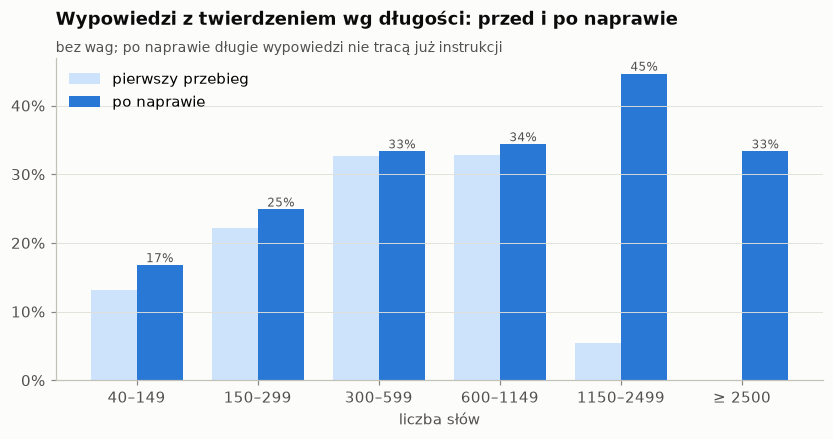

In [36]:
def summary(d):
    c = R.candidates(d)
    return pd.Series({"wypowiedzi": len(d), "z twierdzeniem [%]": 100 * d["y"].mean(), "twierdzenia": int(d["n_twierdzen"].sum()),
                      "kandydaci na wypowiedź": d["n_kandydatow"].mean(), "kandydaci „naukowe” [%]": 100 * c["rodzaj"].eq("naukowe").mean(),
                      "obcięte wejście": int(d["przepelnienie"].sum()), "przesunięcie kontekstu": int(d["przesuniecie"].sum())})

fix = pd.DataFrame({"pierwszy przebieg": summary(first[first["wypowiedz_id"].isin(rerun_ids)]),
                    "po naprawie": summary(df[df["wypowiedz_id"].isin(rerun_ids)])}).round(1)
display(fix)

fl = first.assign(przebieg="pierwszy przebieg", dlugosc=pd.cut(first["liczba_slow"], LEN_BINS, labels=LEN_LABELS, right=False))
both = pd.concat([fl, df.assign(przebieg="po naprawie")], ignore_index=True)
by_len2 = both.groupby(["dlugosc", "przebieg"], observed=True)["y"].mean().unstack()
fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(by_len2)); w = 0.38
for k, (col, color) in enumerate([("pierwszy przebieg", ACCENT_LIGHT), ("po naprawie", ACCENT)]):
    ax.bar(x + (k - 0.5) * w, by_len2[col], width=w, color=color, label=col)
for xi, v in enumerate(by_len2["po naprawie"]):
    ax.text(xi + w / 2, v, f"{v:.0%}", ha="center", va="bottom", fontsize=8, color=INK2)
ax.set_xticks(x, by_len2.index); ax.yaxis.set_major_formatter(PCT); ax.grid(axis="x", visible=False)
ax.set_xlabel("liczba słów"); ax.legend(loc="upper left")
ax.set_title("Wypowiedzi z twierdzeniem wg długości: przed i po naprawie")
subtitle(ax, "bez wag; po naprawie długie wypowiedzi nie tracą już instrukcji")
save(fig, "llm_a_14_naprawa"); plt.show()

W 119 powtórzonych wypowiedziach odsetek z twierdzeniem wzrósł z 22% do 46%, liczba twierdzeń z 60 do 160, a udział
kandydatów „naukowe” z 20% do 46%. Po naprawie odsetek rośnie z długością aż do najdłuższych wypowiedzi, zamiast się załamywać.

Wpływ na porównanie okresów (cała próba; „po naprawie” obejmuje też nowy krok 2, sekcja 9.4):

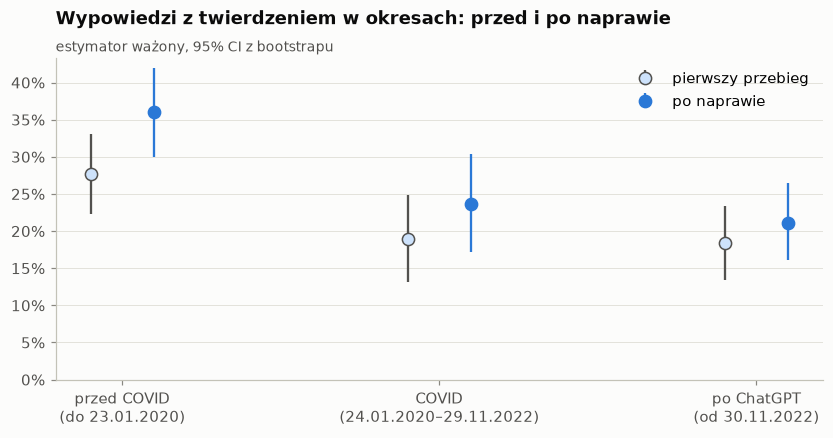

,pierwszy przebieg,po naprawie
przed COVID,27.7 [22.3; 33.0],36.1 [30.0; 41.9]
COVID,18.9 [13.1; 24.9],23.6 [17.2; 30.4]
po ChatGPT,18.4 [13.5; 23.4],21.1 [16.1; 26.5]


wariant,pierwszy przebieg,po naprawie
porównanie,,
COVID − przed COVID,-8.8 [-16.7; -0.9],-12.5 [-21.2; -3.5]
po ChatGPT − COVID,-0.5 [-8.4; +7.0],-2.5 [-11.0; +5.8]
po ChatGPT − przed COVID,-9.3 [-16.6; -1.9],-15.0 [-22.6; -7.2]


In [37]:
fig, ax = plt.subplots(figsize=(9, 3.8))
sens, diffs = {}, []
for k, (name, d, color) in enumerate([("pierwszy przebieg", first, ACCENT_LIGHT), ("po naprawie", df, ACCENT)]):
    b = R.bootstrap(d, "okres").loc[PERIODS]
    sens[name] = fmt_ci(b)
    x = np.arange(len(PERIODS)) + (k - 0.5) * 0.2
    ax.errorbar(x, b["p"], yerr=[b["p"] - b["lo"], b["hi"] - b["p"]], fmt="o", color=color if k else INK2, ecolor=color if k else INK2,
                mfc=color, elinewidth=1.5, capsize=0, ms=8, label=name)
    for a, bb in PAIRS:
        est, lo, hi = R.bootstrap_diff(d, "okres", a, bb)
        diffs.append({"wariant": name, "porównanie": f"{PERIOD_LABEL[bb]} − {PERIOD_LABEL[a]}",
                      "różnica [pp]": f"{100 * est:+.1f} [{100 * lo:+.1f}; {100 * hi:+.1f}]"})
ax.set_xticks(range(len(PERIODS)), [PERIOD_TICK[p] for p in PERIODS])
ax.yaxis.set_major_formatter(PCT); ax.set_ylim(0, None); ax.grid(axis="x", visible=False)
ax.legend(loc="upper right")
ax.set_title("Wypowiedzi z twierdzeniem w okresach: przed i po naprawie")
subtitle(ax, "estymator ważony, 95% CI z bootstrapu")
save(fig, "llm_a_15_okresy_przed_po"); plt.show()
display(pd.DataFrame(sens, index=[PERIOD_LABEL[p] for p in PERIODS]))
pd.DataFrame(diffs).pivot(index="porównanie", columns="wariant", values="różnica [pp]")[["pierwszy przebieg", "po naprawie"]]

Naprawa podniosła udział we wszystkich okresach, najbardziej przed COVID (27,7% → 36,1%), bo tam przepełnień było najwięcej.
Różnica COVID − przed COVID pogłębiła się z −8,8 do −12,5 pp, a po ChatGPT − przed COVID z −9,3 do −15,0 pp. Kierunek się
nie zmienił, ale wielkość efektu zależała od błędu instrumentu, który nierówno dotykał okresy. To dobry przykład, dlaczego błąd
trzeba mierzyć osobno w każdym okresie.

### 9.3 Limit kandydatów

W pierwszym przebiegu schemat pozwalał na 8 kandydatów. Wypowiedzi z pełnym limitem mogły mieć niewypisane twierdzenia.
Limit podnieśliśmy do 16 i powtórzyliśmy wypowiedzi, które go zapełniły. Krótsze wypowiedzi nie zbliżały się do limitu, więc ich
nie powtarzaliśmy. Alternatywą byłoby wypisywanie wyłącznie zdań „naukowych”, ale to zmienia prompt i wymaga powtórzenia całej
próby, a etykiety pozostałych rodzajów są potrzebne do analizy błędów.

In [38]:
was_full = set(first.loc[first["n_kandydatow"] >= 8, "wypowiedz_id"])
after = df[df["wypowiedz_id"].isin(was_full)]
pos = after["kandydaci"].apply(lambda cs: sum(1 for k, c in enumerate(cs) if k >= 8 and c.get("weryfikacja")))
print(f"pełny limit 8 w pierwszym przebiegu: {len(was_full)} wypowiedzi, w tym {first.loc[first['wypowiedz_id'].isin(was_full), 'przepelnienie'].sum()} z obciętym wejściem")
print(f"po naprawie: pełny limit 16: {int((df['n_kandydatow'] >= 16).sum())} wypowiedzi; "
      f"twierdzenia z kandydatów na pozycjach 9–16: {int(pos.sum())} (w {int((pos > 0).sum())} wypowiedziach)")
after["n_kandydatow"].value_counts().sort_index().rename("wypowiedzi").to_frame().T

pełny limit 8 w pierwszym przebiegu: 67 wypowiedzi, w tym 30 z obciętym wejściem
po naprawie: pełny limit 16: 4 wypowiedzi; twierdzenia z kandydatów na pozycjach 9–16: 15 (w 5 wypowiedziach)


n_kandydatow,0,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
wypowiedzi,11,1,1,3,4,3,6,13,2,7,3,3,4,2,1,3


W pierwszym przebiegu limit 8 zapełniło 67 wypowiedzi, z czego 30 miało obcięte wejście (zapełniały limit przypadkowymi
zdaniami). Po podniesieniu limitu do 16 zapełniają go tylko 4 wypowiedzi. Kandydaci na pozycjach 9–16 dali 15 twierdzeń
w 5 wypowiedziach: limit 8 gubił niewiele twierdzeń, ale nie zero.

### 9.4 Krok 2 z kontekstem

W pierwszym przebiegu krok 2 oceniał samą parafrazę. Teraz dostaje też fragment wypowiedzi (zdanie z cytatem i po jednym zdaniu
przed i po). Dla wypowiedzi, których nie powtarzaliśmy, mamy obie decyzje dla tych samych kandydatów:

In [39]:
nauk = cand[cand["rodzaj"] == "naukowe"].assign(weryfikacja=lambda x: x["weryfikacja"].astype(bool))
both2 = nauk[nauk["weryfikacja_v0"].notna()].assign(weryfikacja_v0=lambda x: x["weryfikacja_v0"].astype(bool))
lab = {True: "tak", False: "nie"}
display(pd.crosstab(both2["weryfikacja_v0"].map(lab).rename("bez kontekstu (v0)"),
                    both2["weryfikacja"].map(lab).rename("z kontekstem (v1)"), margins=True, margins_name="razem"))
flip = both2.assign(zmiana=both2["weryfikacja_v0"] != both2["weryfikacja"])
display(pd.concat({
    "okres": flip.groupby("okres").agg(kandydaci=("zmiana", "size"), v0_tak=("weryfikacja_v0", "mean"), v1_tak=("weryfikacja", "mean"),
                                       zmiana=("zmiana", "mean")).loc[PERIODS].rename(index=PERIOD_LABEL),
    "okno": flip.groupby("okno").agg(kandydaci=("zmiana", "size"), v0_tak=("weryfikacja_v0", "mean"), v1_tak=("weryfikacja", "mean"),
                                     zmiana=("zmiana", "mean")).loc[list(WINDOWS)],
    "źródło": flip.groupby("zrodlo").agg(kandydaci=("zmiana", "size"), v0_tak=("weryfikacja_v0", "mean"), v1_tak=("weryfikacja", "mean"),
                                         zmiana=("zmiana", "mean")),
}).round(2))
cols = ["rok", "temat", "twierdzenie", "cytat"]
display(Markdown("**v0: tak → v1: nie**"), both2.loc[both2["weryfikacja_v0"] & ~both2["weryfikacja"], cols].sample(8, random_state=0))
display(Markdown("**v0: nie → v1: tak**"), both2.loc[~both2["weryfikacja_v0"] & both2["weryfikacja"], cols].sample(8, random_state=0))

z kontekstem (v1),nie,tak,razem
bez kontekstu (v0),,,
nie,290,56,346
tak,30,225,255
razem,320,281,601


kandydaci  v0_tak  v1_tak  zmiana
okres  przed COVID        310    0.44    0.50    0.17
       COVID              102    0.44    0.47    0.13
       po ChatGPT         189    0.40    0.41    0.11
okno   A                   57    0.46    0.47    0.12
       B                   39    0.21    0.18    0.13
źródło komisje            302    0.50    0.52    0.15
       plenarne           299    0.35    0.41    0.14

**v0: tak → v1: nie**

,rok,temat,twierdzenie,cytat
48,2015,energia_jadrowa,Przesył nadwyżek energii wiatrowej przez Polskę powoduje problemy z przepływami fal wiatrakowych.,Mamy dużo kłopotów związanych z przepływami fal wiatrakowych.
2039,2026,inny_naukowy,"Wino, jako alkohol, może być wstępem do uzależnień.","My próbujemy promować przemysł winiarski, a wino jest alkoholem i często jest wstępem do uzależnień"
749,2018,smog,Smog w Polsce jest długotrwałym problemem środowiskowym.,"Problem smogu, który występuje w Polsce, nie jest problemem nowym."
658,2018,szczepienia,Nieszczepienie się może prowadzić do odrodzenia się chorób zakaźnych.,"W jakim stopniu należy przewidywać zagrożenie faktem, że osoby nie będą się szczepiły, jeśli będą miały taką możliwość, i co to będzie oznaczało, czy ewentualne odrodzenie się tych chorób zakaźnyc..."
1716,2024,smog,"Funkcjonowanie zakładu produkcyjnego w Turku powoduje uciążliwości zapachowe, które wpływają negatywnie na zdrowie i komfort mieszkańców.",Mieszkańcy miasta Turek już od kilku lat są zmuszeni do znoszenia uciążliwości zapachowych związanych z funkcjonowaniem jednego z zakładów produkcyjnych zlokalizowanych na jego terenie.
1547,2023,in_vitro,"Leczenie niepłodności polega na usunięciu przyczyn braku potomstwa, a nie na wspomaganym rozrodzie.","Leczenie niepłodności polega na zupełnie czym innym, na usunięciu przyczyn, które powodują brak potomstwa."
1972,2026,inny_naukowy,Szczepienie drobiu jest skutecznym sposobem zapobiegania chorobie Newcastle disease (ND).,Z jednej strony rolnicy chcą zaszczepić ptaki. Zwracają się do weterynarii o zaszczepienie tych swoich – powiedzmy – małych stad.
668,2018,smog,Termomodernizacja jednorodzinnych budynków mieszkalnych przyczynia się do poprawy jakości powietrza.,Jest to związane z przyspieszeniem procesu poprawy jakości powietrza.


**v0: nie → v1: tak**

,rok,temat,twierdzenie,cytat
1476,2023,inny_naukowy,"Długość życia Polaków zaczęła się skracać już przed pandemią, co wskazuje na pogarszającą się jakość życia.","To nie jest tak, Wysoka Izbo, że długość życia Polaków zaczęła się pogarszać, a więc skracać, w związku z pandemią, bowiem już w 2018 r., kiedy nie było pandemii, skróciła się długość życia Polakó..."
892,2019,5g_promieniowanie,5G jest krytykowane za potencjalny wpływ pola elektromagnetycznego na zdrowie.,"Technologia mobilna piątej generacji, znana także jako 5G, ma również wielu przeciwników. Najczęstsze argumenty dotyczą wpływu pola elektromagnetycznego związanego z 5G na zdrowie."
1234,2021,klimat,"Cel redukcji emisji o 55% w UE nie jest wystarczający do osiągnięcia celu 1,5ºC, zgodnie z opinią organizacji pozarządowych i naukowców.","Tak twierdzą organizacje pozarządowe, naukowcy, że 55% nie jest wystarczające w ramach Unii Europejskiej do osiągnięcia 1,5ºC."
542,2018,gmo,Weryfikacja wniosków dotyczących GMO odbywa się przez zespół ekspertów naukowych.,"Będzie to weryfikowane przez potężne grono naukowców, przyrodników, genetyków itd."
237,2016,energia_jadrowa,"Magazyny energii dla wiatraków nie są jeszcze opłacalne, z wyjątkiem specjalistycznych rozwiązań, takich jak koszt Benninga.","Na to cały świat czeka, ale ich w sensie opłacalnym nie ma, chyba że mówimy o rozwiązaniach, o koszcie Benninga, gdzie faktycznie są magazyny energii wystarczające na długi okres lotu, nawet przez..."
98,2015,gmo,"Konieczne są dalsze badania, aby zastąpić importowaną soję GMO polskimi roślinami wysokobiałkowymi.","Cieszę się, że ten program będzie realizowany przez kolejne 5 lat, bo potrzebne są badania, tak abyśmy byli przygotowani do zastąpienia soi genetycznie modyfikowanej polskimi roślinami wysokobiałk..."
764,2019,energia_jadrowa,Wyniki badań zostaną wykorzystane do analiz i symulacji na potrzeby raportów środowiskowych i lokalizacyjnych.,"Wyniki prowadzonych badań oraz studiów celowych w ramach wszystkich projektów zostaną wykorzystane do przeprowadzenia analiz i symulacji na potrzeby głównych produktów, jakimi są dwa wymienione ra..."
1366,2022,smog,Wprowadzenie norm jakości dla węgla i zakazów dla montowania kopciuchów przyczynia się do poprawy jakości powietrza.,Walka ze smogiem zaczęła przynosić powolne korzyści - wprowadzenie norm jakości dla węgla czy wprowadzenie zakazów dla montowania tzw. kopciuchów.


* Na tych samych 601 kandydatach krok 2 z kontekstem zmienił decyzję w 14% przypadków: 56 razy z „nie” na „tak” i 30 razy
  z „tak” na „nie”, więc potwierdza trochę więcej (47% zamiast 42%).
* Przy zmianach z „tak” na „nie” kontekst zwykle pomaga: parafraza dodała sens, którego w wypowiedzi nie było (szczepienie drobiu,
  odrodzenie chorób zakaźnych, o które mówca tylko pytał), albo zdanie okazuje się ogólnikiem („smog jest długotrwałym problemem”).
* Przy zmianach z „nie” na „tak” wynik jest mieszany: obok trafnych (cel redukcji emisji 55% a granica 1,5°C, przytoczone
  za naukowcami) są też błędne („weryfikacja wniosków odbywa się przez ekspertów”, „wyniki badań zostaną wykorzystane do analiz”).
* Zmiana decyzji jest częstsza przed COVID (17%) niż w okresie COVID (13%) i po ChatGPT (11%), a odsetek potwierdzeń wzrósł
  głównie przed COVID (44% → 50%). Sama wersja kroku 2 przesuwa więc porównanie okresów o kilka punktów.

Odsetek potwierdzeń w kroku 2 (z kontekstem) wg okresu, źródła i tematu nadanego w kroku 1, dla wszystkich kandydatów „naukowe”:

In [40]:
pd.concat({
    "okres": nauk.groupby("okres")["weryfikacja"].agg(["size", "mean"]).loc[PERIODS].rename(index=PERIOD_LABEL),
    "okno": nauk.groupby("okno")["weryfikacja"].agg(["size", "mean"]).loc[list(WINDOWS)],
    "źródło": nauk.groupby("zrodlo")["weryfikacja"].agg(["size", "mean"]),
    "temat": nauk.groupby("temat")["weryfikacja"].agg(["size", "mean"]).sort_values("size", ascending=False),
}).rename(columns={"size": "kandydaci naukowe", "mean": "potwierdzone"}).round(2)

kandydaci naukowe  potwierdzone
okres  przed COVID                      518          0.50
       COVID                            195          0.41
       po ChatGPT                       261          0.39
okno   A                                 76          0.39
       B                                 72          0.28
źródło komisje                          529          0.52
       plenarne                         445          0.37
temat  inny_naukowy                     297          0.53
       energia_jadrowa                  163          0.16
       klimat                           156          0.47
       szczepienia                       96          0.55
       smog                              77          0.48
       gmo                               66          0.44
       covid                             51          0.55
       brak                              29          0.31
       5g_promieniowanie                 21          0.71
       in_vitro                          18          0.72

Krok 2 potwierdza 45% kandydatów, ale nierówno: 37% na posiedzeniach plenarnych i 52% w komisjach, 16% dla `energia_jadrowa`
i ponad 70% dla 5G i in vitro; między okresami 50% / 41% / 39%, między oknami 39% (A) i 28% (B). Krok 2 może nadal odrzucać twierdzenia, które etap B powinien
ocenić, w tym potencjalnie sprzeczne z konsensusem. Tylko ręczna anotacja pokaże, czy dzieje się to częściej przy twierdzeniach
fałszywych niż prawdziwych.

### 9.5 Powtarzalność (test–retest)

Przy temperaturze 0 spodziewaliśmy się identycznych odpowiedzi przy powtórzeniu. Tak nie jest: obliczenia na GPU i ponowne
użycie pamięci podręcznej promptu dają drobne różnice numeryczne, które czasem zmieniają wybór kolejnego tokenu. Żeby zmierzyć,
jak bardzo wynik zależy od samego uruchomienia, 60 losowych wypowiedzi sklasyfikowaliśmy drugi raz (krok 1 i 2). Każdą
powtórzyliśmy z tymi samymi ustawieniami, z którymi powstał jej wynik główny (52 z kontekstem 8192, 8 z kontekstem 16 384),
więc porównanie mierzy wyłącznie zmienność między uruchomieniami.

In [41]:
pair = df.set_index("wypowiedz_id").loc[retest["wypowiedz_id"]]
rt = retest.set_index("wypowiedz_id")


def overlap(a, b, thr=0.6):
    return sum(any(max(quote_match(x["cytat"], y["cytat"]), quote_match(y["cytat"], x["cytat"])) >= thr for y in b) for x in a)


a_claims, b_claims = pair["twierdzenia"], rt.loc[pair.index, "twierdzenia"]
matched_a = sum(overlap(a, b) for a, b in zip(a_claims, b_claims))
matched_b = sum(overlap(b, a) for a, b in zip(a_claims, b_claims))
display(pd.crosstab(pair["y"].map({1: "tak", 0: "nie"}).rename("wynik główny: twierdzenie"),
                    rt.loc[pair.index, "y"].map({1: "tak", 0: "nie"}).rename("powtórzenie: twierdzenie"), margins=True, margins_name="razem"))
pd.Series({
    "wypowiedzi": len(pair),
    "zgodność: wypowiedź z twierdzeniem [%]": 100 * (pair["y"].values == rt.loc[pair.index, "y"].values).mean(),
    "kappa Cohena (wypowiedź z twierdzeniem)": R.cohen_kappa(pair["y"], rt.loc[pair.index, "y"]),
    "twierdzenia: wynik główny": int(a_claims.str.len().sum()),
    "twierdzenia: powtórzenie": int(b_claims.str.len().sum()),
    "twierdzenia główne z odpowiednikiem w powtórzeniu [%]": 100 * matched_a / max(a_claims.str.len().sum(), 1),
    "twierdzenia z powtórzenia z odpowiednikiem w głównym [%]": 100 * matched_b / max(b_claims.str.len().sum(), 1),
    "kandydaci: średnia różnica na wypowiedź": (pair["n_kandydatow"] - rt.loc[pair.index, "n_kandydatow"]).abs().mean(),
}).round(2).to_frame("wartość")

powtórzenie: twierdzenie,nie,tak,razem
wynik główny: twierdzenie,,,
nie,43,0,43
tak,1,16,17
razem,44,16,60


,wartość
wypowiedzi,60.00
zgodność: wypowiedź z twierdzeniem [%],98.33
kappa Cohena (wypowiedź z twierdzeniem),0.96
twierdzenia: wynik główny,24.00
twierdzenia: powtórzenie,22.00
twierdzenia główne z odpowiednikiem w powtórzeniu [%],91.67
twierdzenia z powtórzenia z odpowiednikiem w głównym [%],100.00
kandydaci: średnia różnica na wypowiedź,0.33


* Na poziomie wypowiedzi wynik jest stabilny: w 59 z 60 wypowiedzi powtórzenie dało tę samą decyzję (kappa 0,96). 92% twierdzeń
  z wyniku głównego ma odpowiednik w powtórzeniu, a każde twierdzenie z powtórzenia ma odpowiednik w wyniku głównym.
* Różnice dotyczą głównie szczegółów: brzmienia cytatu i parafrazy, pojedynczych kandydatów (średnio 0,3 kandydata na wypowiedź).
  Zmienność między uruchomieniami jest więc mała w porównaniu z błędami z 9.1–9.4.
* Drobna zmiana promptu potrafi zmienić wynik bardziej niż samo powtórzenie: jedna wypowiedź, która mieściła się w kontekście,
  po podniesieniu limitu kandydatów (w schemacie i w treści promptu) dała 0 kandydatów zamiast 8. Wrażliwość na prompt
  warto zbadać osobno.

### 9.6 Granica „naukowe / statystyka / prawo”

Kandydaci oznaczeni jako statystyka i prawo: część to dane urzędowe lub przepisy (poprawnie wykluczone), część mogłaby być
twierdzeniem naukowym.

In [42]:
cand.loc[cand["rodzaj"].isin(["statystyka", "prawo"]), ["rok", "rodzaj", "twierdzenie"]].sample(10, random_state=4).sort_values("rodzaj")

,rok,rodzaj,twierdzenie
1253,2021,prawo,"Nowy art. 38a wprowadza utajnienie prac komisji etycznych, naruszając konstytucję."
1258,2021,prawo,"Rzecznik praw pacjenta jest powoływany przez premiera spośród kandydatów wskazanych w postępowaniu konkursowym, ale komisję powołuje minister zdrowia."
1431,2022,statystyka,Rak szyjki macicy powoduje rocznie około 1600 zgonów młodych kobiet w Polsce.
532,2017,statystyka,"Badanie COSI wykazało, że prawie 40% dzieci otyłych rodziców jest otyłych."
1010,2020,statystyka,Liczba przeprowadzanych testów na koronawirusa w Polsce wynosi obecnie 6-7 tys. dziennie i wkrótce wzrośnie do 8-9 tys. dziennie.
1832,2025,statystyka,"Co ósmy Polak ogranicza wydatki na jedzenie, aby pokryć koszty ogrzewania i ciepłej wody."
590,2018,statystyka,"Polska będzie miała do dyspozycji 102,9 mln jednostek przyznanej emisji dzięki poprawce."
1337,2022,statystyka,"W Polsce leki OTC stanowią około 20-25% wszystkich zarejestrowanych produktów leczniczych, co jest mniej niż w innych krajach UE."
204,2016,statystyka,Około 12% konsumowanej energii pochodziło ze źródeł odnawialnych w 2015 roku.
1057,2020,statystyka,"W 2020 r. PKB w rozwiniętych krajach spadło o ok. 10%, a w niektórych krajach UE (Włochy, Hiszpania, Francja) o 13%."


Część „statystyk” to poprawne wykluczenia (liczba testów na koronawirusa, PKB, struktura rynku leków). Część to jednak dane
o zjawiskach z tłem naukowym lub epidemiologicznym: zgony z powodu raka szyjki macicy, wynik badania COSI o otyłości dzieci.
Granica między statystyką a twierdzeniem naukowym nie jest jeszcze ustalona, więc nie wiemy, czy te wykluczenia są błędem.

### 9.7 Wierność cytatów

Czy `cytat` podany przez LLM występuje w tekście wypowiedzi? Porównanie bez wielkości liter i interpunkcji; 1 = cytat dosłowny,
mniej = najdłuższy wspólny fragment jako część cytatu. Niska zgodność oznacza parafrazę zamiast cytatu albo zmyślenie.
Dosłowny cytat jest też potrzebny krokowi 2, żeby znaleźć fragment wypowiedzi.

In [43]:
text = df.set_index("wypowiedz_id")["tekst"]
cand["zgodnosc_cytatu"] = [quote_match(q, text[i]) for q, i in zip(cand["cytat"], cand["wypowiedz_id"])]
cand["cytat_doslowny"] = cand["zgodnosc_cytatu"].eq(1)
agg = dict(dosłowny=lambda s: s.eq(1).mean(), ponad_80=lambda s: s.ge(0.8).mean(), ponizej_50=lambda s: s.lt(0.5).mean())
display(pd.concat({"wszyscy kandydaci": cand["zgodnosc_cytatu"].agg(**agg).to_frame().T,
                   "wg rodzaju": cand.groupby("rodzaj")["zgodnosc_cytatu"].agg(**agg)}).round(3))
print(f"twierdzenia z cytatem dosłownym: {cand.loc[cand['weryfikacja'].eq(True), 'cytat_doslowny'].mean():.1%}")
cand.loc[cand["zgodnosc_cytatu"] < 0.5, ["wypowiedz_id", "rodzaj", "cytat", "zgodnosc_cytatu"]].head(8).round(2)

dosłowny  ponad_80  ponizej_50
wszyscy kandydaci zgodnosc_cytatu     0.936     0.963       0.012
wg rodzaju        budzet              0.912     0.930       0.018
                  inne                0.969     0.988       0.006
                  naukowe             0.928     0.956       0.016
                  opinia              0.974     0.983       0.000
                  polityka            0.933     0.980       0.003
                  prawo               0.897     0.923       0.038
                  statystyka          0.931     0.950       0.011

twierdzenia z cytatem dosłownym: 92.3%


,wypowiedz_id,rodzaj,cytat,zgodnosc_cytatu
20,8_OSZ_2_15,polityka,"Francja wprowadza restrykcje, bo bazuje na energii jądrowej.",0.34
31,8_ZDR_2_41,naukowe,"Spalanie węgla zwiększa stężenie CO2 w atmosferze, co ociepla klimat.",0.09
47,8_ESK_2_57,statystyka,Efektywność energetyczna w Opolu wynosi 47%.,0.29
63,8_RRW_5_36,naukowe,"Gospodarstwo musi mieć opracowany program monitorowania i zwalczania gryzoni, dokonywać okresowo zabiegów dezynsekcji, rejestrować środki transportu i osoby mające kontakt ze świniami.",0.36
102,8_5_2015-12-17_141,naukowe,Promowanie korzystania z odnawialnych źródeł energii w gospodarstwach rolnych.,0.40
105,8_5_2015-12-17_141,prawo,Zakończenie hodowli zwierząt na futro w Polsce.,0.43
466,8_OSZ_88_1,statystyka,W Polsce mamy zarejestrowanych około 5 tys. średnich źródeł spalania.,0.37
698,8_ZDR_151_61,naukowe,"wszystkie wymagania jakościowe są określone w farmakopei, która zawiera szczegółowe monografie dotyczące procesu wytwarzania, kontroli i metod badań szczepionek.",0.36


* 93,6% cytatów występuje w tekście dosłownie, 96% w ponad 80%; dla twierdzeń 92%. Rozbieżności to głównie streszczenia
  przepisów i pytań oraz parafrazy zamiast cytatu.
* Jeden przypadek jest poważniejszy: w długiej wypowiedzi `8_ZDR_2_41` model podał jako „cytat” zdanie z przykładu w prompcie
  („Spalanie węgla zwiększa stężenie CO2 w atmosferze, co ociepla klimat.”), którego w wypowiedzi nie ma, a krok 2 potwierdził je
  jako twierdzenie. To jedyny taki przypadek na 2107 kandydatów, ale pokazuje, że przykłady z promptu mogą przeciekać do odpowiedzi.
  Prosta ochrona: odrzucać kandydatów, których cytatu nie da się odnaleźć w tekście.

### 9.8 Czy błędy i skład próby są takie same w okresach i oknach?

Wskaźniki, które mogą różnić się między okresami i przez to przesuwać porównania w czasie (okna A i B, okresy H1). Pierwszy panel dotyczy pierwszego przebiegu
(po naprawie przepełnienia nie ma), pozostałe stanu po naprawie.

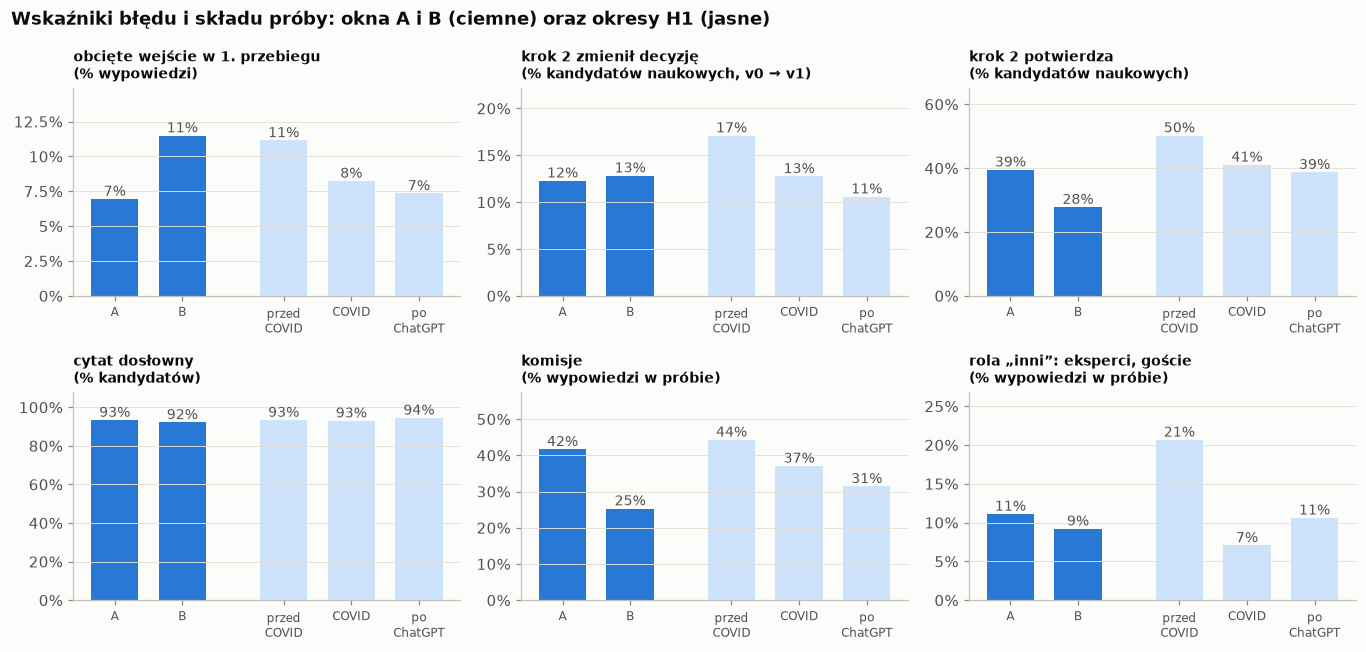

,okno A,okno B,przed COVID,COVID,po ChatGPT
obcięte wejście w 1. przebiegu\n(% wypowiedzi),6.9,11.5,11.1,8.2,7.3
"krok 2 zmienił decyzję\n(% kandydatów naukowych, v0 → v1)",12.3,12.8,17.1,12.7,10.6
krok 2 potwierdza\n(% kandydatów naukowych),39.5,27.8,50.2,41.0,38.7
cytat dosłowny\n(% kandydatów),93.3,92.1,93.3,93.0,94.4
komisje\n(% wypowiedzi w próbie),41.7,25.3,44.3,37.1,31.4
"rola „inni”: eksperci, goście\n(% wypowiedzi w próbie)",11.1,9.2,20.7,7.1,10.6


In [44]:
def indicators(by, order):
    return pd.DataFrame({
        "obcięte wejście w 1. przebiegu\n(% wypowiedzi)": first.groupby(by)["przepelnienie"].mean(),
        "krok 2 zmienił decyzję\n(% kandydatów naukowych, v0 → v1)": flip.groupby(by)["zmiana"].mean(),
        "krok 2 potwierdza\n(% kandydatów naukowych)": nauk.groupby(by)["weryfikacja"].mean(),
        "cytat dosłowny\n(% kandydatów)": cand.groupby(by)["cytat_doslowny"].mean(),
        "komisje\n(% wypowiedzi w próbie)": df["zrodlo"].eq("komisje").groupby(df[by]).mean(),
        "rola „inni”: eksperci, goście\n(% wypowiedzi w próbie)": df["rola"].eq("inni").groupby(df[by]).mean(),
    }).loc[order]


ind = pd.concat([indicators("okno", list(WINDOWS)).rename(index=lambda k: f"okno {k}"),
                 indicators("okres", PERIODS).rename(index=PERIOD_LABEL)])
xs = [0, 1, 2.5, 3.5, 4.5]
fig, axes = plt.subplots(2, 3, figsize=(12.5, 6))
for ax, col in zip(axes.flat, ind.columns):
    v = ind[col]
    ax.bar(xs, v, color=[ACCENT, ACCENT] + [ACCENT_LIGHT] * 3, width=0.7)
    for x, val in zip(xs, v):
        ax.text(x, val, f"{val:.0%}", ha="center", va="bottom", fontsize=9, color=INK2)
    ax.set_xticks(xs, ["A", "B", "przed\nCOVID", "COVID", "po\nChatGPT"], fontsize=8)
    ax.set_ylim(0, min(max(v.max() * 1.3, 0.05), 1.08)); ax.yaxis.set_major_formatter(PCT)
    ax.set_title(col, fontsize=9, loc="left", pad=6, fontweight="bold")
    ax.grid(axis="x", visible=False)
fig.suptitle("Wskaźniki błędu i składu próby: okna A i B (ciemne) oraz okresy H1 (jasne)", x=0.01, ha="left", fontsize=12,
             fontweight="bold", color=INK)
fig.tight_layout()
save(fig, "llm_a_16_bledy_okresy"); plt.show()
ind.mul(100).round(1).T

* Wskaźniki samego instrumentu różnią się między okresami H1: obcięte wejście w pierwszym przebiegu 11% / 8% / 7%, zmiana decyzji
  kroku 2 po dodaniu kontekstu 17% / 13% / 11%, odsetek potwierdzeń w kroku 2 50% / 41% / 39%.
* Między oknami też: obcięte wejście w pierwszym przebiegu dotyczyło 7% wypowiedzi z A i 11% z B, a krok 2 potwierdza 39%
  kandydatów „naukowe” w A i 28% w B (76 i 72 kandydatów). Niższy odsetek w B może znaczyć, że krok 1 częściej nazywa tam naukowymi zdania, które
  nimi nie są, albo że krok 2 częściej odrzuca prawdziwe twierdzenia. Bez ręcznej anotacji tego nie rozstrzygniemy.
* Do tego dochodzą różnice składu: komisje 44% → 37% → 31% w okresach H1 i 42% (A) wobec 25% (B) w oknach, rola „inni”
  21% → 7% → 11%.
* Wnioski: błąd instrumentu trzeba mierzyć osobno w każdym porównywanym okresie lub oknie, a estymacja musi kontrolować źródło
  i rolę mówcy albo zawęzić populację.

### 9.9 Podsumowanie źródeł błędu

| # | problem | dowód (ten notatnik) | kierunek | różny w okresach i oknach? | stan |
|---|---|---|---|---|---|
| 1 | **obcięte wejście**: prompt > 8192 tokenów, instrukcje tracone | 66 wyp. (9%) w 1. przebiegu; twierdzenie w 3% wobec 30% | zaniżało, zwłaszcza długie wystąpienia | **tak**: 11% / 8% / 7%; okna 7% / 11% | naprawione: kontekst 16 384, kontrola tokenów, ponowny przebieg |
| 2 | przesunięcie kontekstu pod koniec odpowiedzi | 26 wyp. w 1. przebiegu | mały | 4% / 4% / 3% | naprawione |
| 3 | limit 8 kandydatów | 67 wyp. z pełnym limitem; 15 twierdzeń z pozycji 9–16 | lekko zaniżał | – | naprawione: limit 16 (pełny w 4 wyp.) |
| 4 | krok 2 oceniał parafrazę bez kontekstu | 14% decyzji zmienionych po dodaniu kontekstu | oba kierunki | **tak**: 17% / 13% / 11% zmian; okna 12% / 13% | zmienione: krok 2 z kontekstem; jakość nieznana |
| 5 | krok 2 odrzuca część kandydatów | 55% kandydatów „naukowe” odrzuconych; 37% plenarne vs 52% komisje | oba kierunki; może zaniżać twierdzenia sprzeczne z konsensusem | **tak**: potwierdzenia 50% / 41% / 39%; okna 39% / 28% | otwarte: ręczna anotacja |
| 6 | granica naukowe / statystyka / prawo | 9.6 | oba kierunki | nieznany | otwarte |
| 7 | etykieta tematu: `energia_jadrowa` jako „energetyka”, `klimat` dla ochrony przyrody | 31% twierdzeń `energia_jadrowa` dotyczy atomu; lista twierdzeń w oknach (5.5) | analiza per temat | tak (CCS w 2023 r.) | otwarte |
| 8 | zmienność między uruchomieniami | zgodność 98%, kappa 0,96 (60 wyp.) | szum | za mała próba, by sprawdzić | zmierzone: mała |
| 9 | przeciekanie przykładów z promptu | 1 cytat skopiowany z przykładu (na 2107 kandydatów) | zawyża | nieznany | otwarte: odrzucać cytaty nieobecne w tekście |
| 10 | populacja = filtr regex | 8% wzmianek o COVID zawiera twierdzenie o COVID; czułość filtra nieznana | mianownik zależny od tematów dnia | **tak**: COVID zwiększa liczbę trafień; w B więcej wzmianek o klimacie i in vitro | otwarte |
| 11 | skład próby: komisje i eksperci | komisje 44% / 37% / 31%, „inni” 21% / 7% / 11%; okna: komisje 42% / 25% (populacja 34% / 35%) | przesuwa różnice okresów | **tak** | otwarte: warstwy lub zmienne w modelu |
| 12 | krok 1 z dwóch przebiegów | 601 wyp. z kontekstem 8192, 119 z 16 384 | mały (zmiana dotyczy wypowiedzi, które się mieściły) | nie | zaakceptowane (9.5) |
| 13 | mała próba | 60 / rok, przedział dla roku ok. ±12 pp; w oknach 72 i 87 wyp. | szum | nie | otwarte |
| 14 | brak danych odniesienia; jeden model i prompt | – | nieznany | nieznany | ręczna anotacja (rozważana) |
| 15 | wypowiedzi skupione w mówcach i dniach | jedna wypowiedź daje do kilkunastu twierdzeń (6.3); in vitro w B: 51% wzmianek z dwóch dni (5.4) | zaniża błędy standardowe | tak | otwarte: klastrowanie po mówcy lub dniu |

Dla porównań w czasie najważniejsze są błędy różnicowe (1, 4, 5, 10, 11): mogą same wytworzyć różnicę między okresami albo oknami,
albo ją ukryć.

## 10. Dalszy plan

### 10.1 Co naprawiliśmy i co zostaje

Naprawione po pierwszym przebiegu (sekcje 9.1–9.4):
* przepełnienie kontekstu: kontekst 16 384 tokeny, automatyczna kontrola liczby tokenów, ponowny przebieg 119 wypowiedzi;
* limit kandydatów podniesiony z 8 do 16;
* krok 2 ocenia twierdzenie razem z fragmentem wypowiedzi.

Zostaje na później, bo wymagałoby powtórzenia całej próby:
* krótszy prompt bazowy (dziś ok. 4,7 tys. tokenów);
* doprecyzowanie granicy „naukowe / statystyka / prawo” i etykiet tematów w prompcie (9.6, 4.4, 5.5);
* zmienność między uruchomieniami (9.5): można ją zmniejszyć, uruchamiając model kilka razy i biorąc wynik większości
  (kosztem czasu), albo uwzględniać ją jako dodatkowe źródło niepewności;
* populacja ograniczona do filtra regex: twierdzenia w wypowiedziach bez trafień słowników są poza pomiarem.

### 10.2 Model

Obecnie używamy Bielika 11B lokalnie: to polski model otwarty, który mieści się na naszej karcie graficznej, działa bez kosztów
i limitów, a wersję modelu mamy pod kontrolą. Wady: ok. 27 s na wypowiedź, kwantyzacja Q4, niepełna powtarzalność (9.5).
Rozważane kierunki (bez rozstrzygania na tym etapie):

* **Bielik na większej losowej próbie.** Do oszacowania odsetków w oknach nie trzeba klasyfikować całego korpusu; wystarczy
  losowa próba z wagami, jak w tym notatniku, tylko większa i losowana osobno w każdym oknie (10.5).
* **HerBERT jako szybki filtr** (opcja, nie jesteśmy pewni jej sensu). Dostrajalibyśmy go na wynikach Bielika, więc jakości
  nie poprawi: nauczy się błędów Bielika i doda własne, a jego błąd i tak trzeba by zmierzyć na ręcznie oznaczonych danych.
  Daje tylko szybkość: przenosi ocenę Bielika na cały korpus w krótkim czasie. Ma to sens wtedy, gdy potrzebny jest wynik dla
  każdej wypowiedzi (np. szeregi miesięczne albo analiza na poziomie posła), a nie tylko odsetki w okresach.
* **Większy model otwarty** wymagałby więcej pamięci GPU niż mamy. Warto do niego wrócić, jeśli ręczna anotacja pokaże, że Bielik
  myli się za często.

Który wariant jest lepszy, rozstrzygnęłaby dopiero ręczna anotacja (10.4).

### 10.3 Jak mierzymy zjawisko

```
wypowiedzi merytoryczne (populacja)
   │  losowa próba warstwowa (okno lub rok; ewentualnie też źródło) z wagami
   │  [opcjonalnie filtr wstępny: słowniki albo HerBERT]
   ▼
etap A (LLM): twierdzenia naukowe (cytat, parafraza, temat, atrybucja)
   ▼
etap B: werdykt względem źródeł opublikowanych przed dniem wypowiedzi (dokumenty instytucji, wyszukiwanie źródeł;
        bez polegania na wiedzy LLM-a)
   ▼
prawda / fałsz / nierozstrzygalne
   ▼
agregacja: twierdzenie → wypowiedź → okno; test z uwzględnieniem błędu klasyfikatora
```

Co z tej eksploracji wynika dla pomiaru:
* **Jednostka.** Twierdzenie, bo ponad połowa wypowiedzi z twierdzeniem ma ich kilka (sekcja 3); wynik dla wypowiedzi
  to agregat.
* **Mianownik.** Udział wypowiedzi z twierdzeniem naukowym sam zmienia się w czasie (sekcja 5), a w suplemencie karty
  mianownikiem są wypowiedzi tematyczne. Tylko część z nich zawiera twierdzenie naukowe (4.1, 5.5), więc odsetek wypowiedzi
  sprzecznych zależy też od tego, jak często w ogóle pada twierdzenie naukowe, a ten odsetek zależy m.in. od długości
  wypowiedzi (krótsze w B, 5.4). Odsetek twierdzeń fałszywych wśród twierdzeń naukowych i odsetek wypowiedzi z twierdzeniem
  fałszywym wśród wypowiedzi tematycznych mogą dać różne wnioski; warto liczyć oba.
* **Próba w oknach.** Próba z tego notatnika ma w oknach tylko 72 i 87 wypowiedzi. Porównanie okien wymaga próby losowanej
  osobno w każdym oknie i źródle albo przebiegu na całej populacji filtra w oknach (10.5).
* **Skład.** Udział komisji i ekspertów zmienia się między okresami (sekcje 1, 5, 6), a w oknach zmienia się też to, kto rządzi
  (5.6); trzeba to kontrolować (warstwy w losowaniu albo zmienne w modelu) albo zawęzić populację.
* **Błąd instrumentu** może różnić się między okresami i oknami (sekcja 9), więc trzeba go mierzyć osobno w każdym z nich.
* **Istotność.** Zgodnie z sugestią prowadzącego wyznaczymy ją z uwzględnieniem niepewności klasyfikatora, np. korektą
  Rogana–Gladena z bootstrapem albo metodą prediction-powered inference (Angelopoulos i in., 2023). Obie wymagają ręcznie
  oznaczonej próby.

### 10.4 Ręczna anotacja (rozważana)

Rozważamy ręczne oznaczenie części wypowiedzi, żeby oszacować błąd instrumentu. Pozwoliłoby to:
* zmierzyć precyzję i czułość kroku 1, kroku 2 i całości, osobno w oknach;
* sprawdzić, czy krok 2 nie odrzuca częściej twierdzeń sprzecznych z konsensusem (9.4);
* oszacować, ile twierdzeń gubi filtr regex (anotacja wypowiedzi spoza filtra);
* ocenić atrybucję, wierność parafraz i etykiety tematów;
* porównać zmienność modelu (9.5) ze zgodnością dwóch anotatorów.

Kilkadziesiąt wypowiedzi pokazałoby rząd wielkości błędu; do korekty istotności potrzeba więcej, rzędu kilkuset (scenariusze
w 10.5). Anotację trzeba by zrobić przed obejrzeniem wyników modelu, żeby ich nie sugerować.

### 10.5 Wykonalność

In [45]:
sec_first = first.loc[~first["wypowiedz_id"].isin(rerun_ids), "sekundy"].mean()
sec_long = df.loc[df["wypowiedz_id"].isin(rerun_ids), "sekundy"].mean()
share_long = len(rerun_ids) / len(df)
sec = (1 - share_long) * sec_first + share_long * sec_long + df["sekundy_weryfikacji"].mean()
n_wpl = int((wf["zrodlo"] == "plenarne").sum())
display(pd.Series({
    "szacowany czas Bielika po naprawie [s / wypowiedź]": round(sec, 1),
    f"okna A i B, filtr regex, plenarne ({n_wpl:,} wyp.) [h]": round(n_wpl * sec / 3600),
    f"okna A i B, filtr regex, plenarne + komisje ({len(wf):,} wyp.) [h]": round(len(wf) * sec / 3600),
    f"cały filtr regex ({len(filt):,} wyp.) [h]": round(len(filt) * sec / 3600),
    f"wszystkie merytoryczne ({len(mer):,} wyp.) [h]": round(len(mer) * sec / 3600),
}).to_frame("wartość"))
est_claims = pd.concat([totals(dw, "okno", "n_twierdzen").loc[list(WINDOWS)].rename(index=lambda k: f"okno {k}"),
                        totals(df, "okres", "n_twierdzen").loc[PERIODS].rename(index=PERIOD_LABEL)])
est_claims.round().astype(int).to_frame("szac. twierdzenia naukowe w populacji filtra")

,wartość
szacowany czas Bielika po naprawie [s / wypowiedź],26.7
"okna A i B, filtr regex, plenarne (3,676 wyp.) [h]",27.0
"okna A i B, filtr regex, plenarne + komisje (5,616 wyp.) [h]",42.0
"cały filtr regex (19,417 wyp.) [h]",144.0
"wszystkie merytoryczne (187,665 wyp.) [h]",1392.0


,szac. twierdzenia naukowe w populacji filtra
okno A,1078
okno B,743
przed COVID,3305
COVID,4103
po ChatGPT,2716


In [46]:
z_a, z_b = NormalDist().inv_cdf(0.975), NormalDist().inv_cdf(0.8)


def n_per_group(p0, d):
    p1 = p0 + d
    pb = (p0 + p1) / 2
    return int(np.ceil((z_a * np.sqrt(2 * pb * (1 - pb)) + z_b * np.sqrt(p0 * (1 - p0) + p1 * (1 - p1))) ** 2 / d ** 2))


power = pd.DataFrame({f"wzrost o {d * 100:.0f} pp": [n_per_group(p0, d) for p0 in (0.05, 0.10, 0.20)] for d in (0.03, 0.05, 0.10)},
                     index=pd.Index(["5%", "10%", "20%"], name="odsetek fałszywych w okresie odniesienia"))
display(Markdown("**Liczba twierdzeń ocenionych w etapie B potrzebna w każdym okresie lub oknie** (test dwóch proporcji, α = 0,05, moc 80%, "
                 "bez błędu klasyfikatora i bez skupienia w mówcach)"))
power

**Liczba twierdzeń ocenionych w etapie B potrzebna w każdym okresie lub oknie** (test dwóch proporcji, α = 0,05, moc 80%, bez błędu klasyfikatora i bez skupienia w mówcach)

,wzrost o 3 pp,wzrost o 5 pp,wzrost o 10 pp
odsetek fałszywych w okresie odniesienia,,,
5%,1059,435,141
10%,1774,686,199
20%,2943,1094,294


In [47]:
p_w = R.weighted_share(dw, "okno")
k_list = [30, 50, 100, 200]
gold = pd.DataFrame({f"okno {k}: wypowiedzi do oznaczenia": [int(np.ceil(kk / p_w[k])) for kk in k_list] for k in WINDOWS},
                    index=pd.Index(k_list, name="wypowiedzi z twierdzeniem w oznaczonej próbie"))
gold["± połowa 95% CI dla czułości 0,8 [pp]"] = [round(100 * 1.96 * np.sqrt(0.8 * 0.2 / kk), 1) for kk in k_list]
display(Markdown(f"**Ile wypowiedzi z filtra trzeba oznaczyć ręcznie w każdym oknie** (scenariusz: odsetek wypowiedzi z twierdzeniem "
                 f"jak w próbie LLM, A {p_w['A']:.0%}, B {p_w['B']:.0%}; losowanie proste w oknie)"))
gold

**Ile wypowiedzi z filtra trzeba oznaczyć ręcznie w każdym oknie** (scenariusz: odsetek wypowiedzi z twierdzeniem jak w próbie LLM, A 24%, B 17%; losowanie proste w oknie)

,okno A: wypowiedzi do oznaczenia,okno B: wypowiedzi do oznaczenia,"± połowa 95% CI dla czułości 0,8 [pp]"
wypowiedzi z twierdzeniem w oznaczonej próbie,,,
30,124,179,14.3
50,206,299,11.1
100,411,597,7.8
200,822,1193,5.5


Przy udziale wypowiedzi z twierdzeniem jak w próbie (24% w A, 17% w B) zebranie 100 wypowiedzi z twierdzeniem wymaga ręcznego
przejrzenia ok. 410 wypowiedzi z A i 600 z B. 30 wypowiedzi z twierdzeniem (próg z suplementu karty) daje przedział dla czułości
ok. ±14 pp, 100 ok. ±8 pp. To scenariusz dla etapu A (czy wypowiedź zawiera twierdzenie naukowe). Wypowiedzi z twierdzeniem
sprzecznym z konsensusem będzie mniej, ale ich odsetka jeszcze nie znamy. Losowanie z nadreprezentacją wypowiedzi wskazanych
przez model (jak w suplemencie) zmniejszy te liczby.

* Bielik po naprawie potrzebuje średnio ok. 27 s na wypowiedź. Cała populacja filtra w oknach A i B to ok. 42 h pracy GPU
  (ok. 27 h dla samych posiedzeń plenarnych), cały filtr 2015–2026 ok. 144 h, wszystkie wypowiedzi merytoryczne ok. 1400 h.
  Pełny przebieg na oknach jest więc wykonalny w kilka dni pracy jednej karty; pełny korpus wymaga szybkiego filtra albo większej
  mocy obliczeniowej.
* W populacji filtra jest szacunkowo ok. 1,1 tys. twierdzeń naukowych w oknie A i 0,7 tys. w B (w okresach H1 3,3 / 4,1 / 2,7 tys.).
* Tabela mocy (scenariusze, nie założenia): jeśli w okresie odniesienia 10% twierdzeń jest fałszywych, wykrycie wzrostu o 5 pp
  wymaga ok. 690 ocenionych twierdzeń w każdym okresie. W oknach to prawie wszystkie twierdzenia z populacji filtra, a dla jednego
  tematu (np. klimatu) dużo mniej niż potrzeba. Przy mniejszym efekcie (3 pp) potrzeba 1–3 tys. twierdzeń na okres. Błąd
  klasyfikatora i skupienie twierdzeń w mówcach zwiększą te liczby.

## 11. Podsumowanie

**Co wiemy po eksploracji próby LLM**

1. **Okna A i B, cały korpus.** Wypowiedzi ze wzmianką o dowolnym temacie naukowym to ok. 9–11% wypowiedzi plenarnych w obu
   oknach (1 503 i 1 756), wypowiedzi tematycznych (≥ 3 trafienia) 282 i 447. Najbardziej rośnie klimat (244 → 617 wzmianek
   plenarnych, 32 → 145 wypowiedzi tematycznych), COVID słabnie, in vitro rośnie głównie przez jedną debatę.
2. **Okna A i B, próba LLM.** Twierdzenie naukowe ma 24% wypowiedzi z filtra w A i 17% w B (różnica −7,6 pp [−20,9; +6,0]);
   w populacji filtra to szacunkowo ok. 630 i 510 wypowiedzi z twierdzeniem. Próba ma w oknach tylko 72 i 87 wypowiedzi, więc okien
   nie rozróżnia. Jeden temat w jednym oknie to od kilku do ok. 110 wypowiedzi z twierdzeniem (przeliczenie w 5.5).
3. **Kto mówi.** Konfederacja najczęściej porusza tematy ze słowników i odpowiada za większość wypowiedzi z markerem `sceptycyzm`
   (23 z 38 w A, 49 z 70 w B). PiS w opozycji wspomina klimat znacznie częściej (53 → 193 wzmianek plenarnych), choć udział
   wypowiedzi z tematem naukowym się nie zmienia. Marker łapie głównie retorykę wobec polityki klimatycznej, a nie twierdzenia
   o faktach.
4. **ChatGPT.** Udział wypowiedzi z twierdzeniem spada po 30.11.2022 (27,7% → 21,1%), ale tylko w komisjach; na posiedzeniach
   plenarnych się nie zmienia. Środek okna A wypada dokładnie 30.11.2022, więc placebo z suplementu karty pokrywa się z premierą
   ChatGPT.
5. **COVID (H1).** Udział spada po 2020 r. (36% → 24% → 21%), ale liczba twierdzeń w populacji jest najwyższa w okresie COVID,
   a część spadku wyjaśniają skład próby (mniej komisji i ekspertów po 2020 r.) i różnice w działaniu instrumentu.
6. **Jednostka i tematy.** Ponad połowa wypowiedzi z twierdzeniem ma ich więcej niż jedno. Wzmianka to nie twierdzenie: tylko 8%
   wypowiedzi wspominających COVID zawiera twierdzenie o COVID, a ponad jedna trzecia twierdzeń dotyczy tematów spoza słowników.
7. **Instrument.** Pierwszy przebieg miał cichy błąd przepełnienia kontekstu w 9% wypowiedzi. Po naprawie wynik jest stabilny
   między uruchomieniami (kappa 0,96), ale zależy od wersji kroku 2, a wskaźniki błędu różnią się między oknami (krok 2 potwierdza
   39% kandydatów w A i 28% w B).
8. To pomiar etapu A. O sprzeczności wypowiedzi z konsensusem ten notatnik nic nie mówi.

**Ograniczenia**

* Brak ręcznie oznaczonych danych odniesienia: precyzja i czułość instrumentu są nieznane i mogą się różnić między okresami
  i oknami.
* Populacja ograniczona do wypowiedzi z trafieniem słowników; twierdzenia poza filtrem są poza pomiarem.
* Próba była losowana po latach, a nie po oknach: w oknach jest 72 i 87 wypowiedzi, a udział komisji w próbie z okna B (25%)
  jest niższy niż w populacji (35%).
* Krok 1 pochodzi z dwóch przebiegów: 601 wypowiedzi z pierwszego (kontekst 8192, limit 8), 119 z ponownego (16 384, limit 16).
  Dla wypowiedzi, które mieściły się w kontekście i nie zapełniały limitu, zmiana ustawień nie powinna systematycznie zmieniać
  wyniku, a zmienność między uruchomieniami jest mała (9.5).
* 60 wypowiedzi na rok daje szerokie przedziały dla lat, okien, tematów i bloków.
* Jeden model i jeden prompt kroku 1, strojony na 20 wypowiedziach (część przykładów w prompcie pochodzi z nich).
* Parafrazę twierdzenia generuje LLM i może ona przesunąć sens wypowiedzi; cytat źródłowy jest zachowany do kontroli.
* Rok 2026 obejmuje dane do dnia pobrania korpusu; okresy H1 mają różną długość.